# Analyze RNNs

In [1]:
from utilities.utils import *
from utilities.RNN import *
import numpy as np
import scipy
import random
import torch
from sklearn.manifold import TSNE
import pickle
import pandas as pd
from statsmodels.stats.anova import AnovaRM
import matplotlib
from matplotlib import pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from dPCA_master.python.dPCA import dPCA

### Load experimental data and variables

In [2]:
# we'll want the experimental data for comparison ... load it now

try:
    
    # if train-rnns-manuscript was run, this file will exist
    
    with open('data/model/experimental_input.pkl', 'rb') as file:
        experimental_input = pickle.load(file)
        file.close()

    all_data = experimental_input['all_data'] # a dictionary with a key for each included session
    included_sessions = list(all_data.keys())
    n_sessions = len(included_sessions)
    params = experimental_input['parameters']
    bin_size = params['bin_size']
    padding = params['padding']
    smooth_type = params['smooth_type']
    smooth_width = params['smooth_width']
    
except:
    
    # otherwise, create it from scratch
    
    ## load raw data
    data = scipy.io.loadmat('data/experimental/data_all.mat')

    ## parameters for data prep
    bin_size = 0.050 # [s]
    padding = 1 # [s]
    min_n_neurons = 3
    smooth_type = 'gaussian'
    smooth_width = 11

    # filter sessions
    n_sessions_all = data['data_all'].shape[1]
    included_sessions = [i for i in range(n_sessions_all) if len(data['data_all'][0, i][-1]) >= min_n_neurons]
    n_sessions = len(included_sessions)

    # time warping
    all_data = {}
    for i_session in included_sessions:
        print('Preparing session', i_session + 1, '...')
        all_data[i_session] = get_warped_data(data, i_session, bin_size, padding, mean_correct_only=False)
    print('Done.')

    # smoothing
    for session in included_sessions:
        X, y_conc, y_choice, y_outcome, t = all_data[session]
        X_smooth = X.copy()
        for i in range(X_smooth.shape[0]):
            for j in range(X_smooth.shape[1]):
                X_smooth[i, j, :] = smooth(X_smooth[i, j, :], smooth_type, smooth_width)
        all_data[session] = (X_smooth, y_conc, y_choice, y_outcome, t)

    ## calculate additional variables
    unique_stims = np.unique(all_data[0][1]) # same stimuli for all sessions
    n_stims = len(unique_stims)
    t = all_data[0][4] # same time for all sessions
    n_bins = len(t)

    ## save model inputs
    with open('data/model/experimental_input.pkl', 'wb') as file:
        pickle.dump({
            'parameters': {
                'bin_size': bin_size,
                'padding': padding,
                'smooth_type': smooth_type,
                'smooth_width': smooth_width
            },
            'all_data': all_data
        }, file)
        file.close()

### Load model data and variables

In [3]:
# load pre-trained models

with open('data/model/all_models.pkl', 'rb') as file:
    all_models = pickle.load(file) # a dictionary with a key for each included session
    file.close()
    
with open('data/model/hyperparameters.pkl', 'rb') as file:
    hyp = pickle.load(file) # a dictionary with a key for each included session
    file.close()

# re-define important variables for the models (inputs, etc.)

_, y_conc, _, _, t = all_data[included_sessions[0]]
unique_stims = np.unique(y_conc)
n_stims = len(unique_stims)
colors = np.hstack([
    np.reshape(np.linspace(0, 1, n_stims), (-1, 1)),
    np.reshape(np.linspace(1, 0, n_stims), (-1, 1)),
    np.reshape(np.linspace(0, 1, n_stims), (-1, 1))
])
n_bins = len(t)
input_size = hyp['input_size']
stim_start = hyp['stim_start']
stim_end = hyp['stim_end']
t_stim_window = (t >= stim_start) & (t <= stim_end)
t_D = t[-1] + bin_size / 2 - padding  # decision time point
decision_pre_time = hyp['decision_pre_time'] # pre-decision time point window
t_decision_window = (t > t_D - decision_pre_time) & (t <= t_D)
t_target_window = (t < 0) | t_decision_window
inputs = np.zeros((n_stims, n_bins, input_size))
for i_stim, stim in enumerate(unique_stims):
    inputs[i_stim, :, :] = np.tile( np.array([stim / 100, 1 - stim / 100]), (n_bins, 1) )
inputs[:, ~t_stim_window, :] = 0  # stimulus is only present within [stim_start, stim_end]
inputs = torch.from_numpy(inputs).to(dtype=torch.float32)  # convert to tensor

window_width = 4
window_step = 4

fit_options = [
    {
        'shape' : 'linear',
        'y_min' : 0,
        'y_max' : np.inf,
        'min_y_range' : 0
    },
    {
        'shape' : 'step',
        'midpoints' : [40, 50, 60],
        'min_y_range' : 0
    }
]

n_windows = 1 + (n_bins - window_width) // window_step
inds_L = [i * window_step for i in range(n_windows)]
inds_R = [ind + window_width for ind in inds_L]
t_downsample = [np.mean(t[ind_L:ind_R]) for ind_L, ind_R in zip(inds_L, inds_R)]

### Find a noise level for each model that puts its accuracy near its corresponding animal's

In [4]:
try:
    with open('data/model/inputs_sigma.pkl', 'rb') as file:
        inputs_sigma = pickle.load(file) # a dictionary with a key for each included session
        file.close()
except:
    accs_animal = []
    accs_model = []
    inputs_sigma = {}
    for session in included_sessions:
        print('Session {}'.format(session))
        acc_animal = 100 * np.mean(all_data[session][3])
        accs_animal.append(acc_animal)
        print('    Animal accuracy: {:.1f}%'.format(acc_animal))
        sigma = 0.4
        output_temp = model_simulation(
            all_models[session], 
            inputs, 
            unique_stims, 
            t_decision_window,
            n_trials_per_stim=60, 
            sigma=sigma,
            silenced=None,
            label_data=None, 
            responses_over_time=False,
            fit_options=None,
            inds_L=None, 
            inds_R=None,
            responses_beginning_end=False,
            window_beginning=None,
            window_end=None)
        acc_model = output_temp['accuracy']
        print('    sigma = {:.2f}, model accuracy: {:.1f}%'.format(sigma, acc_model))
        while np.abs(acc_model - acc_animal) > 5:
            if acc_model < acc_animal:
                sigma -= 0.05
            elif acc_model > acc_animal:
                sigma += 0.05
            output_temp = model_simulation(
                all_models[i_session], 
                inputs, 
                unique_stims, 
                t_decision_window,
                n_trials_per_stim=60, 
                sigma=sigma,
                silenced=None,
                label_data=None, 
                responses_over_time=False,
                fit_options=None,
                inds_L=None, 
                inds_R=None,
                responses_beginning_end=False,
                window_beginning=None,
                window_end=None)
            acc_model = output_temp['accuracy']
            print('    sigma = {:.2f}, model accuracy: {:.1f}%'.format(sigma, acc_model))
        accs_model.append(acc_model)
        inputs_sigma[session] = sigma
    with open('data/model/inputs_sigma.pkl', 'wb') as file:
        pickle.dump(inputs_sigma, file)
        file.close()

In [5]:
print('Model noise levels:')
print('    Min: {:.4f}'.format(np.min(list(inputs_sigma.values()))))
print('    Max: {:.4f}'.format(np.max(list(inputs_sigma.values()))))
print('    Mean: {:.4f}'.format(np.mean(list(inputs_sigma.values()))))

Model noise levels:
    Min: 0.1000
    Max: 1.1500
    Mean: 0.4304


### Run 'control' (no ablations) simulations using these noise parameters

In [6]:
try:
    with open('data/model/output_tailored_noise.pkl', 'rb') as file:
        output_noise = pickle.load(file)
        file.close()
except:
    output_noise = multi_model_simulation(
        list(all_models.values()), 
        inputs, 
        unique_stims, 
        t_decision_window,
        n_trials_per_stim=20, 
        sigma=list(inputs_sigma.values()),
        silenced=None,
        label_data=None, 
        responses_over_time=True,
        fit_options=fit_options,
        inds_L=inds_L, 
        inds_R=inds_R,
        responses_beginning_end=True,
        window_beginning=((t >= stim_start) & (t <= stim_start + 0.5)),
        window_end=((t >= t_D - 0.5) & (t <= t_D)))
    with open('data/model/output_tailored_noise.pkl', 'wb') as file:
        pickle.dump(output_noise, file)
        file.close()

### Analyze the behavioral performance

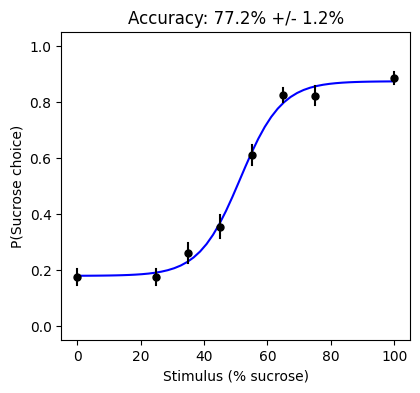

In [7]:
fig, ax = plt.subplots(figsize=(4.5, 4));
p_left_mat = np.empty([0, n_stims])
p_left_mat_exp = np.empty([0, n_stims])
for i_session, session in enumerate(included_sessions):
    p_left = output_noise['all_p_left'][i_session]
    p_left_mat = np.vstack([p_left_mat, p_left])
    p_left_exp = np.array([all_data[session][2].flatten()[all_data[session][1].flatten() == stim].mean()
                           for stim in unique_stims])
    p_left_mat_exp = np.vstack([p_left_mat_exp, p_left_exp])
ave_p_left = p_left_mat.mean(axis=0)
std_p_left = p_left_mat.std(axis=0) / np.sqrt(p_left_mat.shape[0])
psycho_res = fit_psychometric(unique_stims, ave_p_left)
ax.plot(psycho_res['x'], psycho_res['y'], 'b');
for i_stim, stim in enumerate(unique_stims):
    ax.plot([stim, stim], [ave_p_left[i_stim] - std_p_left[i_stim], ave_p_left[i_stim] + std_p_left[i_stim]], 'k');
    ax.plot(stim, ave_p_left[i_stim], '.k', markersize=10);
ax.set_ylim([-0.05, 1.05]);
ax.set_xlabel('Stimulus (% sucrose)');
ax.set_ylabel('P(Sucrose choice)');
accs = output_noise['all_accuracies']
accs_exp = []
for session in included_sessions:
    mask = np.array([s in unique_stims for s in all_data[session][1]])
    accs_exp.append(all_data[session][3][mask].mean())
ax.set_title('Accuracy: {:.1f}% +/- {:.1f}%'.format(100 * np.mean(accs), 100 * np.std(accs) / np.sqrt(n_sessions)));

# Figure 5B
# plt.savefig('plots/model/model_accuracy.pdf');

In [8]:
# compare experiment and model
Y = np.array([p_left_mat.mean(axis=0), p_left_mat_exp.mean(axis=0)])

psycho_res_model = fit_psychometric(unique_stims, Y[0, :])
print('Model psychometric slope: {:.4f}'.format(psycho_res_model['slope']))
psycho_res_exp = fit_psychometric(unique_stims, Y[1, :])
print('Experiment psychometric slope: {:.4f}\n'.format(psycho_res_exp['slope']))

res = psychometric_comparison_test(unique_stims, Y)
print('Psychometric comparison:')
print('    F = {:.4f}'.format(res['F']))
print('    p = {:.4f}\n'.format(res['p']))

print('Model mean accuracy: {:.4f}%'.format(100 * np.mean(accs)))
print('Animal mean accuracy: {:.4f}%'.format(100 * np.mean(accs_exp)))
res = scipy.stats.ttest_ind(accs, accs_exp)
print('Accuracy comparison via t test: p = {:.4f}'.format(res.pvalue))
res = scipy.stats.mannwhitneyu(accs, accs_exp)
print('Accuracy comparison via rank sum: p = {:.4f}'.format(res.pvalue))

Model psychometric slope: 0.1534
Experiment psychometric slope: 0.0764

Psychometric comparison:
    F = 16.0334
    p = 0.0007

Model mean accuracy: 77.2283%
Animal mean accuracy: 77.1598%
Accuracy comparison via t test: p = 0.9644
Accuracy comparison via rank sum: p = 0.8864


### Analyze goodness of fit to neural data

In [9]:
ys = []
y_hats = []

for session in included_sessions:
    
    X, y_conc, y_choice, y_outcome, _ = all_data[session]
    n_neurons = X.shape[1]
    
    y = np.zeros((n_stims, n_bins, n_neurons))
    for i_stim, stim in enumerate(unique_stims):
        trial_mask = (y_conc == stim) & (y_outcome == 1)
        for i_neuron in range(n_neurons):
            psth = X[trial_mask, i_neuron, :].mean(axis=0)
            y[i_stim, :, i_neuron] = psth
    
    net = all_models[session]
    # turn off internal noise too for this simulation
    net_no_noise = net.clone()
    net_no_noise.noise_std = 0
    output, traj = net_no_noise(inputs, initial_states=None, return_dynamics=True)
    y_hat = output[:, :, :n_neurons].detach().numpy()
    
    ys.append(y)
    y_hats.append(y_hat)

sses_all = []
for i_session in range(len(ys)):
    sses = []
    for i_neuron in range(ys[i_session].shape[2]):
        sse = 0
        for i_stim, stim in enumerate(unique_stims):
            y = ys[i_session][i_stim, :, i_neuron]
            y_hat = y_hats[i_session][i_stim, :, i_neuron]
            sse += ((y - y_hat) ** 2).sum()
        sse /= (n_stims * n_bins)
        sses.append(sse)
    sses_all.append(sses)

In [10]:
sses = []
for sses_ in sses_all:
    sses += sses_

print('Mean MSE: {:.4f}'.format(np.mean(sses)))
print('Median MSE: {:.4f}'.format(np.median(sses)))
print('Mean RMSE: {:.4f}'.format(np.mean(np.sqrt(sses))))
print('Median RMSE: {:.4f}'.format(np.median(np.sqrt(sses))))

Mean MSE: 4.6732
Median MSE: 1.5768
Mean RMSE: 1.6290
Median RMSE: 1.2557


SSE: 3.3279
RSSE: 1.8243


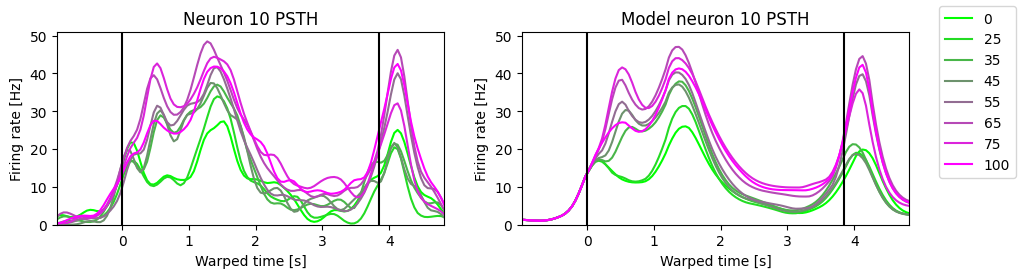

In [11]:
## example constrained neuron (no noise)

i_session = 2
i_neuron = 9

fig, axes = plt.subplots(1, 2, figsize=(11, 2.5));
sse = 0
for i_stim, stim in enumerate(unique_stims):
    y = ys[i_session][i_stim, :, i_neuron]
    y_hat = y_hats[i_session][i_stim, :, i_neuron]
    sse += ((y - y_hat) ** 2).sum()
    axes[0].plot(t, y, color=colors[i_stim, :]);
    axes[1].plot(t, y_hat, color=colors[i_stim, :]);
sse = sse / n_stims / n_bins
fig.legend([stim for stim in unique_stims]);
for i_ax, ax in enumerate(axes):
    ax.set_xlim([t[0], t[-1]]);
    ax.set_xlabel('Warped time [s]');
    y_max = max([ax.get_ylim()[1] for ax in axes])
    ax.set_ylim([0, y_max]);
    ax.set_ylabel('Firing rate [Hz]');
    ax.axvline(0, color='k');
    ax.axvline(t_D, color='k'); 
    if (i_ax == 0):
        ax.title.set_text('Neuron {} PSTH'.format(i_neuron + 1));
    elif (i_ax == 1):
        ax.title.set_text('Model neuron {} PSTH'.format(i_neuron + 1));
        
# Figure 5C
# plt.savefig('plots/model/model_example_constrained_psth_5.pdf');

print('SSE: {:.4f}'.format(sse))
print('RSSE: {:.4f}'.format(np.sqrt(sse)))

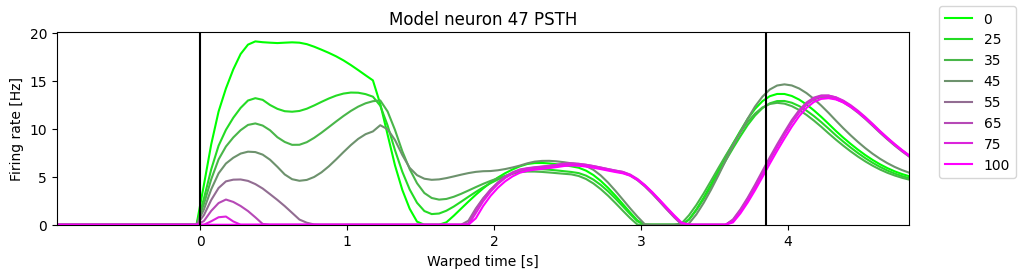

In [12]:
## example unconstrained neuron (no noise)

i_session = 1
i_neuron = 3

fig, ax = plt.subplots(figsize=(11, 2.5));
net = all_models[included_sessions[i_session]].clone()
net.noise_std = 0
n_neurons = net.observed_size
_, traj = net(inputs, initial_states=None, return_dynamics=True)
y_hats = net.non_linearity(traj[:, 1:, :].detach() + net.b.detach()).numpy()
for i_stim, stim in enumerate(unique_stims):
    y_hat = y_hats[i_stim, :, n_neurons + i_neuron]
    ax.plot(t, y_hat, color=colors[i_stim, :]);
fig.legend([stim for stim in unique_stims]);
ax.set_xlim([t[0], t[-1]]);
ax.set_xlabel('Warped time [s]');
ax.set_ylim([0, ax.get_ylim()[1]]);
ax.set_ylabel('Firing rate [Hz]');
ax.axvline(0, color='k');
ax.axvline(t_D, color='k'); 
ax.title.set_text('Model neuron {} PSTH'.format(n_neurons + i_neuron));

# Figure 5D
# plt.savefig('plots/model/model_example_unconstrained_psth.pdf');

### Responsivity and selectivity

In [13]:
try:
    with open('data/model/responsivity_and_selectivity.pkl', 'rb') as file:
        res = pickle.load(file) # a dictionary with a key for each i_session
        file.close()
except:
    res = model_responsive_and_selective_tests(output_noise, list(range(len(included_sessions))), t, 
                                               width=0.5, base_left=-0.5, correct_only=True)
    with open('data/model/responsivity_and_selectivity.pkl', 'wb') as file:
        pickle.dump(res, file)
        file.close()

In [14]:
alpha = 0.01

is_taste_responsive_list, is_taste_selective_list = [], []
is_delay_responsive_list, is_delay_selective_list = [], []
taste_change_list = []
delay_change_list = []
psths_list = []

for i_session in res:
    is_taste_responsive_i = []
    taste_change_i = []
    is_taste_selective_i = []
    is_delay_responsive_i = []
    delay_change_i = []
    is_delay_selective_i = []
    psths_i = []
    for i_neuron in res[i_session]:
        base = res[i_session][i_neuron]['fr_baseline'].mean()
        r = res[i_session][i_neuron]['fr_sampling'].mean()
        p = res[i_session][i_neuron]['p_responsive_sampling']
        is_taste_responsive_i.append(p < alpha)
        taste_change_i.append(r > base)
        r = res[i_session][i_neuron]['fr_delay'].mean()
        p = res[i_session][i_neuron]['p_responsive_delay']
        is_delay_responsive_i.append(p < alpha)
        delay_change_i.append(r > base)
        p = res[i_session][i_neuron]['p_selective_sampling']
        is_taste_selective_i.append(p < alpha)
        p = res[i_session][i_neuron]['p_selective_delay']
        is_delay_selective_i.append(p < alpha)
        psths_i.append(res[i_session][i_neuron]['psth'] - base)
    is_taste_responsive_list.append(np.array(is_taste_responsive_i))
    is_taste_selective_list.append(np.array(is_taste_selective_i))
    is_delay_responsive_list.append(np.array(is_delay_responsive_i))
    is_delay_selective_list.append(np.array(is_delay_selective_i))
    taste_change_list.append(np.array(taste_change_i))
    delay_change_list.append(np.array(delay_change_i))
    psths_list.append(np.array(psths_i))
        
is_taste_responsive = np.hstack(is_taste_responsive_list)
taste_change = np.hstack(taste_change_list)
is_taste_selective = is_taste_responsive & np.hstack(is_taste_selective_list)
is_delay_responsive = np.hstack(is_delay_responsive_list)
delay_change = np.hstack(delay_change_list)
is_delay_selective = is_delay_responsive & np.hstack(is_delay_selective_list)
psths = np.vstack(psths_list)

In [15]:
print('{}/{} ({:.1f}%) neurons are taste-responsive'.format(
    is_taste_responsive.sum(), len(is_taste_responsive), 
    100 * is_taste_responsive.sum() / len(is_taste_responsive)
))
print('{}/{} ({:.1f}%) neurons are taste-selective\n'.format(
    is_taste_selective.sum(), len(is_taste_selective),
    100 * is_taste_selective.sum() / len(is_taste_selective)
))
print('{}/{} ({:.1f}%) neurons are delay-responsive'.format(
    is_delay_responsive.sum(), len(is_delay_responsive),
    100 * is_delay_responsive.sum() / len(is_delay_responsive)
))
print('{}/{} ({:.1f}%) neurons are delay-selective\n'.format(
    is_delay_selective.sum(), len(is_delay_selective),
    100 * is_delay_selective.sum() / len(is_delay_selective)
))
print('{}/{} ({:.1f}%) neurons are responsive to both'.format(
    (is_delay_responsive & is_taste_responsive).sum(), len(is_delay_responsive),
    100 * (is_delay_responsive & is_taste_responsive).sum() / len(is_delay_responsive)
))

1832/3681 (49.8%) neurons are taste-responsive
1001/3681 (27.2%) neurons are taste-selective

1502/3681 (40.8%) neurons are delay-responsive
797/3681 (21.7%) neurons are delay-selective

1134/3681 (30.8%) neurons are responsive to both


In [16]:
print('Session | Total (Con / Unc) | Taste Responsive | Taste Selective | Delay Responsive | Delay Selective')
print('-----------------------------------------------------------------------------------------------------')
for i, sess in enumerate(res):
    n_total = len(is_taste_responsive_list[i])
    n_con = int(round(n_total / 5.88))
    if int(round(5.88 * n_con)) != n_total: raise ValueError('backwards rounding failed')
    print('{:7} | {:8}/{:8} | {:7}/{:8} | {:7}/{:7} | {:7}/{:8} | {:7}/{:7}'
         .format(sess, n_con, n_total - n_con,
                is_taste_responsive_list[i][:n_con].sum(), is_taste_responsive_list[i][n_con:].sum(),
                is_taste_selective_list[i][:n_con].sum(), is_taste_selective_list[i][n_con:].sum(),
                is_delay_responsive_list[i][:n_con].sum(), is_delay_responsive_list[i][n_con:].sum(),
                is_delay_selective_list[i][:n_con].sum(), is_delay_selective_list[i][n_con:].sum()))

Session | Total (Con / Unc) | Taste Responsive | Taste Selective | Delay Responsive | Delay Selective
-----------------------------------------------------------------------------------------------------
      0 |       17/      83 |      10/      55 |      10/     42 |       8/      48 |       5/     38
      1 |       44/     215 |       9/      25 |       5/     15 |      10/      14 |       7/     10
      2 |       21/     102 |      11/      62 |       8/     38 |      13/      51 |       8/     42
      3 |       48/     234 |      10/      79 |       9/     52 |       9/      59 |      10/     49
      4 |       29/     142 |      20/      97 |       8/     77 |      19/      74 |      13/     79
      5 |       68/     332 |      25/     144 |      20/    109 |      30/     115 |      18/    115
      6 |       16/      78 |      10/      45 |       7/     27 |      12/      36 |      13/     42
      7 |       41/     200 |      19/      79 |      13/     64 |      17/      6

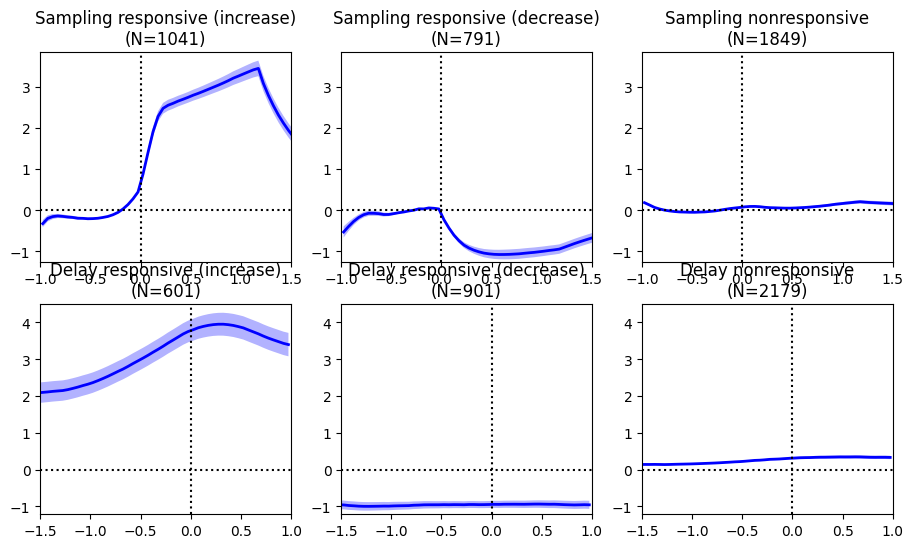

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(11, 6));

t_align_T = t
t_align_D = t - (t[-1] - 1 + 0.025)

y_low, y_high = 0, 0
mat = psths[is_taste_responsive & (taste_change == 1), :]
mean_ = mat.mean(axis=0)
std_ = mat.std(axis=0) / np.sqrt(mat.shape[0])
patch = plt.Polygon(
    [[t_align_T[i], mean_[i] - std_[i]] for i in range(len(t))] + [[t_align_T[i], mean_[i] + std_[i]] 
                                                                   for i in range(len(t))[::-1]],
    facecolor='b',
    edgecolor=None,
    alpha=0.3
)
axes[0, 0].add_patch(patch);
axes[0, 0].plot(t_align_T, mean_, color='b', linewidth=2);
axes[0, 0].axvline(0, color='k', linestyle=':');
axes[0, 0].axhline(0, color='k', linestyle=':');
axes[0, 0].set_title('Sampling responsive (increase)\n(N={})'.format(mat.shape[0]));
axes[0, 0].set_xlim([-1, 1.5]);
y_low, y_high = min(y_low, axes[0, 0].get_ylim()[0]), max(y_high, axes[0, 0].get_ylim()[1])
    
mat = psths[is_taste_responsive & (taste_change == 0), :]
mean_ = mat.mean(axis=0)
std_ = mat.std(axis=0) / np.sqrt(mat.shape[0])
patch = plt.Polygon(
    [[t_align_T[i], mean_[i] - std_[i]] for i in range(len(t))] + [[t_align_T[i], mean_[i] + std_[i]] 
                                                                   for i in range(len(t))[::-1]],
    facecolor='b',
    edgecolor=None,
    alpha=0.3
)
axes[0, 1].add_patch(patch);
axes[0, 1].plot(t_align_T, mean_, color='b', linewidth=2);
axes[0, 1].axvline(0, color='k', linestyle=':');
axes[0, 1].axhline(0, color='k', linestyle=':');
axes[0, 1].set_title('Sampling responsive (decrease)\n(N={})'.format(mat.shape[0]));
axes[0, 1].set_xlim([-1, 1.5]);
y_low, y_high = min(y_low, axes[0, 1].get_ylim()[0]), max(y_high, axes[0, 1].get_ylim()[1])
    
mat = psths[~is_taste_responsive, :]
mean_ = mat.mean(axis=0)
std_ = mat.std(axis=0) / np.sqrt(mat.shape[0])
patch = plt.Polygon(
    [[t_align_T[i], mean_[i] - std_[i]] for i in range(len(t))] + [[t_align_T[i], mean_[i] + std_[i]] 
                                                                   for i in range(len(t))[::-1]],
    facecolor='b',
    edgecolor=None,
    alpha=0.3
)
axes[0, 2].add_patch(patch);
axes[0, 2].plot(t_align_T, mean_, color='b', linewidth=2);
axes[0, 2].axvline(0, color='k', linestyle=':');
axes[0, 2].axhline(0, color='k', linestyle=':');
axes[0, 2].set_title('Sampling nonresponsive\n(N={})'.format(mat.shape[0]));
axes[0, 2].set_xlim([-1, 1.5]);
y_low, y_high = min(y_low, axes[0, 2].get_ylim()[0]), max(y_high, axes[0, 2].get_ylim()[1])

for i in range(3): axes[0, i].set_ylim([y_low, y_high]);
    
y_low, y_high = 0, 0
mat = psths[is_delay_responsive & (delay_change == 1), :]
mean_ = mat.mean(axis=0)
std_ = mat.std(axis=0) / np.sqrt(mat.shape[0])
patch = plt.Polygon(
    [[t_align_D[i], mean_[i] - std_[i]] for i in range(len(t))] + [[t_align_D[i], mean_[i] + std_[i]] 
                                                                   for i in range(len(t))[::-1]],
    facecolor='b',
    edgecolor=None,
    alpha=0.3
)
axes[1, 0].add_patch(patch);
axes[1, 0].plot(t_align_D, mean_, color='b', linewidth=2);
axes[1, 0].axvline(0, color='k', linestyle=':');
axes[1, 0].axhline(0, color='k', linestyle=':');
axes[1, 0].set_title('Delay responsive (increase)\n(N={})'.format(mat.shape[0]));
axes[1, 0].set_xlim([-1.5, 1]);
y_low, y_high = min(y_low, axes[1, 0].get_ylim()[0]), max(y_high, axes[1, 0].get_ylim()[1])
    
mat = psths[is_delay_responsive & (delay_change == 0), :]
mean_ = mat.mean(axis=0)
std_ = mat.std(axis=0) / np.sqrt(mat.shape[0])
patch = plt.Polygon(
    [[t_align_D[i], mean_[i] - std_[i]] for i in range(len(t))] + [[t_align_D[i], mean_[i] + std_[i]] 
                                                                   for i in range(len(t))[::-1]],
    facecolor='b',
    edgecolor=None,
    alpha=0.3
)
axes[1, 1].add_patch(patch);
axes[1, 1].plot(t_align_D, mean_, color='b', linewidth=2);
axes[1, 1].axvline(0, color='k', linestyle=':');
axes[1, 1].axhline(0, color='k', linestyle=':');
axes[1, 1].set_title('Delay responsive (decrease)\n(N={})'.format(mat.shape[0]));
axes[1, 1].set_xlim([-1.5, 1]);
y_low, y_high = min(y_low, axes[1, 1].get_ylim()[0]), max(y_high, axes[1, 1].get_ylim()[1])

mat = psths[~is_delay_responsive, :]
mean_ = mat.mean(axis=0)
std_ = mat.std(axis=0) / np.sqrt(mat.shape[0])
patch = plt.Polygon(
    [[t_align_D[i], mean_[i] - std_[i]] for i in range(len(t))] + [[t_align_D[i], mean_[i] + std_[i]] 
                                                                   for i in range(len(t))[::-1]],
    facecolor='b',
    edgecolor=None,
    alpha=0.3
)
axes[1, 2].add_patch(patch);
axes[1, 2].plot(t_align_D, mean_, color='b', linewidth=2);
axes[1, 2].axvline(0, color='k', linestyle=':');
axes[1, 2].axhline(0, color='k', linestyle=':');
axes[1, 2].set_title('Delay nonresponsive\n(N={})'.format(mat.shape[0]));
axes[1, 2].set_xlim([-1.5, 1]);
y_low, y_high = min(y_low, axes[1, 2].get_ylim()[0]), max(y_high, axes[1, 2].get_ylim()[1])

for i in range(3): axes[1, i].set_ylim([y_low, y_high]);

# Figure 5 - Supplement 2 A-B
# plt.savefig('plots/model/responsive_units.pdf');

### Single unit response profiles

In [18]:
# constrained only

labels_over_time = []
for i_t in range(len(t_downsample)):
    labels = []
    for i_model in range(len(included_sessions)):
        labels_i = output_noise['all_labels'][i_model][i_t]
        n_total = len(labels_i)
        n_con = int(round(n_total / 5.88))
        if int(round(5.88 * n_con)) != n_total: raise ValueError('backwards rounding failed')
        labels += labels_i[:n_con]
    labels_over_time.append(labels)
n_neurons_all = np.sum([all_models[i].observed_size for i in included_sessions])
is_linear = np.full(n_neurons_all, False)
is_perception = np.full(n_neurons_all, False)
is_choice = np.full(n_neurons_all, False)
for i_neuron in range(n_neurons_all):
    label_seq = [labels_over_time[i_t][i_neuron] for i_t in range(len(labels_over_time))]
    is_linear[i_neuron] = 'Linear' in label_seq
    is_perception[i_neuron] = 'Step (Perception)' in label_seq
    is_choice[i_neuron] = 'Step (Choice)' in label_seq
N_coding = (is_linear | is_perception | is_choice).sum()
den = n_neurons_all

Peak fraction of coding units (non-Other): 0.1389776357827476


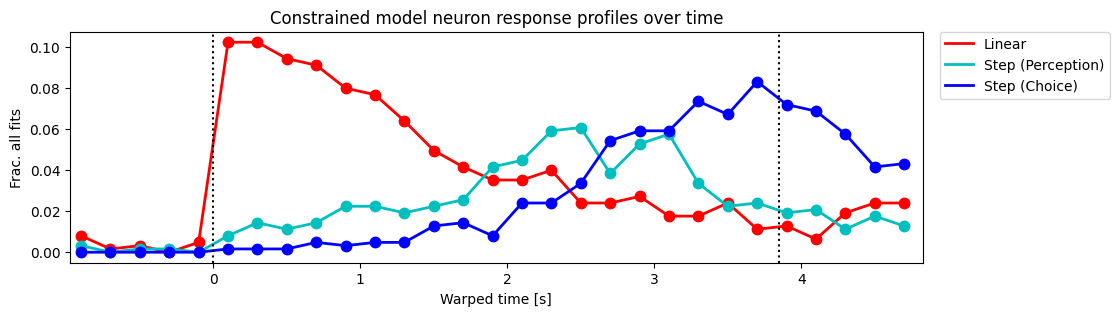

In [19]:
fig, ax = plt.subplots(figsize=(11, 3));
n_lin = np.array([sum([label == 'Linear' for label in labels]) for labels in labels_over_time])
ax.plot(t_downsample, n_lin / den, '.r', markersize=15);
p1, = ax.plot(t_downsample, n_lin / den, 'r', linewidth=2);
n_perc = np.array([sum([label == 'Step (Perception)' for label in labels]) for labels in labels_over_time])
ax.plot(t_downsample, n_perc / den, '.c', markersize=15);
p2, = ax.plot(t_downsample, n_perc / den, 'c', linewidth=2);
n_choice = np.array([sum([label == 'Step (Choice)' for label in labels]) for labels in labels_over_time])
ax.plot(t_downsample, n_choice / den, '.b', markersize=15);
p3, = ax.plot(t_downsample, n_choice / den, 'b', linewidth=2);
ax.set_xlim([t[0], t[-1]]);
ax.set_xlabel('Warped time [s]');
ax.set_ylabel('Frac. all fits');
ax.axvline(0, color='k', linestyle=':');
ax.axvline(t_D, color='k', linestyle=':');
ax.legend([p1, p2, p3], ['Linear', 'Step (Perception)', 'Step (Choice)'], 
          bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.);
ax.set_title('Constrained model neuron response profiles over time');

# Figure 6 - Supplement 1 C
# plt.savefig('plots/review/model/model_response_profiles_over_time_constrained.pdf');

print('Peak fraction of coding units (non-Other):', ((n_lin + n_perc + n_choice) / n_neurons_all).max())

In [20]:
print('Breakdown of constrained neurons ({}):\n'.format(n_neurons_all))
print('    Linear AND Perception AND Choice: {} ({:.1f}%)'.format( 
      (is_linear & is_perception & is_choice).sum(),
        100 * (is_linear & is_perception & is_choice).sum() / n_neurons_all
))
print('    Linear AND Perception AND NOT Choice: {} ({:.1f}%)'.format( 
      (is_linear & is_perception & ~is_choice).sum(),
        100 * (is_linear & is_perception & ~is_choice).sum() / n_neurons_all
))
print('    Linear AND NOT Perception AND Choice: {} ({:.1f}%)'.format( 
      (is_linear & ~is_perception & is_choice).sum(),
        100 * (is_linear & ~is_perception & is_choice).sum() / n_neurons_all
))
print('    Linear AND NOT Perception AND NOT Choice: {} ({:.1f}%)'.format( 
      (is_linear & ~is_perception & ~is_choice).sum(),
        100 * (is_linear & ~is_perception & ~is_choice).sum() / n_neurons_all
))
print('    NOT Linear AND Perception AND Choice: {} ({:.1f}%)'.format( 
      (~is_linear & is_perception & is_choice).sum(),
        100 * (~is_linear & is_perception & is_choice).sum() / n_neurons_all
))
print('    NOT Linear AND Perception AND NOT Choice: {} ({:.1f}%)'.format( 
      (~is_linear & is_perception & ~is_choice).sum(),
        100 * (~is_linear & is_perception & ~is_choice).sum() / n_neurons_all
))
print('    NOT Linear AND NOT Perception AND Choice: {} ({:.1f}%)'.format( 
      (~is_linear & ~is_perception & is_choice).sum(),
        100 * (~is_linear & ~is_perception & is_choice).sum() / n_neurons_all
))
print('    NOT Linear AND NOT Perception AND NOT Choice: {} ({:.1f}%)\n'.format( 
      (~is_linear & ~is_perception & ~is_choice).sum(),
        100 * (~is_linear & ~is_perception & ~is_choice).sum() / n_neurons_all
))
print('    Linear: {} ({:.1f}%)'.format( 
      is_linear.sum(),
        100 * is_linear.sum() / n_neurons_all
))
print('    Perception: {} ({:.1f}%)'.format( 
      is_perception.sum(),
        100 * is_perception.sum() / n_neurons_all
))
print('    Choice: {} ({:.1f}%)\n'.format( 
      is_choice.sum(),
        100 * is_choice.sum() / n_neurons_all
))

Breakdown of constrained neurons (626):

    Linear AND Perception AND Choice: 45 (7.2%)
    Linear AND Perception AND NOT Choice: 38 (6.1%)
    Linear AND NOT Perception AND Choice: 49 (7.8%)
    Linear AND NOT Perception AND NOT Choice: 62 (9.9%)
    NOT Linear AND Perception AND Choice: 20 (3.2%)
    NOT Linear AND Perception AND NOT Choice: 44 (7.0%)
    NOT Linear AND NOT Perception AND Choice: 15 (2.4%)
    NOT Linear AND NOT Perception AND NOT Choice: 353 (56.4%)

    Linear: 194 (31.0%)
    Perception: 147 (23.5%)
    Choice: 129 (20.6%)



In [21]:
# unconstrained only

labels_over_time = []
for i_t in range(len(t_downsample)):
    labels = []
    for i_model in range(len(included_sessions)):
        labels_i = output_noise['all_labels'][i_model][i_t]
        n_total = len(labels_i)
        n_con = int(round(n_total / 5.88))
        if int(round(5.88 * n_con)) != n_total: raise ValueError('backwards rounding failed')
        labels += labels_i[n_con:]
    labels_over_time.append(labels)
n_neurons_all = np.sum([all_models[i].network_size - all_models[i].observed_size for i in included_sessions])
is_linear = np.full(n_neurons_all, False)
is_perception = np.full(n_neurons_all, False)
is_choice = np.full(n_neurons_all, False)
for i_neuron in range(n_neurons_all):
    label_seq = [labels_over_time[i_t][i_neuron] for i_t in range(len(labels_over_time))]
    is_linear[i_neuron] = 'Linear' in label_seq
    is_perception[i_neuron] = 'Step (Perception)' in label_seq
    is_choice[i_neuron] = 'Step (Choice)' in label_seq
N_coding = (is_linear | is_perception | is_choice).sum()
den = n_neurons_all

Peak fraction of coding units (non-Other): 0.15613747954173485


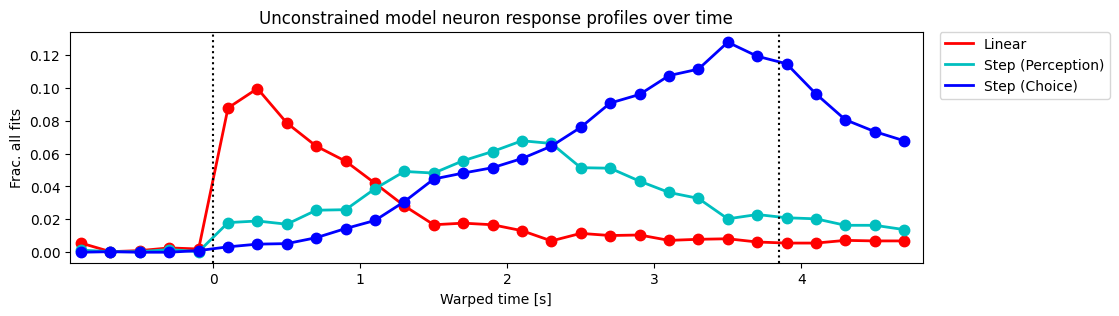

In [22]:
fig, ax = plt.subplots(figsize=(11, 3));
n_lin = np.array([sum([label == 'Linear' for label in labels]) for labels in labels_over_time])
ax.plot(t_downsample, n_lin / den, '.r', markersize=15);
p1, = ax.plot(t_downsample, n_lin / den, 'r', linewidth=2);
n_perc = np.array([sum([label == 'Step (Perception)' for label in labels]) for labels in labels_over_time])
ax.plot(t_downsample, n_perc / den, '.c', markersize=15);
p2, = ax.plot(t_downsample, n_perc / den, 'c', linewidth=2);
n_choice = np.array([sum([label == 'Step (Choice)' for label in labels]) for labels in labels_over_time])
ax.plot(t_downsample, n_choice / den, '.b', markersize=15);
p3, = ax.plot(t_downsample, n_choice / den, 'b', linewidth=2);
ax.set_xlim([t[0], t[-1]]);
ax.set_xlabel('Warped time [s]');
ax.set_ylabel('Frac. all fits');
ax.axvline(0, color='k', linestyle=':');
ax.axvline(t_D, color='k', linestyle=':');
ax.legend([p1, p2, p3], ['Linear', 'Step (Perception)', 'Step (Choice)'], 
          bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.);
ax.set_title('Unconstrained model neuron response profiles over time');

# Figure 6 - Supplement 2 C
# plt.savefig('plots/review/model/model_response_profiles_over_time_unconstrained.pdf');

print('Peak fraction of coding units (non-Other):', ((n_lin + n_perc + n_choice) / n_neurons_all).max())

In [23]:
print('Breakdown of unconstrained neurons ({}):\n'.format(n_neurons_all))
print('    Linear AND Perception AND Choice: {} ({:.1f}%)'.format( 
      (is_linear & is_perception & is_choice).sum(),
        100 * (is_linear & is_perception & is_choice).sum() / n_neurons_all
))
print('    Linear AND Perception AND NOT Choice: {} ({:.1f}%)'.format( 
      (is_linear & is_perception & ~is_choice).sum(),
        100 * (is_linear & is_perception & ~is_choice).sum() / n_neurons_all
))
print('    Linear AND NOT Perception AND Choice: {} ({:.1f}%)'.format( 
      (is_linear & ~is_perception & is_choice).sum(),
        100 * (is_linear & ~is_perception & is_choice).sum() / n_neurons_all
))
print('    Linear AND NOT Perception AND NOT Choice: {} ({:.1f}%)'.format( 
      (is_linear & ~is_perception & ~is_choice).sum(),
        100 * (is_linear & ~is_perception & ~is_choice).sum() / n_neurons_all
))
print('    NOT Linear AND Perception AND Choice: {} ({:.1f}%)'.format( 
      (~is_linear & is_perception & is_choice).sum(),
        100 * (~is_linear & is_perception & is_choice).sum() / n_neurons_all
))
print('    NOT Linear AND Perception AND NOT Choice: {} ({:.1f}%)'.format( 
      (~is_linear & is_perception & ~is_choice).sum(),
        100 * (~is_linear & is_perception & ~is_choice).sum() / n_neurons_all
))
print('    NOT Linear AND NOT Perception AND Choice: {} ({:.1f}%)'.format( 
      (~is_linear & ~is_perception & is_choice).sum(),
        100 * (~is_linear & ~is_perception & is_choice).sum() / n_neurons_all
))
print('    NOT Linear AND NOT Perception AND NOT Choice: {} ({:.1f}%)\n'.format( 
      (~is_linear & ~is_perception & ~is_choice).sum(),
        100 * (~is_linear & ~is_perception & ~is_choice).sum() / n_neurons_all
))
print('    Linear: {} ({:.1f}%)'.format( 
      is_linear.sum(),
        100 * is_linear.sum() / n_neurons_all
))
print('    Perception: {} ({:.1f}%)'.format( 
      is_perception.sum(),
        100 * is_perception.sum() / n_neurons_all
))
print('    Choice: {} ({:.1f}%)\n'.format( 
      is_choice.sum(),
        100 * is_choice.sum() / n_neurons_all
))

Breakdown of unconstrained neurons (3055):

    Linear AND Perception AND Choice: 276 (9.0%)
    Linear AND Perception AND NOT Choice: 137 (4.5%)
    Linear AND NOT Perception AND Choice: 118 (3.9%)
    Linear AND NOT Perception AND NOT Choice: 160 (5.2%)
    NOT Linear AND Perception AND Choice: 222 (7.3%)
    NOT Linear AND Perception AND NOT Choice: 205 (6.7%)
    NOT Linear AND NOT Perception AND Choice: 198 (6.5%)
    NOT Linear AND NOT Perception AND NOT Choice: 1739 (56.9%)

    Linear: 691 (22.6%)
    Perception: 840 (27.5%)
    Choice: 814 (26.6%)



In [24]:
# all

labels_over_time = []
for i_t in range(len(t_downsample)):
    labels = []
    for i_model in range(len(included_sessions)):
        labels += output_noise['all_labels'][i_model][i_t]
    labels_over_time.append(labels)
n_neurons_all = np.sum([all_models[i].network_size for i in included_sessions])
is_linear = np.full(n_neurons_all, False)
is_perception = np.full(n_neurons_all, False)
is_choice = np.full(n_neurons_all, False)
for i_neuron in range(n_neurons_all):
    label_seq = [labels_over_time[i_t][i_neuron] for i_t in range(len(labels_over_time))]
    is_linear[i_neuron] = 'Linear' in label_seq
    is_perception[i_neuron] = 'Step (Perception)' in label_seq
    is_choice[i_neuron] = 'Step (Choice)' in label_seq
N_coding = (is_linear | is_perception | is_choice).sum()
den = n_neurons_all

Peak fraction of coding units (non-Other): 0.1488725889703885


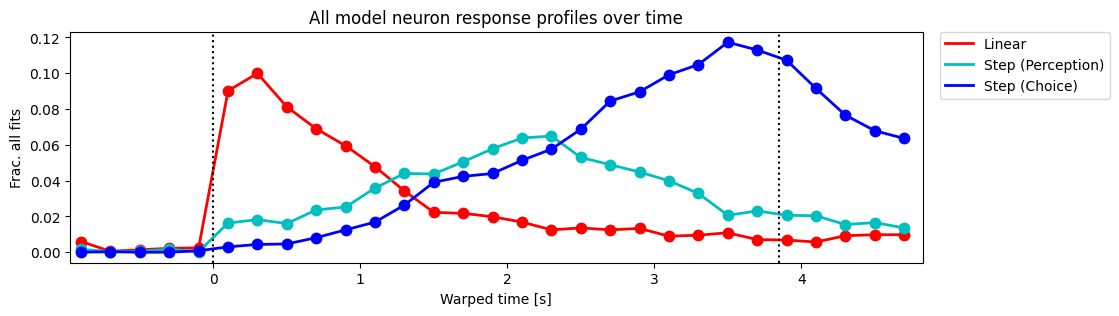

In [25]:
fig, ax = plt.subplots(figsize=(11, 3));
n_lin = np.array([sum([label == 'Linear' for label in labels]) for labels in labels_over_time])
ax.plot(t_downsample, n_lin / den, '.r', markersize=15);
p1, = ax.plot(t_downsample, n_lin / den, 'r', linewidth=2);
n_perc = np.array([sum([label == 'Step (Perception)' for label in labels]) for labels in labels_over_time])
ax.plot(t_downsample, n_perc / den, '.c', markersize=15);
p2, = ax.plot(t_downsample, n_perc / den, 'c', linewidth=2);
n_choice = np.array([sum([label == 'Step (Choice)' for label in labels]) for labels in labels_over_time])
ax.plot(t_downsample, n_choice / den, '.b', markersize=15);
p3, = ax.plot(t_downsample, n_choice / den, 'b', linewidth=2);
ax.set_xlim([t[0], t[-1]]);
ax.set_xlabel('Warped time [s]');
ax.set_ylabel('Frac. all fits');
ax.axvline(0, color='k', linestyle=':');
ax.axvline(t_D, color='k', linestyle=':');
ax.legend([p1, p2, p3], ['Linear', 'Step (Perception)', 'Step (Choice)'], 
          bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.);
ax.set_title('All model neuron response profiles over time');

# Figure 6C
# plt.savefig('plots/model/model_response_profiles_over_time.pdf');

print('Peak fraction of coding units (non-Other):', ((n_lin + n_perc + n_choice) / n_neurons_all).max())

In [26]:
print('Breakdown of all neurons ({}):\n'.format(n_neurons_all))
print('    Linear AND Perception AND Choice: {} ({:.1f}%)'.format( 
      (is_linear & is_perception & is_choice).sum(),
        100 * (is_linear & is_perception & is_choice).sum() / n_neurons_all
))
print('    Linear AND Perception AND NOT Choice: {} ({:.1f}%)'.format( 
      (is_linear & is_perception & ~is_choice).sum(),
        100 * (is_linear & is_perception & ~is_choice).sum() / n_neurons_all
))
print('    Linear AND NOT Perception AND Choice: {} ({:.1f}%)'.format( 
      (is_linear & ~is_perception & is_choice).sum(),
        100 * (is_linear & ~is_perception & is_choice).sum() / n_neurons_all
))
print('    Linear AND NOT Perception AND NOT Choice: {} ({:.1f}%)'.format( 
      (is_linear & ~is_perception & ~is_choice).sum(),
        100 * (is_linear & ~is_perception & ~is_choice).sum() / n_neurons_all
))
print('    NOT Linear AND Perception AND Choice: {} ({:.1f}%)'.format( 
      (~is_linear & is_perception & is_choice).sum(),
        100 * (~is_linear & is_perception & is_choice).sum() / n_neurons_all
))
print('    NOT Linear AND Perception AND NOT Choice: {} ({:.1f}%)'.format( 
      (~is_linear & is_perception & ~is_choice).sum(),
        100 * (~is_linear & is_perception & ~is_choice).sum() / n_neurons_all
))
print('    NOT Linear AND NOT Perception AND Choice: {} ({:.1f}%)'.format( 
      (~is_linear & ~is_perception & is_choice).sum(),
        100 * (~is_linear & ~is_perception & is_choice).sum() / n_neurons_all
))
print('    NOT Linear AND NOT Perception AND NOT Choice: {} ({:.1f}%)\n'.format( 
      (~is_linear & ~is_perception & ~is_choice).sum(),
        100 * (~is_linear & ~is_perception & ~is_choice).sum() / n_neurons_all
))
print('    Linear: {} ({:.1f}%)'.format( 
      is_linear.sum(),
        100 * is_linear.sum() / n_neurons_all
))
print('    Perception: {} ({:.1f}%)'.format( 
      is_perception.sum(),
        100 * is_perception.sum() / n_neurons_all
))
print('    Choice: {} ({:.1f}%)\n'.format( 
      is_choice.sum(),
        100 * is_choice.sum() / n_neurons_all
))

Breakdown of all neurons (3681):

    Linear AND Perception AND Choice: 321 (8.7%)
    Linear AND Perception AND NOT Choice: 175 (4.8%)
    Linear AND NOT Perception AND Choice: 167 (4.5%)
    Linear AND NOT Perception AND NOT Choice: 222 (6.0%)
    NOT Linear AND Perception AND Choice: 242 (6.6%)
    NOT Linear AND Perception AND NOT Choice: 249 (6.8%)
    NOT Linear AND NOT Perception AND Choice: 213 (5.8%)
    NOT Linear AND NOT Perception AND NOT Choice: 2092 (56.8%)

    Linear: 885 (24.0%)
    Perception: 987 (26.8%)
    Choice: 943 (25.6%)



In [27]:
# session-by-session results
print('Session | Total (Con/Unc) | Linear (Con/Unc) | Perception (Con/Unc) | Choice (Con/Unc) | Other (Con/Unc)')
print('--------------------------------------------------------------------------------------------------------')
for i_model in range(len(included_sessions)):
    n_total = len(output_noise['all_labels'][i_model][0])
    n_con = int(round(n_total / 5.88))
    if int(round(5.88 * n_con)) != n_total: raise ValueError('backwards rounding failed')
    n_lin_con, n_lin_unc = 0, 0
    n_perc_con, n_perc_unc = 0, 0
    n_choice_con, n_choice_unc = 0, 0
    n_other_con, n_other_unc = 0, 0
    for i_neuron in range(n_total):
        label_seq = labels_i = [output_noise['all_labels'][i_model][i_t][i_neuron] for i_t in range(len(t_downsample))]
        is_lin_ = 'Linear' in label_seq
        is_perc_ = 'Step (Perception)' in label_seq
        is_choice_ = 'Step (Choice)' in label_seq
        is_other_ = (not is_lin_) and (not is_perc_) and (not is_choice_)
        if is_lin_:
            if i_neuron < n_con:
                n_lin_con += 1
            else:
                n_lin_unc += 1
        if is_perc_:
            if i_neuron < n_con:
                n_perc_con += 1
            else:
                n_perc_unc += 1
        if is_choice_:
            if i_neuron < n_con:
                n_choice_con += 1
            else:
                n_choice_unc += 1
        if is_other_:
            if i_neuron < n_con:
                n_other_con += 1
            else:
                n_other_unc += 1
    print('{:7}   {:5} / {:5}     {:5} / {:5}      {:5} / {:5}          {:5} / {:5}      {:5} / {:5}'
          .format(i_model, n_con, n_total - n_con, 
                  n_lin_con, n_lin_unc, n_perc_con, n_perc_unc, n_choice_con, n_choice_unc, n_other_con, n_other_unc))

Session | Total (Con/Unc) | Linear (Con/Unc) | Perception (Con/Unc) | Choice (Con/Unc) | Other (Con/Unc)
--------------------------------------------------------------------------------------------------------
      0      17 /    83         5 /    17          6 /    32              6 /    42         10 /    28
      1      44 /   215         8 /     9          5 /    18              9 /    14         33 /   191
      2      21 /   102         6 /    13          4 /    29              2 /    36         14 /    56
      3      48 /   234         9 /    37          8 /    46              3 /    25         37 /   175
      4      29 /   142        11 /    57         12 /    61              3 /    57         11 /    52
      5      68 /   332        13 /    53          8 /    70             11 /    80         47 /   204
      6      16 /    78        11 /    17         12 /    34              9 /    32          3 /    39
      7      41 /   200        12 /    21          4 /    28         

In [28]:
is_other = (~is_linear & ~is_perception & ~is_choice)

print('{}/{} ({:.1f}%) Other neurons are taste-responsive'.format(
    (is_other & is_taste_responsive).sum(), is_other.sum(),
    100 * (is_other & is_taste_responsive).sum() / is_other.sum()
))
print('{}/{} ({:.1f}%) Other neurons are taste-selective\n'.format(
    (is_other & is_taste_selective).sum(), is_other.sum(),
    100 * (is_other & is_taste_selective).sum() / is_other.sum()
))

print('{}/{} ({:.1f}%) Other neurons are delay-responsive'.format(
    (is_other & is_delay_responsive).sum(), is_other.sum(),
    100 * (is_other & is_delay_responsive).sum() / is_other.sum()
))
print('{}/{} ({:.1f}%) Other neurons are delay-selective\n'.format(
    (is_other & is_delay_selective).sum(), is_other.sum(),
    100 * (is_other & is_delay_selective).sum() / is_other.sum()
))

print('{}/{} ({:.1f}%) Other neurons are responsive to both'.format(
    (is_other & is_delay_responsive & is_taste_responsive).sum(), is_other.sum(),
    100 * (is_other & is_delay_responsive & is_taste_responsive).sum() / is_other.sum()
))

615/2092 (29.4%) Other neurons are taste-responsive
197/2092 (9.4%) Other neurons are taste-selective

490/2092 (23.4%) Other neurons are delay-responsive
96/2092 (4.6%) Other neurons are delay-selective

359/2092 (17.2%) Other neurons are responsive to both


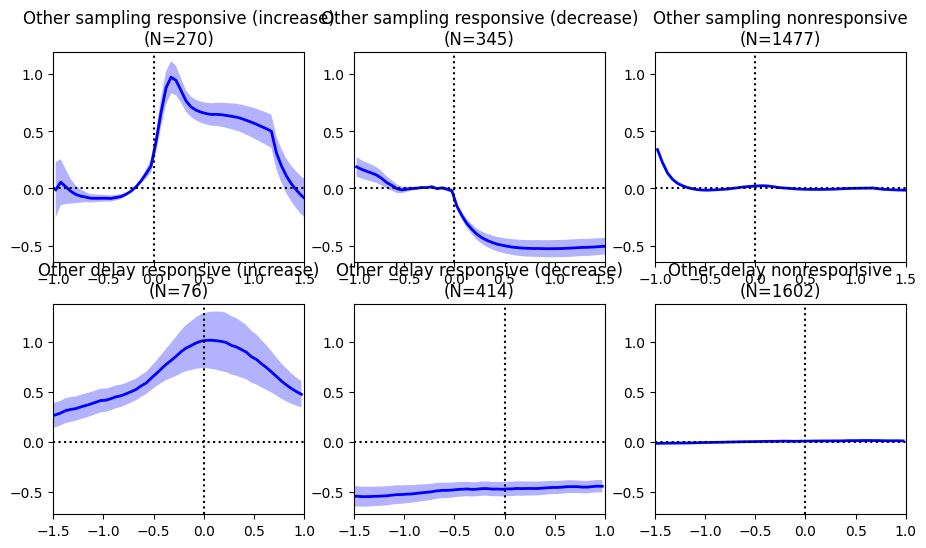

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(11, 6));

t_align_T = t
t_align_D = t - (t[-1] - 1 + 0.025)

y_low, y_high = 0, 0
mat = psths[is_other & is_taste_responsive & (taste_change == 1), :]
mean_ = mat.mean(axis=0)
std_ = mat.std(axis=0) / np.sqrt(mat.shape[0])
patch = plt.Polygon(
    [[t_align_T[i], mean_[i] - std_[i]] for i in range(len(t))] + [[t_align_T[i], mean_[i] + std_[i]] 
                                                                   for i in range(len(t))[::-1]],
    facecolor='b',
    edgecolor=None,
    alpha=0.3
)
axes[0, 0].add_patch(patch);
axes[0, 0].plot(t_align_T, mean_, color='b', linewidth=2);
axes[0, 0].axvline(0, color='k', linestyle=':');
axes[0, 0].axhline(0, color='k', linestyle=':');
axes[0, 0].set_title('Other sampling responsive (increase)\n(N={})'.format(mat.shape[0]));
axes[0, 0].set_xlim([-1, 1.5]);
y_low, y_high = min(y_low, axes[0, 0].get_ylim()[0]), max(y_high, axes[0, 0].get_ylim()[1])
    
mat = psths[is_other & is_taste_responsive & (taste_change == 0), :]
mean_ = mat.mean(axis=0)
std_ = mat.std(axis=0) / np.sqrt(mat.shape[0])
patch = plt.Polygon(
    [[t_align_T[i], mean_[i] - std_[i]] for i in range(len(t))] + [[t_align_T[i], mean_[i] + std_[i]] 
                                                                   for i in range(len(t))[::-1]],
    facecolor='b',
    edgecolor=None,
    alpha=0.3
)
axes[0, 1].add_patch(patch);
axes[0, 1].plot(t_align_T, mean_, color='b', linewidth=2);
axes[0, 1].axvline(0, color='k', linestyle=':');
axes[0, 1].axhline(0, color='k', linestyle=':');
axes[0, 1].set_title('Other sampling responsive (decrease)\n(N={})'.format(mat.shape[0]));
axes[0, 1].set_xlim([-1, 1.5]);
y_low, y_high = min(y_low, axes[0, 1].get_ylim()[0]), max(y_high, axes[0, 1].get_ylim()[1])
    
mat = psths[is_other & ~is_taste_responsive, :]
mean_ = mat.mean(axis=0)
std_ = mat.std(axis=0) / np.sqrt(mat.shape[0])
patch = plt.Polygon(
    [[t_align_T[i], mean_[i] - std_[i]] for i in range(len(t))] + [[t_align_T[i], mean_[i] + std_[i]] 
                                                                   for i in range(len(t))[::-1]],
    facecolor='b',
    edgecolor=None,
    alpha=0.3
)
axes[0, 2].add_patch(patch);
axes[0, 2].plot(t_align_T, mean_, color='b', linewidth=2);
axes[0, 2].axvline(0, color='k', linestyle=':');
axes[0, 2].axhline(0, color='k', linestyle=':');
axes[0, 2].set_title('Other sampling nonresponsive\n(N={})'.format(mat.shape[0]));
axes[0, 2].set_xlim([-1, 1.5]);
y_low, y_high = min(y_low, axes[0, 2].get_ylim()[0]), max(y_high, axes[0, 2].get_ylim()[1])

for i in range(3): axes[0, i].set_ylim([y_low, y_high]);
    
y_low, y_high = 0, 0
mat = psths[is_other & is_delay_responsive & (delay_change == 1), :]
mean_ = mat.mean(axis=0)
std_ = mat.std(axis=0) / np.sqrt(mat.shape[0])
patch = plt.Polygon(
    [[t_align_D[i], mean_[i] - std_[i]] for i in range(len(t))] + [[t_align_D[i], mean_[i] + std_[i]] 
                                                                   for i in range(len(t))[::-1]],
    facecolor='b',
    edgecolor=None,
    alpha=0.3
)
axes[1, 0].add_patch(patch);
axes[1, 0].plot(t_align_D, mean_, color='b', linewidth=2);
axes[1, 0].axvline(0, color='k', linestyle=':');
axes[1, 0].axhline(0, color='k', linestyle=':');
axes[1, 0].set_title('Other delay responsive (increase)\n(N={})'.format(mat.shape[0]));
axes[1, 0].set_xlim([-1.5, 1]);
y_low, y_high = min(y_low, axes[1, 0].get_ylim()[0]), max(y_high, axes[1, 0].get_ylim()[1])
    
mat = psths[is_other & is_delay_responsive & (delay_change == 0), :]
mean_ = mat.mean(axis=0)
std_ = mat.std(axis=0) / np.sqrt(mat.shape[0])
patch = plt.Polygon(
    [[t_align_D[i], mean_[i] - std_[i]] for i in range(len(t))] + [[t_align_D[i], mean_[i] + std_[i]] 
                                                                   for i in range(len(t))[::-1]],
    facecolor='b',
    edgecolor=None,
    alpha=0.3
)
axes[1, 1].add_patch(patch);
axes[1, 1].plot(t_align_D, mean_, color='b', linewidth=2);
axes[1, 1].axvline(0, color='k', linestyle=':');
axes[1, 1].axhline(0, color='k', linestyle=':');
axes[1, 1].set_title('Other delay responsive (decrease)\n(N={})'.format(mat.shape[0]));
axes[1, 1].set_xlim([-1.5, 1]);
y_low, y_high = min(y_low, axes[1, 1].get_ylim()[0]), max(y_high, axes[1, 1].get_ylim()[1])

mat = psths[is_other & ~is_delay_responsive, :]
mean_ = mat.mean(axis=0)
std_ = mat.std(axis=0) / np.sqrt(mat.shape[0])
patch = plt.Polygon(
    [[t_align_D[i], mean_[i] - std_[i]] for i in range(len(t))] + [[t_align_D[i], mean_[i] + std_[i]] 
                                                                   for i in range(len(t))[::-1]],
    facecolor='b',
    edgecolor=None,
    alpha=0.3
)
axes[1, 2].add_patch(patch);
axes[1, 2].plot(t_align_D, mean_, color='b', linewidth=2);
axes[1, 2].axvline(0, color='k', linestyle=':');
axes[1, 2].axhline(0, color='k', linestyle=':');
axes[1, 2].set_title('Other delay nonresponsive\n(N={})'.format(mat.shape[0]));
axes[1, 2].set_xlim([-1.5, 1]);
y_low, y_high = min(y_low, axes[1, 2].get_ylim()[0]), max(y_high, axes[1, 2].get_ylim()[1])

for i in range(3): axes[1, i].set_ylim([y_low, y_high]);

# Figure 5 Supplement 2 C-D
# plt.savefig('plots/model/responsive_other_units.pdf');

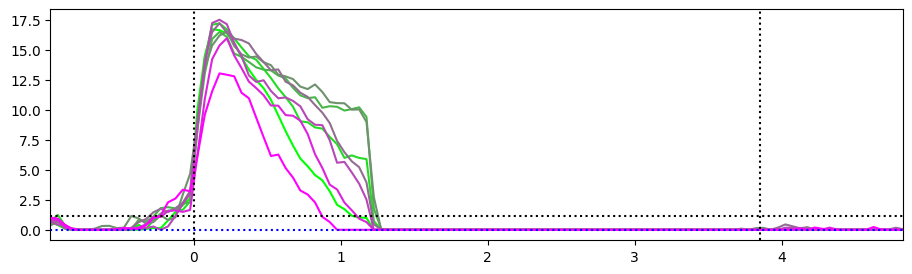

In [30]:
# example Other neuron that is task-responsive

ind = 0
inds = []
for i_session in res:
    for i_neuron in res[i_session]:
        if is_delay_responsive[ind] and is_taste_responsive[ind] and is_other[ind]:
            inds.append((i_session, i_neuron))
        ind += 1

i_session, i_neuron = inds[13]

fig, ax = plt.subplots(figsize=(11, 3));
psths = output_noise['all_psths_correct'][i_session][i_neuron]
for i_stim in range(psths.shape[0]):
    ax.plot(t, psths[i_stim, :], color=colors[i_stim]);
ax.axvline(0, color='k', linestyle=':');
ax.axvline(t[-1] - 1 + 0.025, color='k', linestyle=':');
ax.axhline(res[i_session][i_neuron]['fr_baseline'].mean(), color='k', linestyle=':');
ax.axhline(res[i_session][i_neuron]['fr_delay'].mean(), color='b', linestyle=':');
ax.set_xlim([t[0], t[-1]]);

# Figure 5 - Supplement 3 B
# plt.savefig('plots/model/example_taste_selective_other_2.pdf');

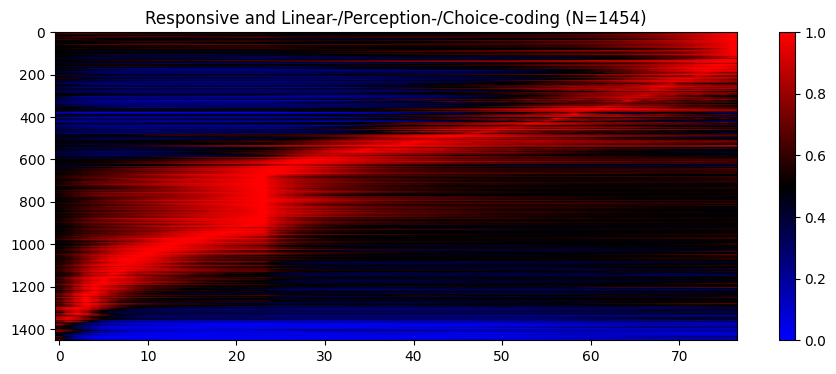

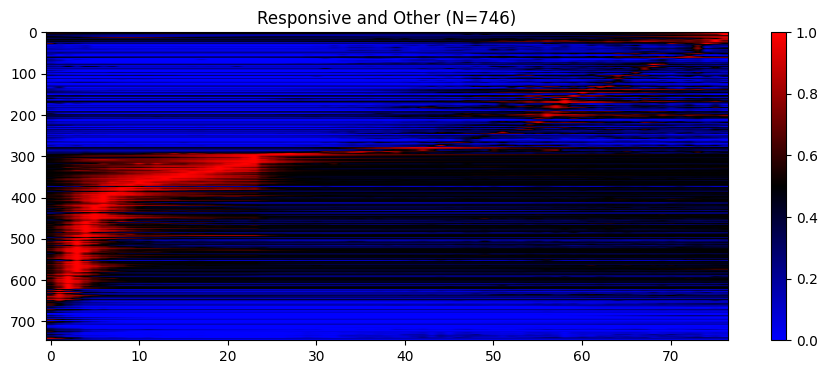

In [31]:
# responsive neuron patterns

ind = 0
all_psths, all_other_psths = [], []
for i_session in res:
    for i_neuron in res[i_session]:
        if is_taste_responsive[ind] or is_delay_responsive[ind]:            
            # relative to baseline
            psth = res[i_session][i_neuron]['psth'] - res[i_session][i_neuron]['fr_baseline'].mean() 
            # focus on inter-event interval
            psth = psth[20:-20]
            # normalize to max
            psth = psth / np.max(np.abs(psth))            
            if is_other[ind]:
                all_other_psths.append(psth)
            else:
                all_psths.append(psth)
        ind += 1
        
def sort_heatmap(heatmap):
    max_vals = np.array([heatmap[i, np.argmax(np.abs(heatmap[i, :]))] for i in range(heatmap.shape[0])])
    tmax = np.array([np.argmax(heatmap[i, :]) for i in range(heatmap.shape[0])])
    heatmap = heatmap[np.argsort(tmax)[::-1], :]
    return heatmap

cmap = LinearSegmentedColormap.from_list('my_cmap', [(0, [0, 0, 1]), (0.5, [0, 0, 0]), (1, [1, 0, 0])])

fig, ax = plt.subplots(figsize=(11, 4));
im = ax.imshow((sort_heatmap(np.array(all_psths)) + 1) / 2, cmap=cmap, aspect='auto');
ax.set_title('Responsive and Linear-/Perception-/Choice-coding (N={})'.format(len(all_psths)));
plt.colorbar(im, ax=ax);

# Figure 5 - Supplement 3 A
# plt.savefig('plots/model/responsive_coding_heatmap.pdf');

fig, ax = plt.subplots(figsize=(11, 4));
im = ax.imshow((sort_heatmap(np.array(all_other_psths)) + 1) / 2, cmap=cmap, aspect='auto');
ax.set_title('Responsive and Other (N={})'.format(len(all_other_psths)));
plt.colorbar(im, ax=ax);

# Figure 5 - Supplement 3 A
# plt.savefig('plots/model/responsive_other_heatmap.pdf');

# # for time scale
# fig, ax = plt.subplots(figsize=(11, 3));
# ax.axvline(0, color='k');
# ax.axvline(t[-1] - 1 + 0.025, color='k');
# # plt.savefig('plots/model/responsive_other_heatmap_scale.pdf');

### Ablation experiments

In [32]:
# define 'beginning' and 'end' windows

inds_beginning = np.where((t >= 0) & (t < 1.2))[0]
inds_beginning_downsample = np.where((np.array(t_downsample) >= 0) & (np.array(t_downsample) < 1.2))[0]
inds_end = np.where((t >= t_D - 1.2) & (t < t_D))[0]
inds_end_downsample = np.where((np.array(t_downsample) >= t_D - 1.2) & (np.array(t_downsample) < t_D))[0]

# create 'label_data' for ablation experiments

label_data = []
for i_session, session in enumerate(included_sessions):
    labels_over_time = output_noise['all_labels'][i_session]
    ind_lin = []
    ind_lin_con = []
    ind_lin_unc = []
    ind_lin_beginning = []
    ind_lin_end = []
    ind_perception = []
    ind_perception_con = []
    ind_perception_unc = []
    ind_perception_beginning = []
    ind_perception_end = []
    ind_choice = []
    ind_choice_con = []
    ind_choice_unc = []
    ind_choice_beginning = []
    ind_choice_end = []
    ind_other = []
    ind_other_con = []
    ind_other_unc = []
    n_neurons_constrained = all_models[session].observed_size
    n_neurons = all_models[session].network_size
    for i_neuron in range(n_neurons):
        label_over_time = [labels_over_time[i_t][i_neuron] for i_t in range(len(labels_over_time))]
        is_linear = 'Linear' in label_over_time
        is_perception = 'Step (Perception)' in label_over_time
        is_choice = 'Step (Choice)' in label_over_time
        is_constrained = i_neuron < n_neurons_constrained
        if is_linear: 
            ind_lin.append(i_neuron)
            if is_constrained:
                ind_lin_con.append(i_neuron)
            else:
                ind_lin_unc.append(i_neuron)
        if is_perception: 
            ind_perception.append(i_neuron)
            if is_constrained:
                ind_perception_con.append(i_neuron)
            else:
                ind_perception_unc.append(i_neuron)
        if is_choice: 
            ind_choice.append(i_neuron)
            if is_constrained:
                ind_choice_con.append(i_neuron)
            else:
                ind_choice_unc.append(i_neuron)
        if all([not is_linear, not is_perception, not is_choice]): 
            ind_other.append(i_neuron)
            if is_constrained:
                ind_other_con.append(i_neuron)
            else:
                ind_other_unc.append(i_neuron)
        label_over_time_beginning = [label_over_time[i] for i in inds_beginning_downsample]
        label_over_time_end = [label_over_time[i] for i in inds_end_downsample]
        if 'Linear' in label_over_time_beginning: ind_lin_beginning.append(i_neuron)
        if 'Linear' in label_over_time_end: ind_lin_end.append(i_neuron)
        if 'Step (Perception)' in label_over_time_beginning: ind_perception_beginning.append(i_neuron)
        if 'Step (Perception)' in label_over_time_end: ind_perception_end.append(i_neuron)
        if 'Step (Choice)' in label_over_time_beginning: ind_choice_beginning.append(i_neuron)
        if 'Step (Choice)' in label_over_time_end: ind_choice_end.append(i_neuron)
    label_data.append({
        'ind_lin': ind_lin.copy(),
        'ind_lin_con': ind_lin_con.copy(),
        'ind_lin_unc': ind_lin_unc.copy(),
        'ind_lin_beginning': ind_lin_beginning.copy(),
        'ind_lin_end': ind_lin_end.copy(),
        'ind_perception': ind_perception.copy(),
        'ind_perception_con': ind_perception_con.copy(),
        'ind_perception_unc': ind_perception_unc.copy(),
        'ind_perception_beginning': ind_perception_beginning.copy(),
        'ind_perception_end': ind_perception_end.copy(),
        'ind_choice': ind_choice.copy(),
        'ind_choice_con': ind_choice_con.copy(),
        'ind_choice_unc': ind_choice_unc.copy(),
        'ind_choice_beginning': ind_choice_beginning.copy(),
        'ind_choice_end': ind_choice_end.copy(),
        'ind_other': ind_other.copy(),
        'ind_other_con': ind_other_con.copy(),
        'ind_other_unc': ind_other_unc.copy(),
    })

In [33]:
## temporally-restricted silencing was not built into the original MyRNN class
## 'upgrade' models to new subclass

for key in all_models:
    all_models[key].__class__ = MyRNNWithDynamicSilencing

### Ablate 'Other'

In [34]:
try:
    with open('data/model/output_tailored_noise_ablate_other.pkl', 'rb') as file:
        output_noise_ablate_other = pickle.load(file)
        file.close()
except:
    output_noise_ablate_other = multi_model_simulation(
        list(all_models.values()), 
        inputs, 
        unique_stims, 
        t_decision_window,
        n_trials_per_stim=20, 
        sigma=list(inputs_sigma.values()),
        silenced='ind_other',
        label_data=label_data, 
        responses_over_time=False,
        fit_options=None,
        inds_L=None, 
        inds_R=None,
        responses_beginning_end=False,
        window_beginning=None,
        window_end=None)
    with open('data/model/output_tailored_noise_ablate_other.pkl', 'wb') as file:
        pickle.dump(output_noise_ablate_other, file)
        file.close()
        

In [35]:
try:
    with open('data/model/output_tailored_noise_ablate_other_con.pkl', 'rb') as file:
        output_noise_ablate_other_con = pickle.load(file)
        file.close()
except:
    output_noise_ablate_other_con = multi_model_simulation(
        list(all_models.values()), 
        inputs, 
        unique_stims, 
        t_decision_window,
        n_trials_per_stim=20, 
        sigma=list(inputs_sigma.values()),
        silenced='ind_other_con',
        label_data=label_data, 
        responses_over_time=False,
        fit_options=None,
        inds_L=None, 
        inds_R=None,
        responses_beginning_end=False,
        window_beginning=None,
        window_end=None)
    with open('data/model/output_tailored_noise_ablate_other_con.pkl', 'wb') as file:
        pickle.dump(output_noise_ablate_other_con, file)
        file.close()

In [36]:
try:
    with open('data/model/output_tailored_noise_ablate_other_unc.pkl', 'rb') as file:
        output_noise_ablate_other_unc = pickle.load(file)
        file.close()
except:
    output_noise_ablate_other_unc = multi_model_simulation(
        list(all_models.values()), 
        inputs, 
        unique_stims, 
        t_decision_window,
        n_trials_per_stim=20, 
        sigma=list(inputs_sigma.values()),
        silenced='ind_other_unc',
        label_data=label_data, 
        responses_over_time=False,
        fit_options=None,
        inds_L=None, 
        inds_R=None,
        responses_beginning_end=False,
        window_beginning=None,
        window_end=None)
    with open('data/model/output_tailored_noise_ablate_other_unc.pkl', 'wb') as file:
        pickle.dump(output_noise_ablate_other_unc, file)
        file.close()

### Ablate 'Linear'

In [37]:
try:
    with open('data/model/output_tailored_noise_ablate_linear.pkl', 'rb') as file:
        output_noise_ablate_linear = pickle.load(file)
        file.close()
except:
    output_noise_ablate_linear = multi_model_simulation(
        list(all_models.values()), 
        inputs, 
        unique_stims, 
        t_decision_window,
        n_trials_per_stim=20, 
        sigma=list(inputs_sigma.values()),
        silenced='ind_lin',
        label_data=label_data, 
        responses_over_time=False,
        fit_options=None,
        inds_L=None, 
        inds_R=None,
        responses_beginning_end=False,
        window_beginning=None,
        window_end=None)
    with open('data/model/output_tailored_noise_ablate_linear.pkl', 'wb') as file:
        pickle.dump(output_noise_ablate_linear, file)
        file.close()
        

In [38]:
try:
    with open('data/model/output_tailored_noise_ablate_linear_con.pkl', 'rb') as file:
        output_noise_ablate_linear_con = pickle.load(file)
        file.close()
except:
    output_noise_ablate_linear_con = multi_model_simulation(
        list(all_models.values()), 
        inputs, 
        unique_stims, 
        t_decision_window,
        n_trials_per_stim=20, 
        sigma=list(inputs_sigma.values()),
        silenced='ind_lin_con',
        label_data=label_data, 
        responses_over_time=False,
        fit_options=None,
        inds_L=None, 
        inds_R=None,
        responses_beginning_end=False,
        window_beginning=None,
        window_end=None)
    with open('data/model/output_tailored_noise_ablate_linear_con.pkl', 'wb') as file:
        pickle.dump(output_noise_ablate_linear_con, file)
        file.close()

In [39]:
try:
    with open('data/model/output_tailored_noise_ablate_linear_unc.pkl', 'rb') as file:
        output_noise_ablate_linear_unc = pickle.load(file)
        file.close()
except:
    output_noise_ablate_linear_unc = multi_model_simulation(
        list(all_models.values()), 
        inputs, 
        unique_stims, 
        t_decision_window,
        n_trials_per_stim=20, 
        sigma=list(inputs_sigma.values()),
        silenced='ind_lin_unc',
        label_data=label_data, 
        responses_over_time=False,
        fit_options=None,
        inds_L=None, 
        inds_R=None,
        responses_beginning_end=False,
        window_beginning=None,
        window_end=None)
    with open('data/model/output_tailored_noise_ablate_linear_unc.pkl', 'wb') as file:
        pickle.dump(output_noise_ablate_linear_unc, file)
        file.close()

In [40]:
try:
    with open('data/model/output_tailored_noise_ablate_linear_beginning.pkl', 'rb') as file:
        output_noise_ablate_linear_beginning = pickle.load(file)
        file.close()
except:
    output_noise_ablate_linear_beginning = multi_model_simulation_with_dynamic_silencing(
        list(all_models.values()), 
        inputs, 
        unique_stims, 
        t_decision_window,
        n_trials_per_stim=20, 
        sigma=list(inputs_sigma.values()),
        silenced='ind_lin_beginning',
        silence_time=inds_beginning,
        label_data=label_data, 
        responses_over_time=False,
        fit_options=None,
        inds_L=None, 
        inds_R=None,
        responses_beginning_end=False,
        window_beginning=None,
        window_end=None)
    with open('data/model/output_tailored_noise_ablate_linear_beginning.pkl', 'wb') as file:
        pickle.dump(output_noise_ablate_linear_beginning, file)
        file.close()

In [41]:
try:
    with open('data/model/output_tailored_noise_ablate_linear_end.pkl', 'rb') as file:
        output_noise_ablate_linear_end = pickle.load(file)
        file.close()
except:
    output_noise_ablate_linear_end = multi_model_simulation_with_dynamic_silencing(
        list(all_models.values()), 
        inputs, 
        unique_stims, 
        t_decision_window,
        n_trials_per_stim=20, 
        sigma=list(inputs_sigma.values()),
        silenced='ind_lin_end',
        silence_time=inds_end,
        label_data=label_data, 
        responses_over_time=False,
        fit_options=None,
        inds_L=None, 
        inds_R=None,
        responses_beginning_end=False,
        window_beginning=None,
        window_end=None)
    with open('data/model/output_tailored_noise_ablate_linear_end.pkl', 'wb') as file:
        pickle.dump(output_noise_ablate_linear_end, file)
        file.close()

### Ablate 'Step-Perception'

In [42]:
try:
    with open('data/model/output_tailored_noise_ablate_perception.pkl', 'rb') as file:
        output_noise_ablate_perception = pickle.load(file)
        file.close()
except:
    output_noise_ablate_perception = multi_model_simulation(
        list(all_models.values()), 
        inputs, 
        unique_stims, 
        t_decision_window,
        n_trials_per_stim=20, 
        sigma=list(inputs_sigma.values()),
        silenced='ind_perception',
        label_data=label_data, 
        responses_over_time=False,
        fit_options=None,
        inds_L=None, 
        inds_R=None,
        responses_beginning_end=False,
        window_beginning=None,
        window_end=None)
    with open('data/model/output_tailored_noise_ablate_perception.pkl', 'wb') as file:
        pickle.dump(output_noise_ablate_perception, file)
        file.close()

In [43]:
try:
    with open('data/model/output_tailored_noise_ablate_perception_con.pkl', 'rb') as file:
        output_noise_ablate_perception_con = pickle.load(file)
        file.close()
except:
    output_noise_ablate_perception_con = multi_model_simulation(
        list(all_models.values()), 
        inputs, 
        unique_stims, 
        t_decision_window,
        n_trials_per_stim=20, 
        sigma=list(inputs_sigma.values()),
        silenced='ind_perception_con',
        label_data=label_data, 
        responses_over_time=False,
        fit_options=None,
        inds_L=None, 
        inds_R=None,
        responses_beginning_end=False,
        window_beginning=None,
        window_end=None)
    with open('data/model/output_tailored_noise_ablate_perception_con.pkl', 'wb') as file:
        pickle.dump(output_noise_ablate_perception_con, file)
        file.close()

In [44]:
try:
    with open('data/model/output_tailored_noise_ablate_perception_unc.pkl', 'rb') as file:
        output_noise_ablate_perception_unc = pickle.load(file)
        file.close()
except:
    output_noise_ablate_perception_unc = multi_model_simulation(
        list(all_models.values()), 
        inputs, 
        unique_stims, 
        t_decision_window,
        n_trials_per_stim=20, 
        sigma=list(inputs_sigma.values()),
        silenced='ind_perception_unc',
        label_data=label_data, 
        responses_over_time=False,
        fit_options=None,
        inds_L=None, 
        inds_R=None,
        responses_beginning_end=False,
        window_beginning=None,
        window_end=None)
    with open('data/model/output_tailored_noise_ablate_perception_unc.pkl', 'wb') as file:
        pickle.dump(output_noise_ablate_perception_unc, file)
        file.close()

In [45]:
try:
    with open('data/model/output_tailored_noise_ablate_perception_beginning.pkl', 'rb') as file:
        output_noise_ablate_perception_beginning = pickle.load(file)
        file.close()
except:
    output_noise_ablate_perception_beginning = multi_model_simulation_with_dynamic_silencing(
        list(all_models.values()), 
        inputs, 
        unique_stims, 
        t_decision_window,
        n_trials_per_stim=20, 
        sigma=list(inputs_sigma.values()),
        silenced='ind_perception_beginning',
        silence_time=inds_beginning,
        label_data=label_data, 
        responses_over_time=False,
        fit_options=None,
        inds_L=None, 
        inds_R=None,
        responses_beginning_end=False,
        window_beginning=None,
        window_end=None)
    with open('data/model/output_tailored_noise_ablate_perception_beginning.pkl', 'wb') as file:
        pickle.dump(output_noise_ablate_perception_beginning, file)
        file.close()

In [46]:
try:
    with open('data/model/output_tailored_noise_ablate_perception_end.pkl', 'rb') as file:
        output_noise_ablate_perception_end = pickle.load(file)
        file.close()
except:
    output_noise_ablate_perception_end = multi_model_simulation_with_dynamic_silencing(
        list(all_models.values()), 
        inputs, 
        unique_stims, 
        t_decision_window,
        n_trials_per_stim=20, 
        sigma=list(inputs_sigma.values()),
        silenced='ind_perception_end',
        silence_time=inds_end,
        label_data=label_data, 
        responses_over_time=False,
        fit_options=None,
        inds_L=None, 
        inds_R=None,
        responses_beginning_end=False,
        window_beginning=None,
        window_end=None)
    with open('data/model/output_tailored_noise_ablate_perception_end.pkl', 'wb') as file:
        pickle.dump(output_noise_ablate_perception_end, file)
        file.close()

### Ablate 'Step-Choice'

In [47]:
try:
    with open('data/model/output_tailored_noise_ablate_choice.pkl', 'rb') as file:
        output_noise_ablate_choice = pickle.load(file)
        file.close()
except:
    output_noise_ablate_choice = multi_model_simulation(
        list(all_models.values()), 
        inputs, 
        unique_stims, 
        t_decision_window,
        n_trials_per_stim=20, 
        sigma=list(inputs_sigma.values()),
        silenced='ind_choice',
        label_data=label_data, 
        responses_over_time=False,
        fit_options=None,
        inds_L=None, 
        inds_R=None,
        responses_beginning_end=False,
        window_beginning=None,
        window_end=None)
    with open('data/model/output_tailored_noise_ablate_choice.pkl', 'wb') as file:
        pickle.dump(output_noise_ablate_choice, file)
        file.close()  

In [48]:
try:
    with open('data/model/output_tailored_noise_ablate_choice_con.pkl', 'rb') as file:
        output_noise_ablate_choice_con = pickle.load(file)
        file.close()
except:
    output_noise_ablate_choice_con = multi_model_simulation(
        list(all_models.values()), 
        inputs, 
        unique_stims, 
        t_decision_window,
        n_trials_per_stim=20, 
        sigma=list(inputs_sigma.values()),
        silenced='ind_choice_con',
        label_data=label_data, 
        responses_over_time=False,
        fit_options=None,
        inds_L=None, 
        inds_R=None,
        responses_beginning_end=False,
        window_beginning=None,
        window_end=None)
    with open('data/model/output_tailored_noise_ablate_choice_con.pkl', 'wb') as file:
        pickle.dump(output_noise_ablate_choice_con, file)
        file.close()

In [49]:
try:
    with open('data/model/output_tailored_noise_ablate_choice_unc.pkl', 'rb') as file:
        output_noise_ablate_choice_unc = pickle.load(file)
        file.close()
except:
    output_noise_ablate_choice_unc = multi_model_simulation(
        list(all_models.values()), 
        inputs, 
        unique_stims, 
        t_decision_window,
        n_trials_per_stim=20, 
        sigma=list(inputs_sigma.values()),
        silenced='ind_choice_unc',
        label_data=label_data, 
        responses_over_time=False,
        fit_options=None,
        inds_L=None, 
        inds_R=None,
        responses_beginning_end=False,
        window_beginning=None,
        window_end=None)
    with open('data/model/output_tailored_noise_ablate_choice_unc.pkl', 'wb') as file:
        pickle.dump(output_noise_ablate_choice_unc, file)
        file.close()

In [50]:
try:
    with open('data/model/output_tailored_noise_ablate_choice_beginning.pkl', 'rb') as file:
        output_noise_ablate_choice_beginning = pickle.load(file)
        file.close()
except:
    output_noise_ablate_choice_beginning = multi_model_simulation_with_dynamic_silencing(
        list(all_models.values()), 
        inputs, 
        unique_stims, 
        t_decision_window,
        n_trials_per_stim=20, 
        sigma=list(inputs_sigma.values()),
        silenced='ind_choice_beginning',
        silence_time=inds_beginning,
        label_data=label_data, 
        responses_over_time=False,
        fit_options=None,
        inds_L=None, 
        inds_R=None,
        responses_beginning_end=False,
        window_beginning=None,
        window_end=None)
    with open('data/model/output_tailored_noise_ablate_choice_beginning.pkl', 'wb') as file:
        pickle.dump(output_noise_ablate_choice_beginning, file)
        file.close()

In [51]:
try:
    with open('data/model/output_tailored_noise_ablate_choice_end.pkl', 'rb') as file:
        output_noise_ablate_choice_end = pickle.load(file)
        file.close()
except:
    output_noise_ablate_choice_end = multi_model_simulation_with_dynamic_silencing(
        list(all_models.values()), 
        inputs, 
        unique_stims, 
        t_decision_window,
        n_trials_per_stim=20, 
        sigma=list(inputs_sigma.values()),
        silenced='ind_choice_end',
        silence_time=inds_end,
        label_data=label_data, 
        responses_over_time=False,
        fit_options=None,
        inds_L=None, 
        inds_R=None,
        responses_beginning_end=False,
        window_beginning=None,
        window_end=None)
    with open('data/model/output_tailored_noise_ablate_choice_end.pkl', 'wb') as file:
        pickle.dump(output_noise_ablate_choice_end, file)
        file.close()

### Stats on accuracies

In [52]:
# 1-way repeated-measures ANOVA

data = [
    (output_noise['all_accuracies'], 'control'),
    (output_noise_ablate_linear['all_accuracies'], 'linear'),
    (output_noise_ablate_perception['all_accuracies'], 'perception'),
    (output_noise_ablate_choice['all_accuracies'], 'choice'),
    (output_noise_ablate_other['all_accuracies'], 'other')
]

n_subjects = n_sessions
n_conditions = len(data)
subject = [i for i in range(n_subjects)] * n_conditions
condition, measurement = [], []
for i in range(n_conditions):
    condition += ['{}'.format(i)] * n_subjects
    measurement += data[i][0]
df = pd.DataFrame({
    'subject': subject,
    'condition': condition,
    'measurement': measurement
})

# Perform repeated measures ANOVA
rm_anova = AnovaRM(df, 'measurement', 'subject', within=['condition'])
results = rm_anova.fit()

# Print the results
display(results.anova_table)

# post-hoc tests
correction = scipy.special.comb(n_conditions, 2) # bonferroni correction for number of paired tests

print('\nPost-hoc tests (Bonferroni-adjusted p-values):\n')
for i in range(n_conditions - 1):
    for j in range(i + 1, n_conditions):
        x1, label1 = data[i]
        x2, label2 = data[j]
        print('    {} vs. {}: p = {:.4e}'.format(label1, label2, correction * scipy.stats.ttest_rel(x1, x2)[1]))

,F Value,Num DF,Den DF,Pr > F
condition,116.51567,4.0,88.0,2.633677e-34



Post-hoc tests (Bonferroni-adjusted p-values):

    control vs. linear: p = 6.5079e-16
    control vs. perception: p = 9.2251e-11
    control vs. choice: p = 6.2675e-13
    control vs. other: p = 1.9664e-01
    linear vs. perception: p = 2.0646e+00
    linear vs. choice: p = 9.8523e+00
    linear vs. other: p = 1.9956e-10
    perception vs. choice: p = 2.5047e+00
    perception vs. other: p = 8.6255e-08
    choice vs. other: p = 1.2777e-08


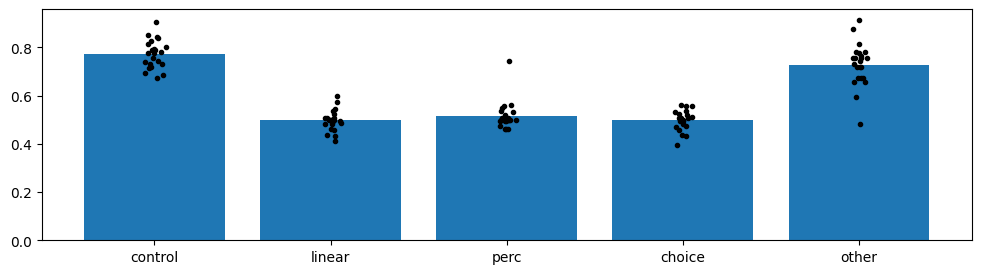

In [53]:
# plot accuracies

data = [
    ([_ for _ in output_noise['all_accuracies']], 'control'),
    ([_ for _ in output_noise_ablate_linear['all_accuracies']], 'linear'),
    ([_ for _ in output_noise_ablate_perception['all_accuracies']], 'perc'),
    ([_ for _ in output_noise_ablate_choice['all_accuracies']], 'choice'),
    ([_ for _ in output_noise_ablate_other['all_accuracies']], 'other'),
]

fig, ax = plt.subplots(figsize=(12, 3));
ax.bar([data[i][1] for i in range(len(data))], [np.mean(data[i][0]) for i in range(len(data))]);
for i in range(len(data)):
    ax.plot(i + 0.025 * np.random.normal(size=len(data[i][0])), data[i][0], '.k');
    
# Figure 7C    
# plt.savefig('plots/model/accuracies.pdf');

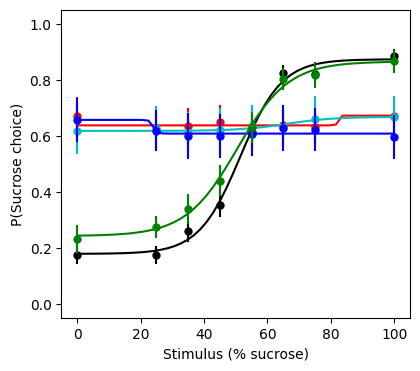

In [54]:
# plot psychometrics

def plot_psychometric(all_p_left, color, style):
    p_left_mat = np.empty([0, n_stims])
    for p_left in all_p_left:
        p_left_mat = np.vstack([p_left_mat, p_left])
    ave_p_left = p_left_mat.mean(axis=0)
    std_p_left = p_left_mat.std(axis=0) / np.sqrt(p_left_mat.shape[0])
    psycho_res = fit_psychometric(unique_stims, ave_p_left)
    ax.plot(psycho_res['x'], psycho_res['y'], color=color, linestyle=style);
    for i_stim, stim in enumerate(unique_stims):
        ax.plot([stim, stim], [ave_p_left[i_stim] - std_p_left[i_stim], ave_p_left[i_stim] + std_p_left[i_stim]], 
                color=color, linestyle=style);
        ax.plot(stim, ave_p_left[i_stim], '.', color=color, markersize=10);
        
fig, ax = plt.subplots(figsize=(4.5, 4));
plot_psychometric(output_noise['all_p_left'], 'k', '-')
plot_psychometric(output_noise_ablate_linear['all_p_left'], 'r', '-')
plot_psychometric(output_noise_ablate_perception['all_p_left'], 'c', '-')
plot_psychometric(output_noise_ablate_choice['all_p_left'], 'b', '-')
plot_psychometric(output_noise_ablate_other['all_p_left'], 'g', '-')
ax.set_ylim([-0.05, 1.05]);
ax.set_xlabel('Stimulus (% sucrose)');
ax.set_ylabel('P(Sucrose choice)');

# Figure 7F
# plt.savefig('plots/model/ablation_psychometrics.pdf');

In [55]:
# stats on psychometrics (extra-sum-of-squares F tests)

p_left_control = np.array(output_noise['all_p_left']).mean(axis=0)
p_left_other = np.array(output_noise_ablate_other['all_p_left']).mean(axis=0)
p_left_linear = np.array(output_noise_ablate_linear['all_p_left']).mean(axis=0)
p_left_perception = np.array(output_noise_ablate_perception['all_p_left']).mean(axis=0)
p_left_choice = np.array(output_noise_ablate_choice['all_p_left']).mean(axis=0)

correction = scipy.special.comb(n_conditions, 2)

# control vs. ablated other
Y = [p_left_control, p_left_other]
res = psychometric_comparison_test(unique_stims, Y)
print('Control vs. ablated other, F = {:.4f}, p = {:.4f}, corrected p = {:.4f}'.format(
    res['F'], res['p'], correction * res['p']
))

# control vs. ablated linear
Y = [p_left_control, p_left_linear]
res = psychometric_comparison_test(unique_stims, Y)
print('Control vs. ablated linear, F = {:.4f}, p = {:.4f}, corrected p = {:.4f}'.format(
    res['F'], res['p'], correction * res['p']
))

# control vs. ablated perception
Y = [p_left_control, p_left_perception]
res = psychometric_comparison_test(unique_stims, Y)
print('Control vs. ablated perception, F = {:.4f}, p = {:.4f}, corrected p = {:.4f}'.format(
    res['F'], res['p'], correction * res['p']
))

# control vs. ablated choice
Y = [p_left_control, p_left_choice]
res = psychometric_comparison_test(unique_stims, Y)
print('Control vs. ablated choice, F = {:.4f}, p = {:.4f}, corrected p = {:.4f}'.format(
    res['F'], res['p'], correction * res['p']
))

Control vs. ablated other, F = 5.1703, p = 0.0235, corrected p = 0.2351
Control vs. ablated linear, F = 139.6094, p = 0.0000, corrected p = 0.0000
Control vs. ablated perception, F = 183.1619, p = 0.0000, corrected p = 0.0000
Control vs. ablated choice, F = 174.4806, p = 0.0000, corrected p = 0.0000


In [56]:
'''
2-way within-subjects ANOVA on behavioral performance
factor 1: coding type (4 levels)
factor 2: constrained vs unconstrained (2 levels)

There is only 1 control group b/c factor 2 does not apply when ablating nothing
Remove it as a level of factor 1 to avoid an empty cell in the 2-way ANOVA
To compare groups to control, separately use Dunnett's test on all 9 groups
'''

n_subjects = n_sessions
coding_type = ['linear', 'perception', 'choice', 'other']
constraint = ['constrained', 'unconstrained']
col_subject = [i for i in included_sessions] * (len(coding_type) * len(constraint))
col_coding_type, col_constraint, col_measurement = [], [], []

for coding_type_i in coding_type:
    for constraint_i in constraint:
        col_coding_type += [coding_type_i] * n_subjects
        col_constraint += [constraint_i] * n_subjects
        if coding_type_i == 'linear':
            if constraint_i == 'constrained':
                col_measurement += list(output_noise_ablate_linear_con['all_accuracies'])
            else:
                col_measurement += list(output_noise_ablate_linear_unc['all_accuracies'])
        elif coding_type_i == 'perception':
            if constraint_i == 'constrained':
                col_measurement += list(output_noise_ablate_perception_con['all_accuracies'])
            else:
                col_measurement += list(output_noise_ablate_perception_unc['all_accuracies'])
        if coding_type_i == 'choice':
            if constraint_i == 'constrained':
                col_measurement += list(output_noise_ablate_choice_con['all_accuracies'])
            else:
                col_measurement += list(output_noise_ablate_choice_unc['all_accuracies'])
        if coding_type_i == 'other':
            if constraint_i == 'constrained':
                col_measurement += list(output_noise_ablate_other_con['all_accuracies'])
            else:
                col_measurement += list(output_noise_ablate_other_unc['all_accuracies'])

df = pd.DataFrame({
    'id': col_subject,
    'iv1': col_coding_type,
    'iv2': col_constraint,
    'dv': col_measurement
})

# Perform repeated measures ANOVA
print('2-way ANOVA')
print('Factor 1: coding_type')
print('Factor 2: constraint\n')
res_anova = rmAnova2Way(df)

2-way ANOVA
Factor 1: coding_type
Factor 2: constraint

SSE_1b = 1.1344, SSE_1w = 0.3707, F_1 = 67.3241, p_1 = 0.0000
SSE_2b = 0.3397, SSE_2w = 0.3647, F_2 = 20.4950, p_2 = 0.0002
SSE_12b = 0.2887, SSE_12w = 0.3703, F_12 = 17.1493, p_12 = 0.0000


In [57]:
# post-hoc tests

all_groups = [
    ('linear', 'constrained'),
    ('linear', 'unconstrained'),
    ('perception', 'constrained'),
    ('perception', 'unconstrained'),
    ('choice', 'constrained'),
    ('choice', 'unconstrained'),
    ('other', 'constrained'),
    ('other', 'unconstrained')
]
n_groups = len(all_groups)
correction = scipy.special.comb(n_groups, 2) # bonferroni correction for number of paired tests

p_mat = np.full([n_groups, n_groups], np.nan)
print('\nPost-hoc tests (Bonferroni-adjusted p-values):\n')
for i in range(n_groups - 1):
    for j in range(i + 1, n_groups):
        coding_type_i, constraint_i = all_groups[i]
        x_i = np.array([_ for _ in df[(df['iv1'] == coding_type_i) & (df['iv2'] == constraint_i)]['dv']])
        label_i = coding_type_i + '_' + constraint_i
        coding_type_j, constraint_j = all_groups[j]
        x_j = np.array([_ for _ in df[(df['iv1'] == coding_type_j) & (df['iv2'] == constraint_j)]['dv']])
        label_j = coding_type_j + '_' + constraint_j
        p_adj = correction * scipy.stats.ttest_rel(x_i, x_j)[1]
        print('    {} vs. {}: p = {:.4e}'.format(label_i, label_j, p_adj))
        p_mat[i, j] = (p_adj < 0.01).astype(float)
        
print('')
print(p_mat)


Post-hoc tests (Bonferroni-adjusted p-values):

    linear_constrained vs. linear_unconstrained: p = 3.3389e-01
    linear_constrained vs. perception_constrained: p = 1.2719e-01
    linear_constrained vs. perception_unconstrained: p = 7.9719e-02
    linear_constrained vs. choice_constrained: p = 2.7966e-01
    linear_constrained vs. choice_unconstrained: p = 3.1071e-02
    linear_constrained vs. other_constrained: p = 1.4681e-03
    linear_constrained vs. other_unconstrained: p = 2.1981e-06
    linear_unconstrained vs. perception_constrained: p = 1.4088e-02
    linear_unconstrained vs. perception_unconstrained: p = 2.6195e+01
    linear_unconstrained vs. choice_constrained: p = 4.4025e-03
    linear_unconstrained vs. choice_unconstrained: p = 4.2913e+00
    linear_unconstrained vs. other_constrained: p = 3.6369e-08
    linear_unconstrained vs. other_unconstrained: p = 2.0099e-12
    perception_constrained vs. perception_unconstrained: p = 4.0861e-03
    perception_constrained vs. choi

In [58]:
## dunnett test

data = [
    ([_ for _ in output_noise_ablate_linear_con['all_accuracies']], 'linear_con'),
    ([_ for _ in output_noise_ablate_linear_unc['all_accuracies']], 'linear_unc'),
    ([_ for _ in output_noise_ablate_perception_con['all_accuracies']], 'perc_con'),
    ([_ for _ in output_noise_ablate_perception_unc['all_accuracies']], 'perc_unc'),
    ([_ for _ in output_noise_ablate_choice_con['all_accuracies']], 'choice_con'),
    ([_ for _ in output_noise_ablate_choice_unc['all_accuracies']], 'choice_unc'),
    ([_ for _ in output_noise_ablate_other_con['all_accuracies']], 'other_con'),
    ([_ for _ in output_noise_ablate_other_unc['all_accuracies']], 'other_unc')
]
samples = [np.array(data_[0]) for data_ in data]
labels = [data_[1] for data_ in data]
control = np.array([_ for _ in output_noise['all_accuracies']])
res = scipy.stats.dunnett(*samples, control=control)
print('Dunnett test:\n')
for i in range(len(data)):
    print('Control vs {}: p = {:.4e}'.format(labels[i], res.pvalue[i]))

Dunnett test:

Control vs linear_con: p = 2.1404e-08
Control vs linear_unc: p = 4.4409e-16
Control vs perc_con: p = 1.3653e-04
Control vs perc_unc: p = 2.2204e-16
Control vs choice_con: p = 1.5606e-03
Control vs choice_unc: p = 0.0000e+00
Control vs other_con: p = 6.4869e-01
Control vs other_unc: p = 1.0000e+00


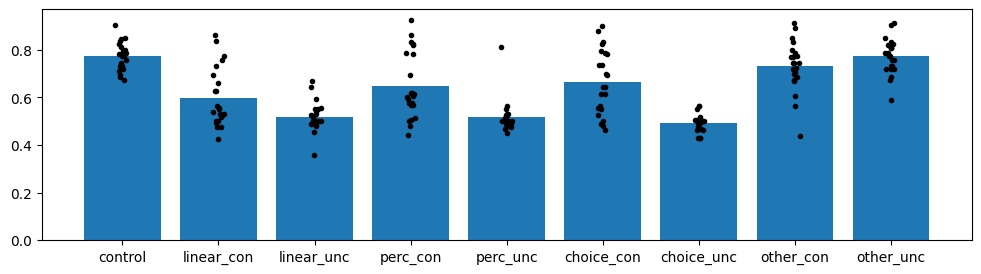

In [59]:
# plot accuracies

data = [
    ([_ for _ in output_noise['all_accuracies']], 'control'),
    ([_ for _ in output_noise_ablate_linear_con['all_accuracies']], 'linear_con'),
    ([_ for _ in output_noise_ablate_linear_unc['all_accuracies']], 'linear_unc'),
    ([_ for _ in output_noise_ablate_perception_con['all_accuracies']], 'perc_con'),
    ([_ for _ in output_noise_ablate_perception_unc['all_accuracies']], 'perc_unc'),
    ([_ for _ in output_noise_ablate_choice_con['all_accuracies']], 'choice_con'),
    ([_ for _ in output_noise_ablate_choice_unc['all_accuracies']], 'choice_unc'),
    ([_ for _ in output_noise_ablate_other_con['all_accuracies']], 'other_con'),
    ([_ for _ in output_noise_ablate_other_unc['all_accuracies']], 'other_unc')
]

fig, ax = plt.subplots(figsize=(12, 3));
ax.bar([data[i][1] for i in range(len(data))], [np.mean(data[i][0]) for i in range(len(data))]);
for i in range(len(data)):
    ax.plot(i + 0.025 * np.random.normal(size=len(data[i][0])), data[i][0], '.k');
    
# Figure 7 - Supplement 1 C    
# plt.savefig('plots/model/accuracies_con_vs_unc.pdf');

In [60]:
'''
Repeat above for beginning vs end
'''

n_subjects = n_sessions
coding_type = ['linear', 'perception', 'choice']
window = ['beginning', 'end']
col_subject = [i for i in included_sessions] * (len(coding_type) * len(window))
col_coding_type, col_window, col_measurement = [], [], []

for coding_type_i in coding_type:
    for window_i in window:
        col_coding_type += [coding_type_i] * n_subjects
        col_window += [window_i] * n_subjects
        if coding_type_i == 'linear':
            if window_i == 'beginning':
                col_measurement += list(output_noise_ablate_linear_beginning['all_accuracies'])
            else:
                col_measurement += list(output_noise_ablate_linear_end['all_accuracies'])
        elif coding_type_i == 'perception':
            if window_i == 'beginning':
                col_measurement += list(output_noise_ablate_perception_beginning['all_accuracies'])
            else:
                col_measurement += list(output_noise_ablate_perception_end['all_accuracies'])
        if coding_type_i == 'choice':
            if window_i == 'beginning':
                col_measurement += list(output_noise_ablate_choice_beginning['all_accuracies'])
            else:
                col_measurement += list(output_noise_ablate_choice_end['all_accuracies'])

df = pd.DataFrame({
    'id': col_subject,
    'iv1': col_coding_type,
    'iv2': col_window,
    'dv': col_measurement
})

# Perform repeated measures ANOVA
print('2-way ANOVA')
print('Factor 1: coding_type')
print('Factor 2: window\n')
res_anova = rmAnova2Way(df)

2-way ANOVA
Factor 1: coding_type
Factor 2: window

SSE_1b = 0.0424, SSE_1w = 0.2300, F_1 = 4.0596, p_1 = 0.0241
SSE_2b = 0.2298, SSE_2w = 0.1336, F_2 = 37.8501, p_2 = 0.0000
SSE_12b = 0.4760, SSE_12w = 0.1651, F_12 = 63.4457, p_12 = 0.0000


In [61]:
# post-hoc tests

all_groups = [
    ('linear', 'beginning'),
    ('linear', 'end'),
    ('perception', 'beginning'),
    ('perception', 'end'),
    ('choice', 'beginning'),
    ('choice', 'end')
]
n_groups = len(all_groups)
correction = scipy.special.comb(n_groups, 2) # bonferroni correction for number of paired tests

p_mat = np.full([n_groups, n_groups], np.nan)
print('\nPost-hoc tests (Bonferroni-adjusted p-values):\n')
for i in range(n_groups - 1):
    for j in range(i + 1, n_groups):
        coding_type_i, window_i = all_groups[i]
        x_i = np.array([_ for _ in df[(df['iv1'] == coding_type_i) & (df['iv2'] == window_i)]['dv']])
        label_i = coding_type_i + '_' + window_i
        coding_type_j, window_j = all_groups[j]
        x_j = np.array([_ for _ in df[(df['iv1'] == coding_type_j) & (df['iv2'] == window_j)]['dv']])
        label_j = coding_type_j + '_' + window_j
        p_adj = correction * scipy.stats.ttest_rel(x_i, x_j)[1]
        print('    {} vs. {}: p = {:.4e}'.format(label_i, label_j, p_adj))
        p_mat[i, j] = (p_adj < 0.01).astype(float)
        
print('')
print(p_mat)


Post-hoc tests (Bonferroni-adjusted p-values):

    linear_beginning vs. linear_end: p = 5.0607e-02
    linear_beginning vs. perception_beginning: p = 8.1664e-03
    linear_beginning vs. perception_end: p = 2.8017e+00
    linear_beginning vs. choice_beginning: p = 3.3254e-06
    linear_beginning vs. choice_end: p = 1.4502e-04
    linear_end vs. perception_beginning: p = 9.9286e+00
    linear_end vs. perception_end: p = 3.5515e-03
    linear_end vs. choice_beginning: p = 1.5265e+00
    linear_end vs. choice_end: p = 1.2361e-06
    perception_beginning vs. perception_end: p = 5.5786e-03
    perception_beginning vs. choice_beginning: p = 1.2243e-02
    perception_beginning vs. choice_end: p = 2.9894e-07
    perception_end vs. choice_beginning: p = 6.3938e-05
    perception_end vs. choice_end: p = 5.8706e-02
    choice_beginning vs. choice_end: p = 5.6844e-10

[[nan  0.  1.  0.  1.  1.]
 [nan nan  0.  1.  0.  1.]
 [nan nan nan  1.  0.  1.]
 [nan nan nan nan  1.  0.]
 [nan nan nan nan nan 

In [62]:
## dunnett test

data = [
    ([_ for _ in output_noise_ablate_linear_beginning['all_accuracies']], 'linear_beg'),
    ([_ for _ in output_noise_ablate_linear_end['all_accuracies']], 'linear_end'),
    ([_ for _ in output_noise_ablate_perception_beginning['all_accuracies']], 'perc_beg'),
    ([_ for _ in output_noise_ablate_perception_end['all_accuracies']], 'perc_end'),
    ([_ for _ in output_noise_ablate_choice_beginning['all_accuracies']], 'choice_beg'),
    ([_ for _ in output_noise_ablate_choice_end['all_accuracies']], 'choice_end')
]
samples = [np.array(data_[0]) for data_ in data]
labels = [data_[1] for data_ in data]
control = np.array([_ for _ in output_noise['all_accuracies']])
res = scipy.stats.dunnett(*samples, control=control)
print('Dunnett test:\n')
for i in range(len(data)):
    print('Control vs {}: p = {:.4e}'.format(labels[i], res.pvalue[i]))

Dunnett test:

Control vs linear_beg: p = 5.0495e-04
Control vs linear_end: p = 4.3254e-01
Control vs perc_beg: p = 2.4183e-01
Control vs perc_end: p = 2.6199e-06
Control vs choice_beg: p = 9.9992e-01
Control vs choice_end: p = 4.8184e-14


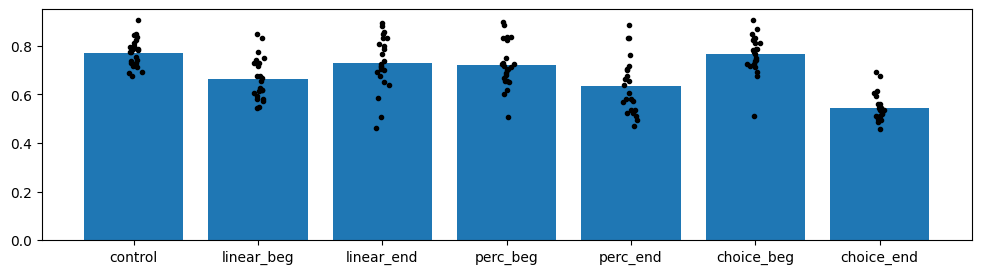

In [63]:
data = [
    ([_ for _ in output_noise['all_accuracies']], 'control'),
    ([_ for _ in output_noise_ablate_linear_beginning['all_accuracies']], 'linear_beg'),
    ([_ for _ in output_noise_ablate_linear_end['all_accuracies']], 'linear_end'),
    ([_ for _ in output_noise_ablate_perception_beginning['all_accuracies']], 'perc_beg'),
    ([_ for _ in output_noise_ablate_perception_end['all_accuracies']], 'perc_end'),
    ([_ for _ in output_noise_ablate_choice_beginning['all_accuracies']], 'choice_beg'),
    ([_ for _ in output_noise_ablate_choice_end['all_accuracies']], 'choice_end')
]

fig, ax = plt.subplots(figsize=(12, 3));
ax.bar([data[i][1] for i in range(len(data))], [np.mean(data[i][0]) for i in range(len(data))]);
for i in range(len(data)):
    ax.plot(i + 0.025 * np.random.normal(size=len(data[i][0])), data[i][0], '.k');
    
# Figure 7 - Supplement 2 C
# plt.savefig('plots/review/model/accuracies_beg_vs_end.pdf');

In [64]:
# numbers of each

for i_session, session_key in enumerate(included_sessions):
    print('Session {}'.format(session_key))
    n_con = all_models[session_key].observed_size
    n_tot = all_models[session_key].network_size
    for coding_type in ['Linear', 'Step (Perception)', 'Step (Choice)', 'Other']:
        n_c, n_u = 0, 0
        for i_neuron in range(n_tot):
            label_seq = [
                output_noise['all_labels'][i_session][i_t][i_neuron] 
                for i_t in range(len(output_noise['all_labels'][i_session]))
            ]
            if coding_type != 'Other':
                if coding_type in label_seq:
                    if i_neuron < n_con:
                        n_c += 1
                    else:
                        n_u += 1
            else:
                if all([label == 'Other' for label in label_seq]):
                    if i_neuron < n_con:
                        n_c += 1
                    else:
                        n_u += 1
        print('    {}'.format(coding_type))
        print('        Constrained:   {}'.format(n_c))
        print('        Unconstrained: {}'.format(n_u))

print('---- TOTALS ----')
print('Number of constrained linear: {}'
      .format(sum([len(label_data[i]['ind_lin_con']) for i in range(len(label_data))])))
print('Number of unconstrained linear: {}'
      .format(sum([len(label_data[i]['ind_lin_unc']) for i in range(len(label_data))])))
print('Number of constrained perception: {}'
      .format(sum([len(label_data[i]['ind_perception_con']) for i in range(len(label_data))])))
print('Number of unconstrained perception: {}'
      .format(sum([len(label_data[i]['ind_perception_unc']) for i in range(len(label_data))])))
print('Number of constrained choice: {}'
      .format(sum([len(label_data[i]['ind_choice_con']) for i in range(len(label_data))])))
print('Number of unconstrained choice: {}'
      .format(sum([len(label_data[i]['ind_choice_unc']) for i in range(len(label_data))])))
print('Number of constrained other: {}'
      .format(sum([len(label_data[i]['ind_other_con']) for i in range(len(label_data))])))
print('Number of unconstrained other: {}'
      .format(sum([len(label_data[i]['ind_other_unc']) for i in range(len(label_data))])))

Session 0
    Linear
        Constrained:   5
        Unconstrained: 17
    Step (Perception)
        Constrained:   6
        Unconstrained: 32
    Step (Choice)
        Constrained:   6
        Unconstrained: 42
    Other
        Constrained:   0
        Unconstrained: 0
Session 1
    Linear
        Constrained:   8
        Unconstrained: 9
    Step (Perception)
        Constrained:   5
        Unconstrained: 18
    Step (Choice)
        Constrained:   9
        Unconstrained: 14
    Other
        Constrained:   0
        Unconstrained: 0
Session 2
    Linear
        Constrained:   6
        Unconstrained: 13
    Step (Perception)
        Constrained:   4
        Unconstrained: 29
    Step (Choice)
        Constrained:   2
        Unconstrained: 36
    Other
        Constrained:   0
        Unconstrained: 0
Session 3
    Linear
        Constrained:   9
        Unconstrained: 37
    Step (Perception)
        Constrained:   8
        Unconstrained: 46
    Step (Choice)
        Constrai

### --- dPCA ---

#### Original (complete ablation of each coding category)

In [65]:
filter_models = True # filter out models that do not have at least 2 trials per choice across all ablation conditions
                     # this is done to improve the linear prediction of missing trial types

outputs = {
    'baseline': output_noise,
    'other': output_noise_ablate_other,
    'linear': output_noise_ablate_linear,
    'perception': output_noise_ablate_perception,
    'choice': output_noise_ablate_choice
}
conditions = outputs.keys()

# filtering criteria
good_model_inds = []
for i_model in range(len(included_sessions)):
    is_good = True
    if filter_models:
        for condition in conditions:
            y_choice = outputs[condition]['y_lefts'][i_model]
            if (y_choice.sum() <= 1) or (y_choice.sum() >= len(y_choice) - 1):
                is_good = False
                break
    if is_good:
        good_model_inds.append(i_model)
if filter_models:
    print('{}/{} models passed.'.format(len(good_model_inds), len(included_sessions)))
else:
    print('All models included.')
file_name = 'filtered' if filter_models else 'all' 

14/23 models passed.


In [66]:
try:
    
    with open('data/model/dPCA_{}_sessions_results.pkl'.format(file_name), 'rb') as file:
        dPCA_results = pickle.load(file)
        file.close()
        
except:
    
    dPCA_results = {}

    for condition in conditions:

        # get maximum number of trials for any parameter combination across sessions
        max_num_trials = 0
        n_neurons_pseudo = 0
        flagged_models = []
        for i_model in good_model_inds:
            X = outputs[condition]['Xs'][i_model]
            y_stim = outputs[condition]['y_stims'][i_model]
            y_choice = outputs[condition]['y_lefts'][i_model]
            n_neurons_pseudo += X.shape[1]
            for stim in unique_stims:
                for choice in [0, 1]:
                    n = ((y_stim == stim) & (y_choice == choice)).sum()
                    if (n == 0) and (i_model not in flagged_models):
                        flagged_models.append(i_model)
                    max_num_trials = max(max_num_trials, n)

        # assemble pseudo-population trial-by-trial tensor
        # X_pseudo: (trials x neurons x stimuli x decisions x time)
        X_pseudo = np.full([max_num_trials, n_neurons_pseudo, len(unique_stims), 2, len(t)], np.nan)
        n_neurons_cumul = 0
        for i_model in good_model_inds:
            X = outputs[condition]['Xs'][i_model]
            y_stim = outputs[condition]['y_stims'][i_model]
            y_choice = outputs[condition]['y_lefts'][i_model]
            n_neurons = X.shape[1]
            ###----------------------------------------------------------------------------------------------------
            if i_model in flagged_models:
                ### issue: some data are missing for this session
                ### workaround: fit a simple linear model to existing data and use it to predict the missing parts
                predictors = np.vstack([
                    y_stim.reshape([1, -1]),
                    y_choice.reshape([1, -1]),
                    (y_stim * y_choice).reshape([1, -1]),
                    np.ones([1, X.shape[0]])
                ])
                betas = [[scipy.linalg.pinv(predictors @ predictors.T) @ predictors @ X[:, i_n, i_t].reshape([-1, 1])
                          for i_t in range(len(t))] for i_n in range(n_neurons)]
            ###-----------------------------------------------------------------------------------------------------
            for i_stim, stim in enumerate(unique_stims):
                for i_choice, choice in enumerate([0, 1]):
                    trial_mask = (y_stim == stim) & (y_choice == choice)
                    n_trials = trial_mask.sum()
                    if n_trials == 0:
                        ### use the linear model's prediction ------------------------------------------------------
                        for i_n in range(n_neurons):
                            for i_t in range(len(t)):
                                r = max((betas[i_n][i_t].flatten() * np.array([stim, choice, stim * choice, 1])).sum(), 0)
                                X_pseudo[:2, n_neurons_cumul + i_n, i_stim, i_choice, i_t] = np.array([r, r])
                        ### ----------------------------------------------------------------------------------------
                    elif n_trials == 1:
                        X_pseudo[:2, n_neurons_cumul:(n_neurons_cumul + n_neurons), i_stim, i_choice, :] = \
                            np.concatenate([
                            X[trial_mask, :, :].reshape([1, n_neurons, len(t)]),
                            X[trial_mask, :, :].reshape([1, n_neurons, len(t)])],
                            axis=0)
                    else:
                        X_pseudo[:n_trials, n_neurons_cumul:(n_neurons_cumul + n_neurons), i_stim, i_choice, :] = \
                            X[trial_mask, :, :]
            n_neurons_cumul += n_neurons

        # get the pseudo-population trial-averaged (PSTH) tensor
        X_pseudo_psth = np.nanmean(X_pseudo, axis=0)

        # do the dPCA
        dpca = dPCA.dPCA(labels='sdt', regularizer='auto', 
                         join={'st': ['s', 'st'], 'dt': ['d', 'dt'], 'sdt': ['sd', 'sdt']})
        dpca.protect = ['t']
        Z = dpca.fit_transform(X_pseudo_psth, X_pseudo)

        dPCA_results[condition] = {'X_pseudo': X_pseudo, 'X_pseudo_psth': X_pseudo_psth, 'dpca': dpca, 'Z': Z}
        
    with open('data/model/dPCA_{}_sessions_results.pkl'.format(file_name), 'wb') as file:
        pickle.dump(dPCA_results, file)
        file.close()

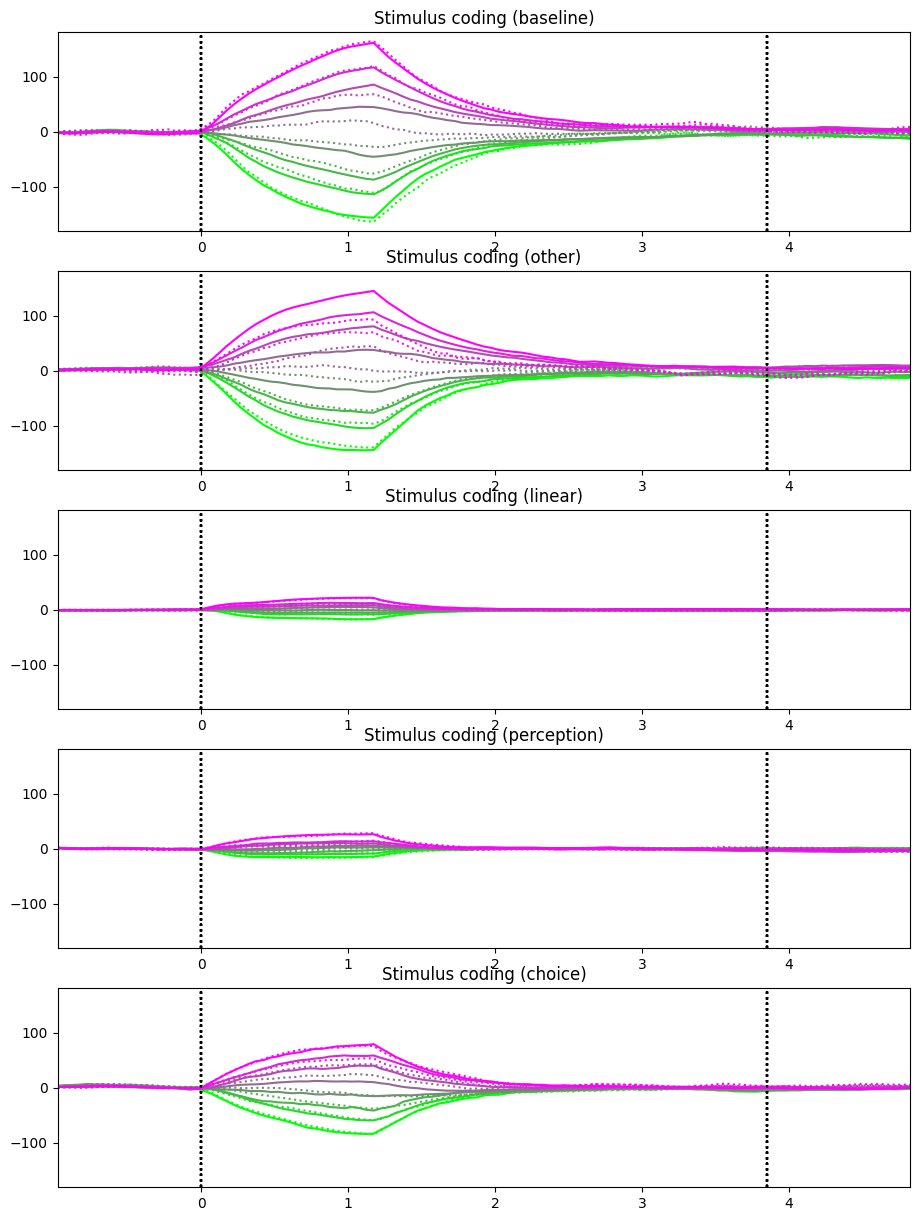

In [68]:
fig, axes = plt.subplots(len(conditions), 1, figsize=(11, 3 * len(conditions)));
y_limits = []
mean_stim_projections = []
for i_condition, condition in enumerate(conditions):
    temp = []
    for i_stim, stim in enumerate(unique_stims):
        for i_choice, choice in enumerate([0, 1]):
            style = '-' if (((stim < 50) and (choice == 0)) or ((stim > 50) and (choice == 1))) else ':'
            v = dPCA_results['baseline']['dpca'].D['st'][:, 0]
            X_tensor = dPCA_results[condition]['X_pseudo_psth'] 
            X_tilde = X_tensor.reshape([X_tensor.shape[0], -1])
            X_tilde -= X_tilde.mean(axis=1).reshape([-1, 1])
            X_tensor = X_tilde.reshape(X_tensor.shape)
            X = X_tensor[:, i_stim, i_choice, :]   
            y = [(v * X[:, k]).sum() for k in range(len(t))]
            temp.append(np.mean(np.abs(y)))
            axes[i_condition].plot(t, y, color=colors[i_stim, :], linestyle=style);
            axes[i_condition].axvline(0, color='k', linestyle=':');
            axes[i_condition].axvline(t_D, color='k', linestyle=':');
            axes[i_condition].set_title('Stimulus coding ({})'.format(condition));
    y_limits.append(axes[i_condition].get_ylim())
    mean_stim_projections.append(temp)
global_limit = np.max([np.max(np.abs(lims)) for lims in y_limits])
for ax in axes:
    ax.set_xlim([t[0], t[-1]]);
    ax.set_ylim([-global_limit, global_limit]);
    
# Figure 6A, 7A (left column)
# plt.savefig('plots/model/dPCA_stimulus_coding.pdf');

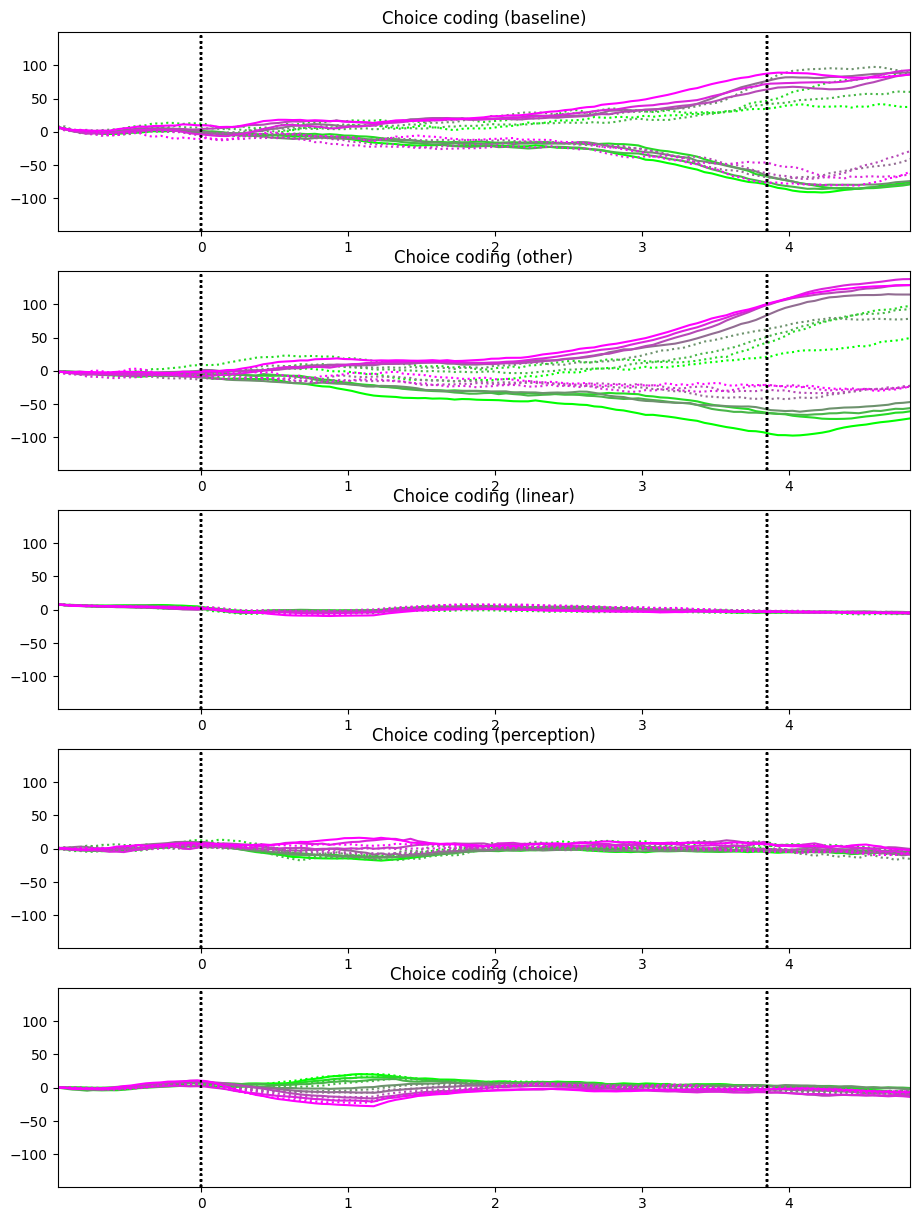

In [69]:
fig, axes = plt.subplots(len(conditions), 1, figsize=(11, 3 * len(conditions)));
y_limits = []
mean_choice_projections = []
for i_condition, condition in enumerate(conditions):
    temp = []
    for i_stim, stim in enumerate(unique_stims):
        for i_choice, choice in enumerate([0, 1]):
            style = '-' if (((stim < 50) and (choice == 0)) or ((stim > 50) and (choice == 1))) else ':'
            v = dPCA_results['baseline']['dpca'].D['dt'][:, 0]
            X_tensor = dPCA_results[condition]['X_pseudo_psth']
            X_tilde = X_tensor.reshape([X_tensor.shape[0], -1])
            X_tilde -= X_tilde.mean(axis=1).reshape([-1, 1])
            X_tensor = X_tilde.reshape(X_tensor.shape)
            X = X_tensor[:, i_stim, i_choice, :]   
            y = [(v * X[:, k]).sum() for k in range(len(t))]
            temp.append(np.mean(np.abs(y)))
            axes[i_condition].plot(t, y, color=colors[i_stim, :], linestyle=style);
            axes[i_condition].axvline(0, color='k', linestyle=':');
            axes[i_condition].axvline(t_D, color='k', linestyle=':');
            axes[i_condition].set_title('Choice coding ({})'.format(condition));
    y_limits.append(axes[i_condition].get_ylim())
    mean_choice_projections.append(temp)
global_limit = np.max([np.max(np.abs(lims)) for lims in y_limits])
for ax in axes:
    ax.set_xlim([t[0], t[-1]]);
    ax.set_ylim([-global_limit, global_limit]);
    
# Figure 6B, 7A (right column)
# plt.savefig('plots/model/dPCA_choice_coding.pdf');

In [70]:
# calculate component overlaps

stim_ov_mat = np.zeros([len(conditions), len(conditions)])
choice_ov_mat = np.zeros([len(conditions), len(conditions)])
for i_condition, condition_i in enumerate(conditions):
    for j_condition, condition_j in enumerate(conditions):
        v_stim_i = dPCA_results[condition_i]['dpca'].P['st'][:, 0]
        v_stim_j = dPCA_results[condition_j]['dpca'].P['st'][:, 0]
        stim_ov_mat[i_condition, j_condition] = overlap(v_stim_i, v_stim_j)
        v_choice_i = dPCA_results[condition_i]['dpca'].P['dt'][:, 0]
        v_choice_j = dPCA_results[condition_j]['dpca'].P['dt'][:, 0]
        choice_ov_mat[i_condition, j_condition] = overlap(v_choice_i, v_choice_j)

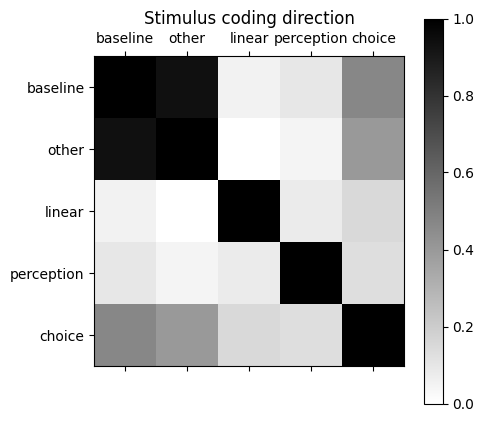

In [71]:
# plot stimulus component overlaps

fig, ax = plt.subplots(figsize=(5, 5));
cmap = LinearSegmentedColormap.from_list('my_cmap', [(0, [1, 1, 1]), (1, [0, 0, 0])])
ax.matshow(stim_ov_mat, cmap=cmap);
ax.set_xticks(range(len(conditions)));
ax.set_xticklabels(conditions);
ax.set_yticks(range(len(conditions)));
ax.set_yticklabels(conditions);
ax.set_title('Stimulus coding direction');
plt.colorbar(plt.cm.ScalarMappable(cmap=cmap), ax=ax);

# Figure 7B (top)
# plt.savefig('plots/model/dpca_stimulus_coding_direction_overlaps.pdf');

In [72]:
print('Stimulus component overlaps:\n')
for i_condition, condition_i in enumerate(conditions):
    for j_condition, condition_j in enumerate(conditions):
        v_stim_i = dPCA_results[condition_i]['dpca'].P['st'][:, 0]
        v_stim_j = dPCA_results[condition_j]['dpca'].P['st'][:, 0]
        ov = overlap(v_stim_i, v_stim_j)
        print('    {} vs. {}: {:.4f}'.format(condition_i, condition_j, ov))

Stimulus component overlaps:

    baseline vs. baseline: 1.0000
    baseline vs. other: 0.9467
    baseline vs. linear: 0.2076
    baseline vs. perception: 0.2439
    baseline vs. choice: 0.5574
    other vs. baseline: 0.9467
    other vs. other: 1.0000
    other vs. linear: 0.1648
    other vs. perception: 0.2025
    other vs. choice: 0.4983
    linear vs. baseline: 0.2076
    linear vs. other: 0.1648
    linear vs. linear: 1.0000
    linear vs. perception: 0.2315
    linear vs. choice: 0.2890
    perception vs. baseline: 0.2439
    perception vs. other: 0.2025
    perception vs. linear: 0.2315
    perception vs. perception: 1.0000
    perception vs. choice: 0.2753
    choice vs. baseline: 0.5574
    choice vs. other: 0.4983
    choice vs. linear: 0.2890
    choice vs. perception: 0.2753
    choice vs. choice: 1.0000


In [73]:
# stats on stimulus component projections

data_stim = [(mean_stim_projections[i_condition], condition) for i_condition, condition in enumerate(conditions)]
data_stim[1], data_stim[2], data_stim[3], data_stim[4] = (
    data_stim[2], data_stim[3], data_stim[4], data_stim[1]) # swap order for plot

n_subjects = 16 # 'subjects' here are trial conditions (8 stims * 2 choices)
n_conditions = len(data_stim)
subject = [i for i in range(n_subjects)] * n_conditions
condition, measurement = [], []
for i in range(n_conditions):
    condition += ['{}'.format(i)] * n_subjects
    measurement += data_stim[i][0]
df = pd.DataFrame({
    'subject': subject,
    'condition': condition,
    'measurement': measurement
})

# Perform repeated measures ANOVA
rm_anova = AnovaRM(df, 'measurement', 'subject', within=['condition'])
results = rm_anova.fit()

# Print the results
display(results.anova_table)

# post-hoc tests
correction = scipy.special.comb(n_conditions, 2) # bonferroni correction for number of paired tests

print('\nPost-hoc tests (Bonferroni-adjusted p-values):\n')
for i in range(n_conditions - 1):
    for j in range(i + 1, n_conditions):
        x1, label1 = data_stim[i]
        x2, label2 = data_stim[j]
        print('    {} vs. {}: p = {:.4e}'.format(label1, label2, correction * scipy.stats.ttest_rel(x1, x2)[1]))

,F Value,Num DF,Den DF,Pr > F
condition,56.481801,4.0,60.0,1.121121e-19



Post-hoc tests (Bonferroni-adjusted p-values):

    baseline vs. linear: p = 5.6736e-06
    baseline vs. perception: p = 7.5311e-06
    baseline vs. choice: p = 2.3853e-05
    baseline vs. other: p = 1.0548e-01
    linear vs. perception: p = 1.8270e-02
    linear vs. choice: p = 1.6076e-06
    linear vs. other: p = 1.9137e-05
    perception vs. choice: p = 3.8654e-06
    perception vs. other: p = 2.7703e-05
    choice vs. other: p = 9.1648e-04


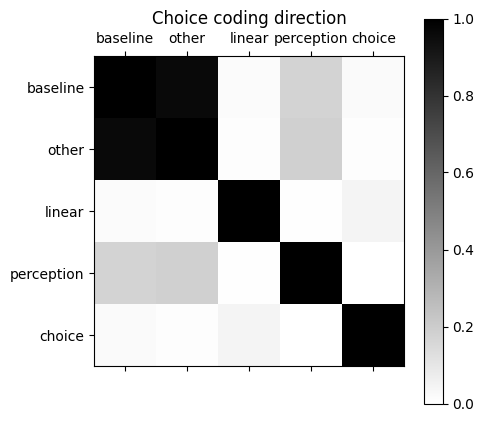

In [74]:
# plot choice component overlaps

fig, ax = plt.subplots(figsize=(5, 5));
cmap = LinearSegmentedColormap.from_list('my_cmap', [(0, [1, 1, 1]), (1, [0, 0, 0])])
ax.matshow(choice_ov_mat, cmap=cmap);
ax.set_xticks(range(len(conditions)));
ax.set_xticklabels(conditions);
ax.set_yticks(range(len(conditions)));
ax.set_yticklabels(conditions);
ax.set_title('Choice coding direction');
plt.colorbar(plt.cm.ScalarMappable(cmap=cmap), ax=ax);

# Figure 7B (bottom)
# plt.savefig('plots/model/dpca_choice_coding_direction_overlaps.pdf');

In [75]:
print('\nChoice component overlaps:\n')
for i_condition, condition_i in enumerate(conditions):
    for j_condition, condition_j in enumerate(conditions):
        v_choice_i = dPCA_results[condition_i]['dpca'].P['dt'][:, 0]
        v_choice_j = dPCA_results[condition_j]['dpca'].P['dt'][:, 0]
        ov = overlap(v_choice_i, v_choice_j)
        print('    {} vs. {}: {:.4f}'.format(condition_i, condition_j, ov))


Choice component overlaps:

    baseline vs. baseline: 1.0000
    baseline vs. other: 0.9593
    baseline vs. linear: 0.0163
    baseline vs. perception: 0.1689
    baseline vs. choice: 0.0211
    other vs. baseline: 0.9593
    other vs. other: 1.0000
    other vs. linear: 0.0123
    other vs. perception: 0.1856
    other vs. choice: 0.0087
    linear vs. baseline: 0.0163
    linear vs. other: 0.0123
    linear vs. linear: 1.0000
    linear vs. perception: 0.0052
    linear vs. choice: 0.0464
    perception vs. baseline: 0.1689
    perception vs. other: 0.1856
    perception vs. linear: 0.0052
    perception vs. perception: 1.0000
    perception vs. choice: 0.0006
    choice vs. baseline: 0.0211
    choice vs. other: 0.0087
    choice vs. linear: 0.0464
    choice vs. perception: 0.0006
    choice vs. choice: 1.0000


In [76]:
# stats on choice component projections

data_choice = [(mean_choice_projections[i_condition], condition) for i_condition, condition in enumerate(conditions)]
data_choice[1], data_choice[2], data_choice[3], data_choice[4] = (
    data_choice[2], data_choice[3], data_choice[4], data_choice[1]) # swap order for plot

n_subjects = 16 # 'subjects' here are trial conditions (8 stims * 2 choices)
n_conditions = len(data_choice)
subject = [i for i in range(n_subjects)] * n_conditions
condition, measurement = [], []
for i in range(n_conditions):
    condition += ['{}'.format(i)] * n_subjects
    measurement += data_choice[i][0]
df = pd.DataFrame({
    'subject': subject,
    'condition': condition,
    'measurement': measurement
})

# Perform repeated measures ANOVA
rm_anova = AnovaRM(df, 'measurement', 'subject', within=['condition'])
results = rm_anova.fit()

# Print the results
display(results.anova_table)

# post-hoc tests
correction = scipy.special.comb(n_conditions, 2) # bonferroni correction for number of paired tests

print('\nPost-hoc tests (Bonferroni-adjusted p-values):\n')
for i in range(n_conditions - 1):
    for j in range(i + 1, n_conditions):
        x1, label1 = data_choice[i]
        x2, label2 = data_choice[j]
        print('    {} vs. {}: p = {:.4e}'.format(label1, label2, correction * scipy.stats.ttest_rel(x1, x2)[1]))

,F Value,Num DF,Den DF,Pr > F
condition,114.373522,4.0,60.0,2.328365e-27



Post-hoc tests (Bonferroni-adjusted p-values):

    baseline vs. linear: p = 1.0506e-10
    baseline vs. perception: p = 2.8133e-10
    baseline vs. choice: p = 2.5803e-10
    baseline vs. other: p = 9.2759e+00
    linear vs. perception: p = 2.5393e-02
    linear vs. choice: p = 4.2476e-05
    linear vs. other: p = 1.2730e-06
    perception vs. choice: p = 8.7827e-01
    perception vs. other: p = 1.3610e-06
    choice vs. other: p = 2.0232e-06


### --- dPCA ---

#### dPCA for constrained units only, no ablations

In [77]:
# filter in the original way so F6S1A-B can be directly compared to 6A-B

filter_models = True # filter out models that do not have at least 2 trials per choice across all ablation conditions
                     # this is done to improve the linear prediction of missing trial types

outputs = {
    'baseline': output_noise,
    'other': output_noise_ablate_other,
    'linear': output_noise_ablate_linear,
    'perception': output_noise_ablate_perception,
    'choice': output_noise_ablate_choice
}
conditions = outputs.keys()

# filtering criteria
good_model_inds = []
for i_model in range(len(included_sessions)):
    is_good = True
    if filter_models:
        for condition in conditions:
            y_choice = outputs[condition]['y_lefts'][i_model]
            if (y_choice.sum() <= 1) or (y_choice.sum() >= len(y_choice) - 1):
                is_good = False
                break
    if is_good:
        good_model_inds.append(i_model)
if filter_models:
    print('{}/{} models passed.'.format(len(good_model_inds), len(included_sessions)))
else:
    print('All models included.')
file_name = 'filtered' if filter_models else 'all' 

14/23 models passed.


In [78]:
try:
    
    with open('data/model/dPCA_{}_constrained_results.pkl'.format(file_name), 'rb') as file:
        dPCA_results = pickle.load(file)
        file.close()
        
except:
    
    dPCA_results = {}

    # get maximum number of trials for any parameter combination across sessions
    max_num_trials = 0
    n_neurons_pseudo = 0
    flagged_models = []
    for i_model in good_model_inds:
        X = outputs['baseline']['Xs'][i_model]
        y_stim = outputs['baseline']['y_stims'][i_model]
        y_choice = outputs['baseline']['y_lefts'][i_model]
        n_neurons_pseudo += int(round(X.shape[1] / 5.88))
        for stim in unique_stims:
            for choice in [0, 1]:
                n = ((y_stim == stim) & (y_choice == choice)).sum()
                if (n == 0) and (i_model not in flagged_models):
                    flagged_models.append(i_model)
                max_num_trials = max(max_num_trials, n)

    # assemble pseudo-population trial-by-trial tensor
    # X_pseudo: (trials x neurons x stimuli x decisions x time)
    X_pseudo = np.full([max_num_trials, n_neurons_pseudo, len(unique_stims), 2, len(t)], np.nan)
    n_neurons_cumul = 0
    for i_model in good_model_inds:
        X = outputs['baseline']['Xs'][i_model]
        X = X[:, :int(round(X.shape[1] / 5.88)), :]
        y_stim = outputs['baseline']['y_stims'][i_model]
        y_choice = outputs['baseline']['y_lefts'][i_model]
        n_neurons = X.shape[1]
        ###----------------------------------------------------------------------------------------------------
        if i_model in flagged_models:
            ### issue: some data are missing for this session
            ### workaround: fit a simple linear model to existing data and use it to predict the missing parts
            predictors = np.vstack([
                y_stim.reshape([1, -1]),
                y_choice.reshape([1, -1]),
                (y_stim * y_choice).reshape([1, -1]),
                np.ones([1, X.shape[0]])
            ])
            betas = [[scipy.linalg.pinv(predictors @ predictors.T) @ predictors @ X[:, i_n, i_t].reshape([-1, 1])
                      for i_t in range(len(t))] for i_n in range(n_neurons)]
        ###-----------------------------------------------------------------------------------------------------
        for i_stim, stim in enumerate(unique_stims):
            for i_choice, choice in enumerate([0, 1]):
                trial_mask = (y_stim == stim) & (y_choice == choice)
                n_trials = trial_mask.sum()
                if n_trials == 0:
                    ### use the linear model's prediction ------------------------------------------------------
                    for i_n in range(n_neurons):
                        for i_t in range(len(t)):
                            r = max((betas[i_n][i_t].flatten() * np.array([stim, choice, stim * choice, 1])).sum(), 0)
                            X_pseudo[:2, n_neurons_cumul + i_n, i_stim, i_choice, i_t] = np.array([r, r])
                    ### ----------------------------------------------------------------------------------------
                elif n_trials == 1:
                    X_pseudo[:2, n_neurons_cumul:(n_neurons_cumul + n_neurons), i_stim, i_choice, :] = \
                        np.concatenate([
                        X[trial_mask, :, :].reshape([1, n_neurons, len(t)]),
                        X[trial_mask, :, :].reshape([1, n_neurons, len(t)])],
                        axis=0)
                else:
                    X_pseudo[:n_trials, n_neurons_cumul:(n_neurons_cumul + n_neurons), i_stim, i_choice, :] = \
                        X[trial_mask, :, :]
        n_neurons_cumul += n_neurons

    # get the pseudo-population trial-averaged (PSTH) tensor
    X_pseudo_psth = np.nanmean(X_pseudo, axis=0)

    # do the dPCA
    dpca = dPCA.dPCA(labels='sdt', regularizer='auto', 
                     join={'st': ['s', 'st'], 'dt': ['d', 'dt'], 'sdt': ['sd', 'sdt']})
    dpca.protect = ['t']
    Z = dpca.fit_transform(X_pseudo_psth, X_pseudo)

    dPCA_results['baseline'] = {'X_pseudo': X_pseudo, 'X_pseudo_psth': X_pseudo_psth, 'dpca': dpca, 'Z': Z}
        
    with open('data/model/dPCA_{}_constrained_results.pkl'.format(file_name), 'wb') as file:
        pickle.dump(dPCA_results, file)
        file.close()

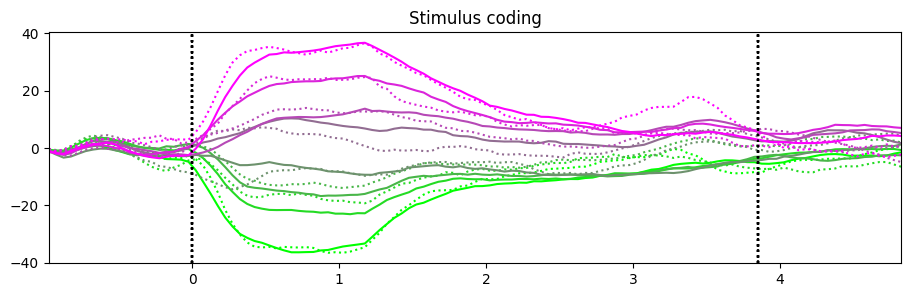

In [79]:
fig, axes = plt.subplots(figsize=(11, 3));
for i_stim, stim in enumerate(unique_stims):
    for i_choice, choice in enumerate([0, 1]):
        style = '-' if (((stim < 50) and (choice == 0)) or ((stim > 50) and (choice == 1))) else ':'
        v = dPCA_results['baseline']['dpca'].D['st'][:, 0]
        X_tensor = dPCA_results['baseline']['X_pseudo_psth']
        X_tilde = X_tensor.reshape([X_tensor.shape[0], -1])
        X_tilde -= X_tilde.mean(axis=1).reshape([-1, 1])
        X_tensor = X_tilde.reshape(X_tensor.shape)
        X = X_tensor[:, i_stim, i_choice, :]   
        y = [(v * X[:, k]).sum() for k in range(len(t))]
        axes.plot(t, y, color=colors[i_stim, :], linestyle=style);
        axes.axvline(0, color='k', linestyle=':');
        axes.axvline(t_D, color='k', linestyle=':');
        axes.set_title('Stimulus coding');
axes.set_xlim([t[0], t[-1]]);

# Figure 6 - Supplement 1 A
# plt.savefig('plots/review/model/dPCA_stimulus_coding_constrained.pdf');

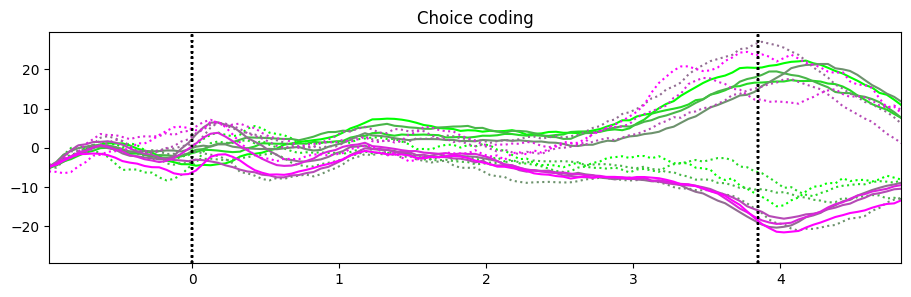

In [80]:
fig, axes = plt.subplots(figsize=(11, 3));
for i_stim, stim in enumerate(unique_stims):
    for i_choice, choice in enumerate([0, 1]):
        style = '-' if (((stim < 50) and (choice == 0)) or ((stim > 50) and (choice == 1))) else ':'
        v = dPCA_results['baseline']['dpca'].D['dt'][:, 0]
        X_tensor = dPCA_results['baseline']['X_pseudo_psth']
        X_tilde = X_tensor.reshape([X_tensor.shape[0], -1])
        X_tilde -= X_tilde.mean(axis=1).reshape([-1, 1])
        X_tensor = X_tilde.reshape(X_tensor.shape)
        X = X_tensor[:, i_stim, i_choice, :]   
        y = [(v * X[:, k]).sum() for k in range(len(t))]
        axes.plot(t, y, color=colors[i_stim, :], linestyle=style);
        axes.axvline(0, color='k', linestyle=':');
        axes.axvline(t_D, color='k', linestyle=':');
        axes.set_title('Choice coding');
axes.set_xlim([t[0], t[-1]]);
y_lim = np.max(np.abs(axes.get_ylim())); axes.set_ylim([-y_lim, y_lim]);
    
# Figure 6 - Supplement 1 B
# plt.savefig('plots/review/model/dPCA_choice_coding_constrained.pdf');

### --- dPCA ---

#### dPCA for unconstrained units only, no ablations

In [81]:
# filter in the original way so F6S2A-B can be directly compared to 6A-B

filter_models = True # filter out models that do not have at least 2 trials per choice across all ablation conditions
                     # this is done to improve the linear prediction of missing trial types

outputs = {
    'baseline': output_noise,
    'other': output_noise_ablate_other,
    'linear': output_noise_ablate_linear,
    'perception': output_noise_ablate_perception,
    'choice': output_noise_ablate_choice
}
conditions = outputs.keys()

# filtering criteria
good_model_inds = []
for i_model in range(len(included_sessions)):
    is_good = True
    if filter_models:
        for condition in conditions:
            y_choice = outputs[condition]['y_lefts'][i_model]
            if (y_choice.sum() <= 1) or (y_choice.sum() >= len(y_choice) - 1):
                is_good = False
                break
    if is_good:
        good_model_inds.append(i_model)
if filter_models:
    print('{}/{} models passed.'.format(len(good_model_inds), len(included_sessions)))
else:
    print('All models included.')
file_name = 'filtered' if filter_models else 'all' 

14/23 models passed.


In [82]:
try:
    
    with open('data/model/dPCA_{}_unconstrained_results.pkl'.format(file_name), 'rb') as file:
        dPCA_results = pickle.load(file)
        file.close()
        
except:
    
    dPCA_results = {}

    # get maximum number of trials for any parameter combination across sessions
    max_num_trials = 0
    n_neurons_pseudo = 0
    flagged_models = []
    for i_model in good_model_inds:
        X = outputs['baseline']['Xs'][i_model]
        y_stim = outputs['baseline']['y_stims'][i_model]
        y_choice = outputs['baseline']['y_lefts'][i_model]
        n_neurons_pseudo += (X.shape[1] - int(round(X.shape[1] / 5.88)))
        for stim in unique_stims:
            for choice in [0, 1]:
                n = ((y_stim == stim) & (y_choice == choice)).sum()
                if (n == 0) and (i_model not in flagged_models):
                    flagged_models.append(i_model)
                max_num_trials = max(max_num_trials, n)

    # assemble pseudo-population trial-by-trial tensor
    # X_pseudo: (trials x neurons x stimuli x decisions x time)
    X_pseudo = np.full([max_num_trials, n_neurons_pseudo, len(unique_stims), 2, len(t)], np.nan)
    n_neurons_cumul = 0
    for i_model in good_model_inds:
        X = outputs['baseline']['Xs'][i_model]
        X = X[:, int(round(X.shape[1] / 5.88)):, :]
        y_stim = outputs['baseline']['y_stims'][i_model]
        y_choice = outputs['baseline']['y_lefts'][i_model]
        n_neurons = X.shape[1]
        ###----------------------------------------------------------------------------------------------------
        if i_model in flagged_models:
            ### issue: some data are missing for this session
            ### workaround: fit a simple linear model to existing data and use it to predict the missing parts
            predictors = np.vstack([
                y_stim.reshape([1, -1]),
                y_choice.reshape([1, -1]),
                (y_stim * y_choice).reshape([1, -1]),
                np.ones([1, X.shape[0]])
            ])
            betas = [[scipy.linalg.pinv(predictors @ predictors.T) @ predictors @ X[:, i_n, i_t].reshape([-1, 1])
                      for i_t in range(len(t))] for i_n in range(n_neurons)]
        ###-----------------------------------------------------------------------------------------------------
        for i_stim, stim in enumerate(unique_stims):
            for i_choice, choice in enumerate([0, 1]):
                trial_mask = (y_stim == stim) & (y_choice == choice)
                n_trials = trial_mask.sum()
                if n_trials == 0:
                    ### use the linear model's prediction ------------------------------------------------------
                    for i_n in range(n_neurons):
                        for i_t in range(len(t)):
                            r = max((betas[i_n][i_t].flatten() * np.array([stim, choice, stim * choice, 1])).sum(), 0)
                            X_pseudo[:2, n_neurons_cumul + i_n, i_stim, i_choice, i_t] = np.array([r, r])
                    ### ----------------------------------------------------------------------------------------
                elif n_trials == 1:
                    X_pseudo[:2, n_neurons_cumul:(n_neurons_cumul + n_neurons), i_stim, i_choice, :] = \
                        np.concatenate([
                        X[trial_mask, :, :].reshape([1, n_neurons, len(t)]),
                        X[trial_mask, :, :].reshape([1, n_neurons, len(t)])],
                        axis=0)
                else:
                    X_pseudo[:n_trials, n_neurons_cumul:(n_neurons_cumul + n_neurons), i_stim, i_choice, :] = \
                        X[trial_mask, :, :]
        n_neurons_cumul += n_neurons

    # get the pseudo-population trial-averaged (PSTH) tensor
    X_pseudo_psth = np.nanmean(X_pseudo, axis=0)

    # do the dPCA
    dpca = dPCA.dPCA(labels='sdt', regularizer='auto', 
                     join={'st': ['s', 'st'], 'dt': ['d', 'dt'], 'sdt': ['sd', 'sdt']})
    dpca.protect = ['t']
    Z = dpca.fit_transform(X_pseudo_psth, X_pseudo)

    dPCA_results['baseline'] = {'X_pseudo': X_pseudo, 'X_pseudo_psth': X_pseudo_psth, 'dpca': dpca, 'Z': Z}
        
    with open('data/model/dPCA_{}_unconstrained_results.pkl'.format(file_name), 'wb') as file:
        pickle.dump(dPCA_results, file)
        file.close()

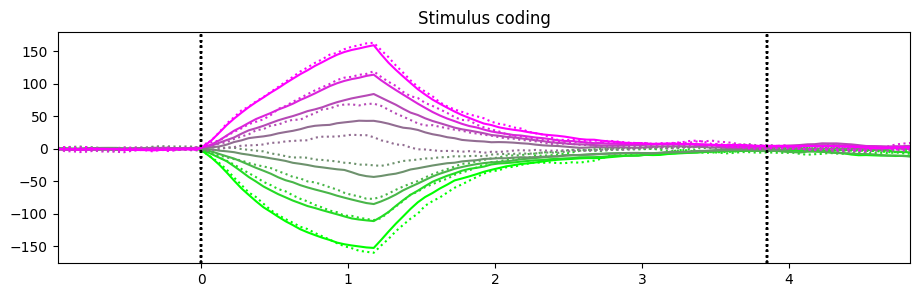

In [83]:
fig, axes = plt.subplots(figsize=(11, 3));
for i_stim, stim in enumerate(unique_stims):
    for i_choice, choice in enumerate([0, 1]):
        style = '-' if (((stim < 50) and (choice == 0)) or ((stim > 50) and (choice == 1))) else ':'
        v = dPCA_results['baseline']['dpca'].D['st'][:, 0]
        X_tensor = dPCA_results['baseline']['X_pseudo_psth']
        X_tilde = X_tensor.reshape([X_tensor.shape[0], -1])
        X_tilde -= X_tilde.mean(axis=1).reshape([-1, 1])
        X_tensor = X_tilde.reshape(X_tensor.shape)
        X = X_tensor[:, i_stim, i_choice, :]   
        y = [(v * X[:, k]).sum() for k in range(len(t))]
        axes.plot(t, y, color=colors[i_stim, :], linestyle=style);
        axes.axvline(0, color='k', linestyle=':');
        axes.axvline(t_D, color='k', linestyle=':');
        axes.set_title('Stimulus coding');
axes.set_xlim([t[0], t[-1]]);

# Figure 6 - Supplement 2 A
# plt.savefig('plots/review/model/dPCA_stimulus_coding_unconstrained.pdf');

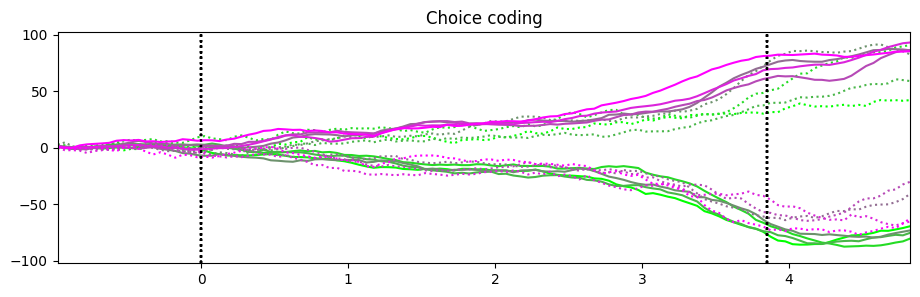

In [84]:
fig, axes = plt.subplots(figsize=(11, 3));
for i_stim, stim in enumerate(unique_stims):
    for i_choice, choice in enumerate([0, 1]):
        style = '-' if (((stim < 50) and (choice == 0)) or ((stim > 50) and (choice == 1))) else ':'
        v = dPCA_results['baseline']['dpca'].D['dt'][:, 0]
        X_tensor = dPCA_results['baseline']['X_pseudo_psth']
        X_tilde = X_tensor.reshape([X_tensor.shape[0], -1])
        X_tilde -= X_tilde.mean(axis=1).reshape([-1, 1])
        X_tensor = X_tilde.reshape(X_tensor.shape)
        X = X_tensor[:, i_stim, i_choice, :]   
        y = [(v * X[:, k]).sum() for k in range(len(t))]
        axes.plot(t, y, color=colors[i_stim, :], linestyle=style);
        axes.axvline(0, color='k', linestyle=':');
        axes.axvline(t_D, color='k', linestyle=':');
        axes.set_title('Choice coding');
axes.set_xlim([t[0], t[-1]]);
y_lim = np.max(np.abs(axes.get_ylim())); axes.set_ylim([-y_lim, y_lim]);
    
# Figure 6 - Supplement 2 B
# plt.savefig('plots/review/model/dPCA_choice_coding_unconstrained.pdf');

### --- dPCA ---

#### dPCA for constrained vs unconstrained with ablations

In [85]:
filter_models = True # filter out models that do not have at least 2 trials per choice across all ablation conditions
                     # this is done to improve the linear prediction of missing trial types

outputs = {
    'baseline': output_noise,
    'other': output_noise_ablate_other,
    'other_con': output_noise_ablate_other_con,
    'other_unc': output_noise_ablate_other_unc,
    'linear': output_noise_ablate_linear,
    'linear_con': output_noise_ablate_linear_con,
    'linear_unc': output_noise_ablate_linear_unc,
    'perception': output_noise_ablate_perception,
    'perception_con': output_noise_ablate_perception_con,
    'perception_unc': output_noise_ablate_perception_unc,
    'choice': output_noise_ablate_choice,
    'choice_con': output_noise_ablate_choice_con,
    'choice_unc': output_noise_ablate_choice_unc
}
conditions = outputs.keys()

# filtering criteria
good_model_inds = []
for i_model in range(len(included_sessions)):
    is_good = True
    if filter_models:
        for condition in conditions:
            y_choice = outputs[condition]['y_lefts'][i_model]
            if (y_choice.sum() <= 1) or (y_choice.sum() >= len(y_choice) - 1):
                is_good = False
                break
    if is_good:
        good_model_inds.append(i_model)
if filter_models:
    print('{}/{} models passed.'.format(len(good_model_inds), len(included_sessions)))
else:
    print('All models included.')
file_name = 'filtered' if filter_models else 'all' 

8/23 models passed.


In [86]:
try:
    
    with open('data/model/dPCA_{}_sessions_constrainedAndUnconstrained_results.pkl'.format(file_name), 'rb') as file:
        dPCA_results = pickle.load(file)
        file.close()
        
except:
    
    dPCA_results = {}

    for condition in conditions:

        # get maximum number of trials for any parameter combination across sessions
        max_num_trials = 0
        n_neurons_pseudo = 0
        flagged_models = []
        for i_model in good_model_inds:
            X = outputs[condition]['Xs'][i_model]
            y_stim = outputs[condition]['y_stims'][i_model]
            y_choice = outputs[condition]['y_lefts'][i_model]
            n_neurons_pseudo += X.shape[1]
            for stim in unique_stims:
                for choice in [0, 1]:
                    n = ((y_stim == stim) & (y_choice == choice)).sum()
                    if (n == 0) and (i_model not in flagged_models):
                        flagged_models.append(i_model)
                    max_num_trials = max(max_num_trials, n)

        # assemble pseudo-population trial-by-trial tensor
        # X_pseudo: (trials x neurons x stimuli x decisions x time)
        X_pseudo = np.full([max_num_trials, n_neurons_pseudo, len(unique_stims), 2, len(t)], np.nan)
        n_neurons_cumul = 0
        for i_model in good_model_inds:
            X = outputs[condition]['Xs'][i_model]
            y_stim = outputs[condition]['y_stims'][i_model]
            y_choice = outputs[condition]['y_lefts'][i_model]
            n_neurons = X.shape[1]
            ###----------------------------------------------------------------------------------------------------
            if i_model in flagged_models:
                ### issue: some data are missing for this session
                ### workaround: fit a simple linear model to existing data and use it to predict the missing parts
                predictors = np.vstack([
                    y_stim.reshape([1, -1]),
                    y_choice.reshape([1, -1]),
                    (y_stim * y_choice).reshape([1, -1]),
                    np.ones([1, X.shape[0]])
                ])
                betas = [[scipy.linalg.pinv(predictors @ predictors.T) @ predictors @ X[:, i_n, i_t].reshape([-1, 1])
                          for i_t in range(len(t))] for i_n in range(n_neurons)]
            ###-----------------------------------------------------------------------------------------------------
            for i_stim, stim in enumerate(unique_stims):
                for i_choice, choice in enumerate([0, 1]):
                    trial_mask = (y_stim == stim) & (y_choice == choice)
                    n_trials = trial_mask.sum()
                    if n_trials == 0:
                        ### use the linear model's prediction ------------------------------------------------------
                        for i_n in range(n_neurons):
                            for i_t in range(len(t)):
                                r = max((betas[i_n][i_t].flatten() * np.array([stim, choice, stim * choice, 1])).sum(), 0)
                                X_pseudo[:2, n_neurons_cumul + i_n, i_stim, i_choice, i_t] = np.array([r, r])
                        ### ----------------------------------------------------------------------------------------
                    elif n_trials == 1:
                        X_pseudo[:2, n_neurons_cumul:(n_neurons_cumul + n_neurons), i_stim, i_choice, :] = \
                            np.concatenate([
                            X[trial_mask, :, :].reshape([1, n_neurons, len(t)]),
                            X[trial_mask, :, :].reshape([1, n_neurons, len(t)])],
                            axis=0)
                    else:
                        X_pseudo[:n_trials, n_neurons_cumul:(n_neurons_cumul + n_neurons), i_stim, i_choice, :] = \
                            X[trial_mask, :, :]
            n_neurons_cumul += n_neurons

        # get the pseudo-population trial-averaged (PSTH) tensor
        X_pseudo_psth = np.nanmean(X_pseudo, axis=0)

        # do the dPCA
        dpca = dPCA.dPCA(labels='sdt', regularizer='auto', 
                         join={'st': ['s', 'st'], 'dt': ['d', 'dt'], 'sdt': ['sd', 'sdt']})
        dpca.protect = ['t']
        Z = dpca.fit_transform(X_pseudo_psth, X_pseudo)

        dPCA_results[condition] = {'X_pseudo': X_pseudo, 'X_pseudo_psth': X_pseudo_psth, 'dpca': dpca, 'Z': Z}

    with open('data/model/dPCA_{}_sessions_constrainedAndUnconstrained_results.pkl'.format(file_name), 'wb') as file:
        pickle.dump(dPCA_results, file)
        file.close()

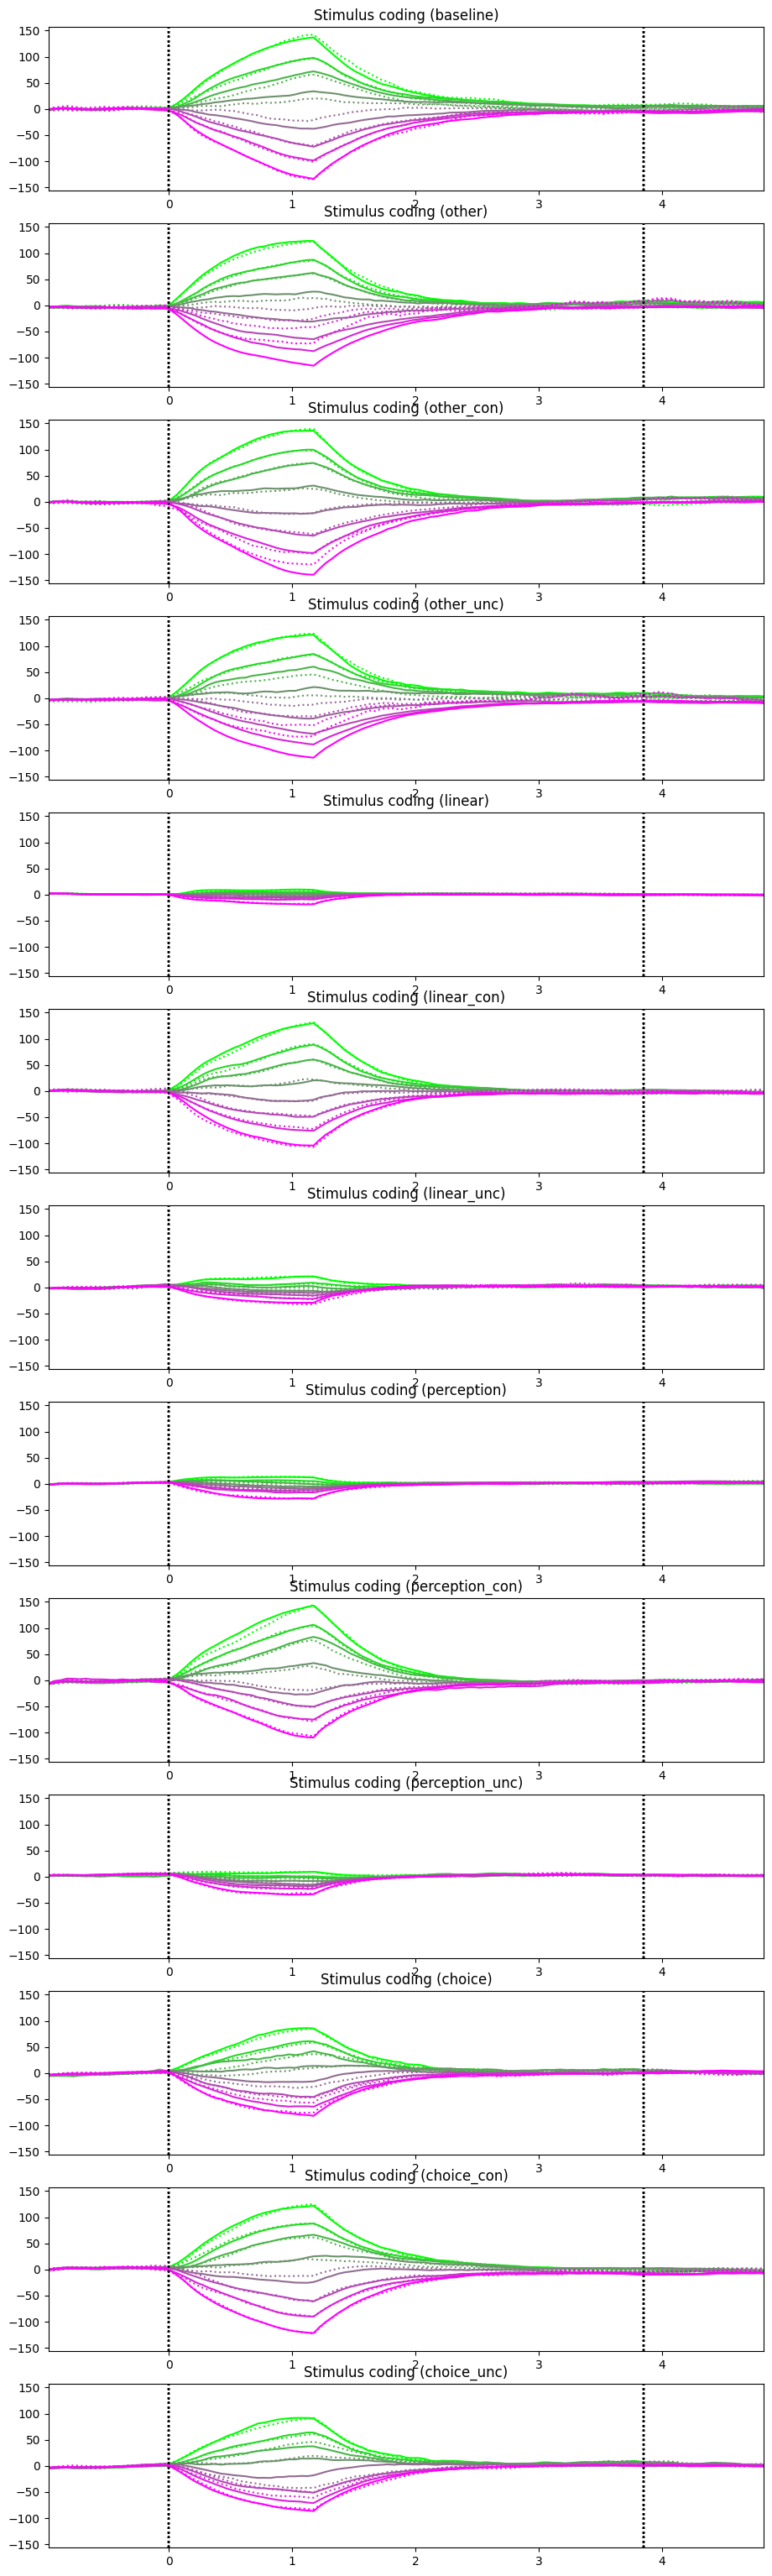

In [88]:
fig, axes = plt.subplots(len(conditions), 1, figsize=(11, 3 * len(conditions)));
y_limits = []
mean_stim_projections_con_vs_unc = {}
for i_condition, condition in enumerate(conditions):
    temp = []
    for i_stim, stim in enumerate(unique_stims):
        for i_choice, choice in enumerate([0, 1]):
            style = '-' if (((stim < 50) and (choice == 0)) or ((stim > 50) and (choice == 1))) else ':'
            v = dPCA_results['baseline']['dpca'].D['st'][:, 0]
            X_tensor = dPCA_results[condition]['X_pseudo_psth']
            X_tilde = X_tensor.reshape([X_tensor.shape[0], -1])
            X_tilde -= X_tilde.mean(axis=1).reshape([-1, 1])
            X_tensor = X_tilde.reshape(X_tensor.shape)
            X = X_tensor[:, i_stim, i_choice, :]   
            y = [(v * X[:, k]).sum() for k in range(len(t))]
            temp.append(np.mean(np.abs(y)))
            axes[i_condition].plot(t, y, color=colors[i_stim, :], linestyle=style);
            axes[i_condition].axvline(0, color='k', linestyle=':');
            axes[i_condition].axvline(t_D, color='k', linestyle=':');
            axes[i_condition].set_title('Stimulus coding ({})'.format(condition));
    y_limits.append(axes[i_condition].get_ylim())
    mean_stim_projections_con_vs_unc[condition] = temp
global_limit = np.max([np.max(np.abs(lims)) for lims in y_limits])
for ax in axes:
    ax.set_xlim([t[0], t[-1]]);
    ax.set_ylim([-global_limit, global_limit]);
    
# Figure 7 - Supplement 1 A
# plt.savefig('plots/review/model/dPCA_con_vs_unc_stimulus_coding.pdf');

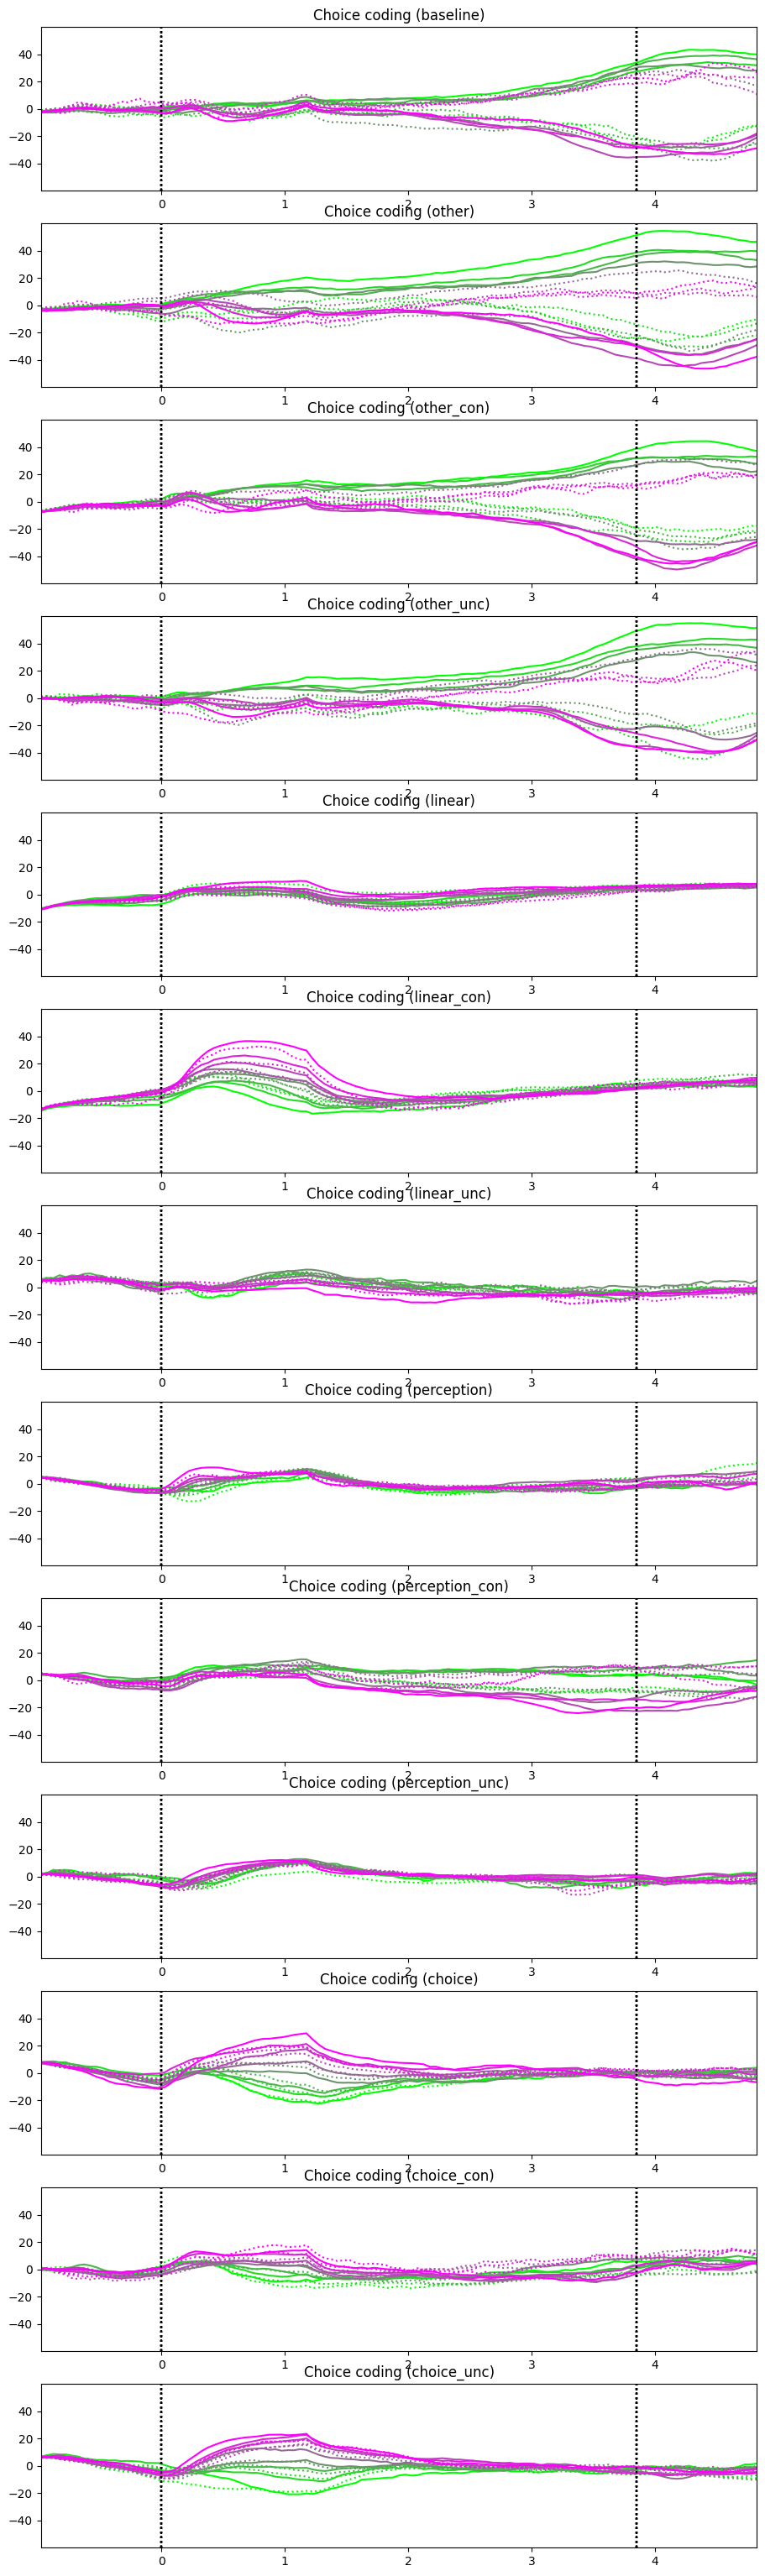

In [89]:
fig, axes = plt.subplots(len(conditions), 1, figsize=(11, 3 * len(conditions)));
y_limits = []
mean_choice_projections_con_vs_unc = {}
for i_condition, condition in enumerate(conditions):
    temp = []
    for i_stim, stim in enumerate(unique_stims):
        for i_choice, choice in enumerate([0, 1]):
            style = '-' if (((stim < 50) and (choice == 0)) or ((stim > 50) and (choice == 1))) else ':'
            v = dPCA_results['baseline']['dpca'].D['dt'][:, 0]
            X_tensor = dPCA_results[condition]['X_pseudo_psth']
            X_tilde = X_tensor.reshape([X_tensor.shape[0], -1])
            X_tilde -= X_tilde.mean(axis=1).reshape([-1, 1])
            X_tensor = X_tilde.reshape(X_tensor.shape)
            X = X_tensor[:, i_stim, i_choice, :]   
            y = [(v * X[:, k]).sum() for k in range(len(t))]
            temp.append(np.mean(np.abs(y)))
            axes[i_condition].plot(t, y, color=colors[i_stim, :], linestyle=style);
            axes[i_condition].axvline(0, color='k', linestyle=':');
            axes[i_condition].axvline(t_D, color='k', linestyle=':');
            axes[i_condition].set_title('Choice coding ({})'.format(condition));
    y_limits.append(axes[i_condition].get_ylim())
    mean_choice_projections_con_vs_unc[condition] = temp
global_limit = np.max([np.max(np.abs(lims)) for lims in y_limits])
for ax in axes:
    ax.set_xlim([t[0], t[-1]]);
    ax.set_ylim([-global_limit, global_limit]);
    
# Figure 7 - Supplement 1 B
# plt.savefig('plots/review/model/dPCA_con_vs_unc_choice_coding.pdf');

In [90]:
'''
2-way within-subjects ANOVA on stimulus component projections
factor 1: coding type (4 levels)
factor 2: constrained vs unconstrained (2 levels)

There is only 1 control group b/c factor 2 does not apply when ablating nothing
Remove it as a level of factor 1 to avoid an empty cell in the 2-way ANOVA
To compare groups to control, separately use Dunnett's test on all 9 groups

This is pseudo-population data, so the subjects are no longer individual models
Instead, they are the 16 trial types
'''

n_subjects = 16
coding_type = ['linear', 'perception', 'choice', 'other']
constraint = ['con', 'unc']
col_subject = list(range(16)) * (len(coding_type) * len(constraint))
col_coding_type, col_constraint, col_measurement = [], [], []

for coding_type_i in coding_type:
    for constraint_i in constraint:
        col_coding_type += [coding_type_i] * n_subjects
        col_constraint += [constraint_i] * n_subjects
        col_measurement += list(mean_stim_projections_con_vs_unc[coding_type_i + '_' + constraint_i])

df = pd.DataFrame({
    'id': col_subject,
    'iv1': col_coding_type,
    'iv2': col_constraint,
    'dv': col_measurement
})

# Perform repeated measures ANOVA
res_anova = rmAnova2Way(df)

# post-hoc tests

all_groups = [
    ('linear', 'con'),
    ('linear', 'unc'),
    ('perception', 'con'),
    ('perception', 'unc'),
    ('choice', 'con'),
    ('choice', 'unc'),
    ('other', 'con'),
    ('other', 'unc')
]
n_groups = len(all_groups)
correction = scipy.special.comb(n_groups, 2) # bonferroni correction for number of paired tests

p_mat = np.full([n_groups, n_groups], np.nan)
print('\nPost-hoc tests (Bonferroni-adjusted p-values):\n')
for i in range(n_groups - 1):
    for j in range(i + 1, n_groups):
        coding_type_i, constraint_i = all_groups[i]
        x_i = np.array([_ for _ in df[(df['iv1'] == coding_type_i) & (df['iv2'] == constraint_i)]['dv']])
        label_i = coding_type_i + '_' + constraint_i
        coding_type_j, constraint_j = all_groups[j]
        x_j = np.array([_ for _ in df[(df['iv1'] == coding_type_j) & (df['iv2'] == constraint_j)]['dv']])
        label_j = coding_type_j + '_' + constraint_j
        p_adj = correction * scipy.stats.ttest_rel(x_i, x_j)[1]
        print('    {} vs. {}: p = {:.4e}'.format(label_i, label_j, p_adj))
        p_mat[i, j] = (p_adj < 0.01).astype(float)
        
print('')
print(p_mat)

SSE_1b = 1467.5459, SSE_1w = 479.6394, F_1 = 45.8953, p_1 = 0.0000
SSE_2b = 1756.6390, SSE_2w = 694.9224, F_2 = 37.9173, p_2 = 0.0000
SSE_12b = 457.8977, SSE_12w = 372.2726, F_12 = 18.4501, p_12 = 0.0000

Post-hoc tests (Bonferroni-adjusted p-values):

    linear_con vs. linear_unc: p = 3.8138e-04
    linear_con vs. perception_con: p = 1.5985e-02
    linear_con vs. perception_unc: p = 1.8988e-03
    linear_con vs. choice_con: p = 5.7446e-04
    linear_con vs. choice_unc: p = 6.0358e-01
    linear_con vs. other_con: p = 5.2265e-05
    linear_con vs. other_unc: p = 2.6115e+00
    linear_unc vs. perception_con: p = 1.3010e-04
    linear_unc vs. perception_unc: p = 8.4934e+00
    linear_unc vs. choice_con: p = 6.3386e-05
    linear_unc vs. choice_unc: p = 9.1660e-06
    linear_unc vs. other_con: p = 7.0462e-05
    linear_unc vs. other_unc: p = 4.5016e-04
    perception_con vs. perception_unc: p = 6.8152e-04
    perception_con vs. choice_con: p = 1.5891e+00
    perception_con vs. choice_unc

In [91]:
## dunnett test

data = [
    (mean_stim_projections_con_vs_unc[key], key)
    for key in [
        'linear_con', 'linear_unc', 'perception_con', 'perception_unc', 'choice_con', 'choice_unc', 'other_con', 'other_unc'
    ]
]
samples = [np.array(data_[0]) for data_ in data]
labels = [data_[1] for data_ in data]
control = np.array(mean_stim_projections_con_vs_unc['baseline'])
res = scipy.stats.dunnett(*samples, control=control)
print('Dunnett test:\n')
for i in range(len(data)):
    print('Control vs {}: p = {:.4e}'.format(labels[i], res.pvalue[i]))

Dunnett test:

Control vs linear_con: p = 2.9086e-01
Control vs linear_unc: p = 1.3308e-07
Control vs perception_con: p = 6.6125e-01
Control vs perception_unc: p = 1.8665e-07
Control vs choice_con: p = 9.5263e-01
Control vs choice_unc: p = 4.5203e-02
Control vs other_con: p = 9.9999e-01
Control vs other_unc: p = 7.3912e-01


In [92]:
'''
2-way within-subjects ANOVA on choice component projections
factor 1: coding type (4 levels)
factor 2: constrained vs unconstrained (2 levels)

There is only 1 control group b/c factor 2 does not apply when ablating nothing
Remove it as a level of factor 1 to avoid an empty cell in the 2-way ANOVA
To compare groups to control, separately use Dunnett's test on all 9 groups

This is pseudo-population data, so the subjects are no longer individual models
Instead, they are the 16 trial types
'''

n_subjects = 16
coding_type = ['linear', 'perception', 'choice', 'other']
constraint = ['con', 'unc']
col_subject = list(range(16)) * (len(coding_type) * len(constraint))
col_coding_type, col_constraint, col_measurement = [], [], []

for coding_type_i in coding_type:
    for constraint_i in constraint:
        col_coding_type += [coding_type_i] * n_subjects
        col_constraint += [constraint_i] * n_subjects
        col_measurement += list(mean_choice_projections_con_vs_unc[coding_type_i + '_' + constraint_i])

df = pd.DataFrame({
    'id': col_subject,
    'iv1': col_coding_type,
    'iv2': col_constraint,
    'dv': col_measurement
})

# Perform repeated measures ANOVA
res_anova = rmAnova2Way(df)

# post-hoc tests

all_groups = [
    ('linear', 'con'),
    ('linear', 'unc'),
    ('perception', 'con'),
    ('perception', 'unc'),
    ('choice', 'con'),
    ('choice', 'unc'),
    ('other', 'con'),
    ('other', 'unc')
]
n_groups = len(all_groups)
correction = scipy.special.comb(n_groups, 2) # bonferroni correction for number of paired tests

p_mat = np.full([n_groups, n_groups], np.nan)
print('\nPost-hoc tests (Bonferroni-adjusted p-values):\n')
for i in range(n_groups - 1):
    for j in range(i + 1, n_groups):
        coding_type_i, constraint_i = all_groups[i]
        x_i = np.array([_ for _ in df[(df['iv1'] == coding_type_i) & (df['iv2'] == constraint_i)]['dv']])
        label_i = coding_type_i + '_' + constraint_i
        coding_type_j, constraint_j = all_groups[j]
        x_j = np.array([_ for _ in df[(df['iv1'] == coding_type_j) & (df['iv2'] == constraint_j)]['dv']])
        label_j = coding_type_j + '_' + constraint_j
        p_adj = correction * scipy.stats.ttest_rel(x_i, x_j)[1]
        print('    {} vs. {}: p = {:.4e}'.format(label_i, label_j, p_adj))
        p_mat[i, j] = (p_adj < 0.01).astype(float)
        
print('')
print(p_mat)

SSE_1b = 1014.9130, SSE_1w = 329.1814, F_1 = 46.2471, p_1 = 0.0000
SSE_2b = 63.7899, SSE_2w = 22.6537, F_2 = 42.2380, p_2 = 0.0000
SSE_12b = 65.7859, SSE_12w = 72.7438, F_12 = 13.5653, p_12 = 0.0000

Post-hoc tests (Bonferroni-adjusted p-values):

    linear_con vs. linear_unc: p = 4.3561e-06
    linear_con vs. perception_con: p = 5.2487e+00
    linear_con vs. perception_unc: p = 5.4615e-06
    linear_con vs. choice_con: p = 3.4216e-03
    linear_con vs. choice_unc: p = 2.2228e-03
    linear_con vs. other_con: p = 1.3196e-02
    linear_con vs. other_unc: p = 2.8027e-03
    linear_unc vs. perception_con: p = 4.0799e-03
    linear_unc vs. perception_unc: p = 7.1800e-01
    linear_unc vs. choice_con: p = 1.4064e-01
    linear_unc vs. choice_unc: p = 2.0586e+00
    linear_unc vs. other_con: p = 6.8424e-05
    linear_unc vs. other_unc: p = 1.5983e-05
    perception_con vs. perception_unc: p = 7.7429e-04
    perception_con vs. choice_con: p = 1.7419e+00
    perception_con vs. choice_unc: p =

In [93]:
## dunnett test

data = [
    (mean_choice_projections_con_vs_unc[key], key)
    for key in [
        'linear_con', 'linear_unc', 'perception_con', 'perception_unc', 'choice_con', 'choice_unc', 'other_con', 'other_unc'
    ]
]
samples = [np.array(data_[0]) for data_ in data]
labels = [data_[1] for data_ in data]
control = np.array(mean_choice_projections_con_vs_unc['baseline'])
res = scipy.stats.dunnett(*samples, control=control)
print('Dunnett test:\n')
for i in range(len(data)):
    print('Control vs {}: p = {:.4e}'.format(labels[i], res.pvalue[i]))

Dunnett test:

Control vs linear_con: p = 6.9700e-05
Control vs linear_unc: p = 1.5321e-14
Control vs perception_con: p = 1.1627e-06
Control vs perception_unc: p = 2.2204e-16
Control vs choice_con: p = 2.2856e-10
Control vs choice_unc: p = 3.6020e-11
Control vs other_con: p = 4.9875e-01
Control vs other_unc: p = 3.5689e-01


### --- dPCA ---

#### Temporally-restricted ablations

In [94]:
filter_models = True # filter out models that do not have at least 2 trials per choice across all ablation conditions
                     # this is done to improve the linear prediction of missing trial types

outputs = {
    'baseline': output_noise,
    'linear': output_noise_ablate_linear,
    'perception': output_noise_ablate_perception,
    'choice': output_noise_ablate_choice,
    'other': output_noise_ablate_other,
    'linear_beginning': output_noise_ablate_linear_beginning,
    'linear_end': output_noise_ablate_linear_end,
    'perception_beginning': output_noise_ablate_perception_beginning,
    'perception_end': output_noise_ablate_perception_end,
    'choice_beginning': output_noise_ablate_choice_beginning,
    'choice_end': output_noise_ablate_choice_end
}
conditions = outputs.keys()

# filtering criteria
good_model_inds = []
for i_model in range(len(included_sessions)):
    is_good = True
    if filter_models:
        for condition in conditions:
            y_choice = outputs[condition]['y_lefts'][i_model]
            if (y_choice.sum() <= 1) or (y_choice.sum() >= len(y_choice) - 1):
                is_good = False
                break
    if is_good:
        good_model_inds.append(i_model)
if filter_models:
    print('{}/{} models passed.'.format(len(good_model_inds), len(included_sessions)))
else:
    print('All models included.')
file_name = 'filtered' if filter_models else 'all' 

13/23 models passed.


In [95]:
try:
    
    with open('data/model/dPCA_{}_sessions_beginningAndEnd_results.pkl'.format(file_name), 'rb') as file:
        dPCA_results = pickle.load(file)
        file.close()
        
except:
    
    dPCA_results = {}

    for condition in conditions:

        # get maximum number of trials for any parameter combination across sessions
        max_num_trials = 0
        n_neurons_pseudo = 0
        flagged_models = []
        for i_model in good_model_inds:
            X = outputs[condition]['Xs'][i_model]
            y_stim = outputs[condition]['y_stims'][i_model]
            y_choice = outputs[condition]['y_lefts'][i_model]
            n_neurons_pseudo += X.shape[1]
            for stim in unique_stims:
                for choice in [0, 1]:
                    n = ((y_stim == stim) & (y_choice == choice)).sum()
                    if (n == 0) and (i_model not in flagged_models):
                        flagged_models.append(i_model)
                    max_num_trials = max(max_num_trials, n)

        # assemble pseudo-population trial-by-trial tensor
        # X_pseudo: (trials x neurons x stimuli x decisions x time)
        X_pseudo = np.full([max_num_trials, n_neurons_pseudo, len(unique_stims), 2, len(t)], np.nan)
        n_neurons_cumul = 0
        for i_model in good_model_inds:
            X = outputs[condition]['Xs'][i_model]
            y_stim = outputs[condition]['y_stims'][i_model]
            y_choice = outputs[condition]['y_lefts'][i_model]
            n_neurons = X.shape[1]
            ###----------------------------------------------------------------------------------------------------
            if i_model in flagged_models:
                ### issue: some data are missing for this session
                ### workaround: fit a simple linear model to existing data and use it to predict the missing parts
                predictors = np.vstack([
                    y_stim.reshape([1, -1]),
                    y_choice.reshape([1, -1]),
                    (y_stim * y_choice).reshape([1, -1]),
                    np.ones([1, X.shape[0]])
                ])
                betas = [[scipy.linalg.pinv(predictors @ predictors.T) @ predictors @ X[:, i_n, i_t].reshape([-1, 1])
                          for i_t in range(len(t))] for i_n in range(n_neurons)]
            ###-----------------------------------------------------------------------------------------------------
            for i_stim, stim in enumerate(unique_stims):
                for i_choice, choice in enumerate([0, 1]):
                    trial_mask = (y_stim == stim) & (y_choice == choice)
                    n_trials = trial_mask.sum()
                    if n_trials == 0:
                        ### use the linear model's prediction ------------------------------------------------------
                        for i_n in range(n_neurons):
                            for i_t in range(len(t)):
                                r = max((betas[i_n][i_t].flatten() * np.array([stim, choice, stim * choice, 1])).sum(), 0)
                                X_pseudo[:2, n_neurons_cumul + i_n, i_stim, i_choice, i_t] = np.array([r, r])
                        ### ----------------------------------------------------------------------------------------
                    elif n_trials == 1:
                        X_pseudo[:2, n_neurons_cumul:(n_neurons_cumul + n_neurons), i_stim, i_choice, :] = \
                            np.concatenate([
                            X[trial_mask, :, :].reshape([1, n_neurons, len(t)]),
                            X[trial_mask, :, :].reshape([1, n_neurons, len(t)])],
                            axis=0)
                    else:
                        X_pseudo[:n_trials, n_neurons_cumul:(n_neurons_cumul + n_neurons), i_stim, i_choice, :] = \
                            X[trial_mask, :, :]
            n_neurons_cumul += n_neurons

        # get the pseudo-population trial-averaged (PSTH) tensor
        X_pseudo_psth = np.nanmean(X_pseudo, axis=0)

        # do the dPCA
        dpca = dPCA.dPCA(labels='sdt', regularizer='auto', 
                         join={'st': ['s', 'st'], 'dt': ['d', 'dt'], 'sdt': ['sd', 'sdt']})
        dpca.protect = ['t']
        Z = dpca.fit_transform(X_pseudo_psth, X_pseudo)

        dPCA_results[condition] = {'X_pseudo': X_pseudo, 'X_pseudo_psth': X_pseudo_psth, 'dpca': dpca, 'Z': Z}

    with open('data/model/dPCA_{}_sessions_beginningAndEnd_results.pkl'.format(file_name), 'wb') as file:
        pickle.dump(dPCA_results, file)
        file.close()

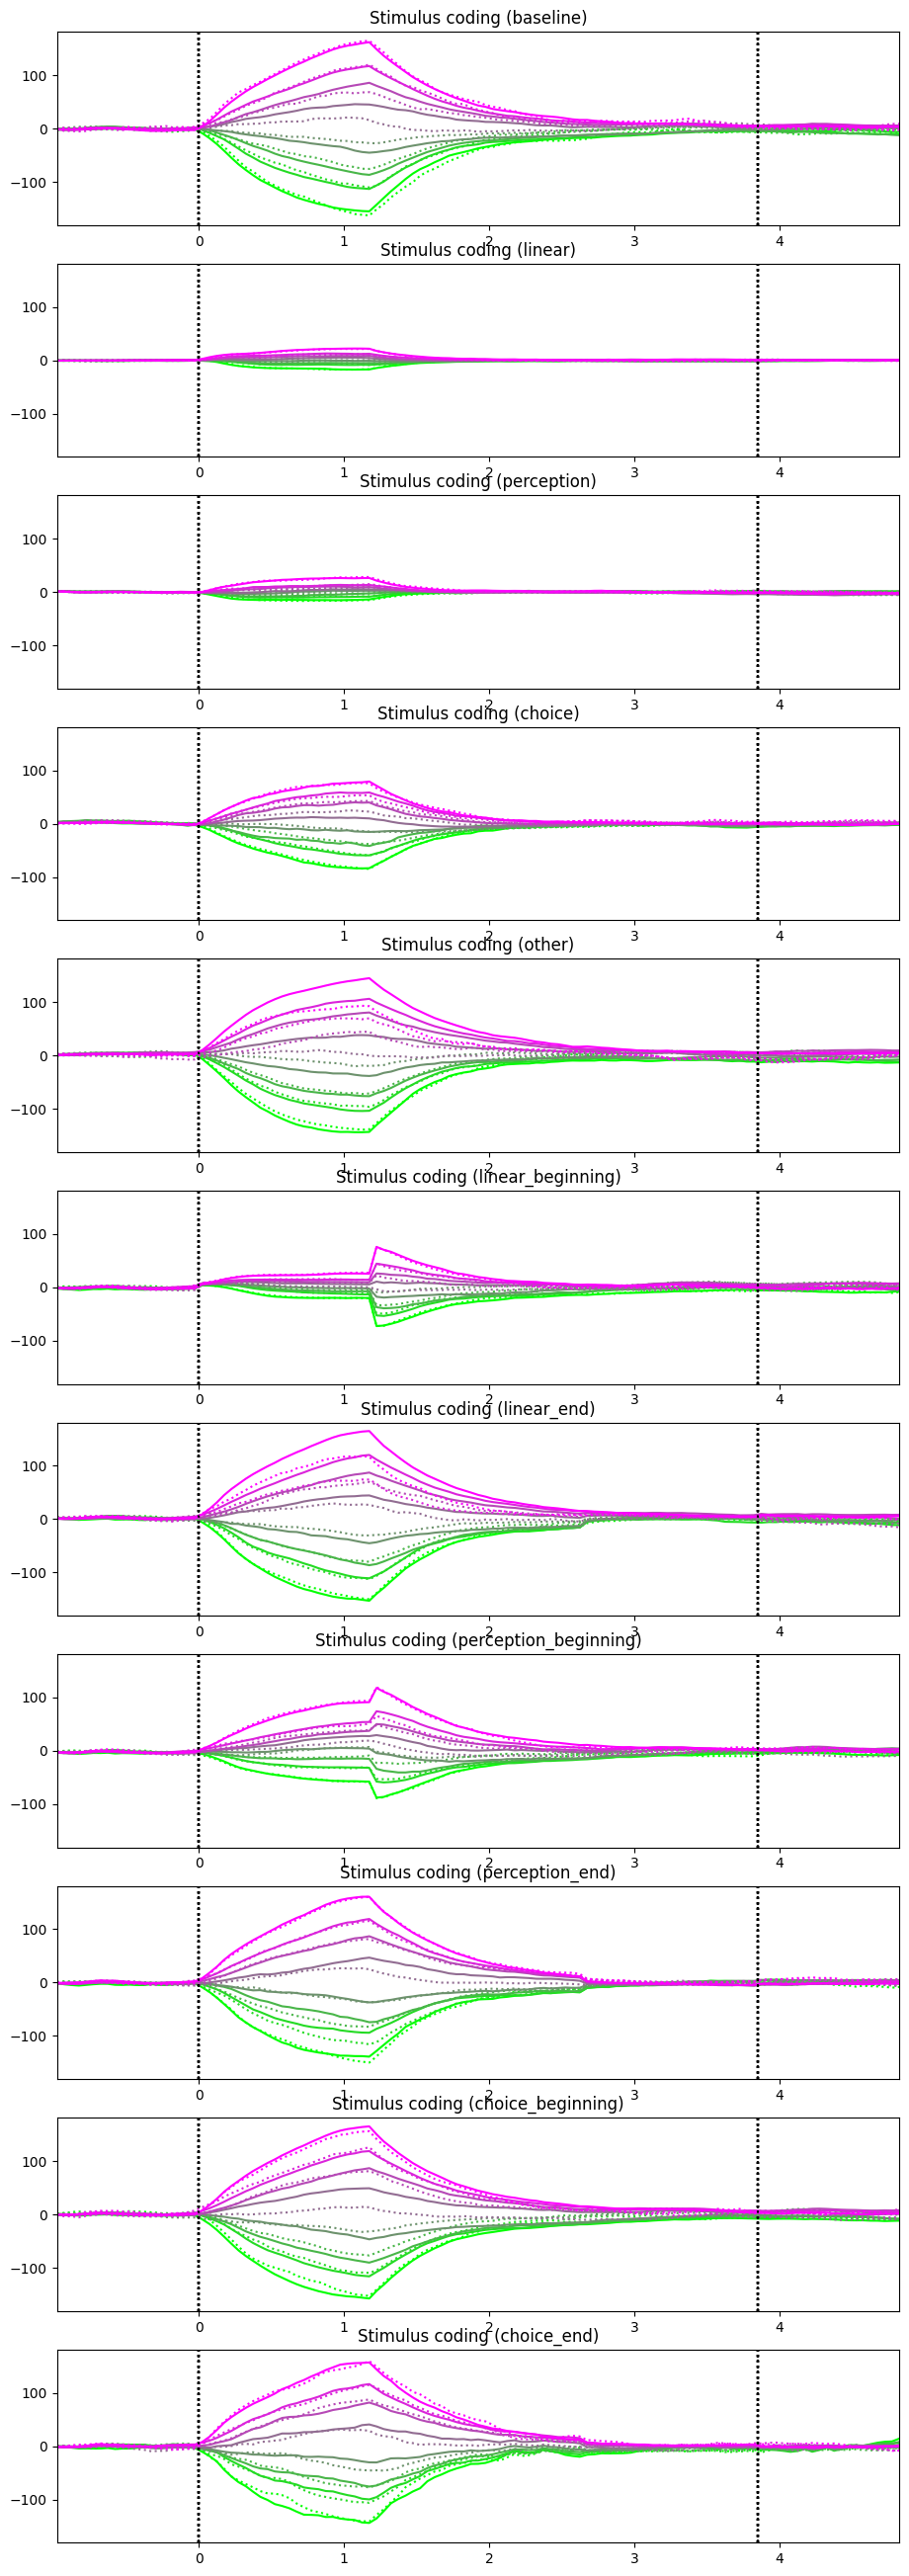

In [97]:
fig, axes = plt.subplots(len(conditions), 1, figsize=(11, 3 * len(conditions)));
y_limits = []
mean_stim_projections_beg_vs_end = {}
for i_condition, condition in enumerate(conditions):
    temp = []
    for i_stim, stim in enumerate(unique_stims):
        for i_choice, choice in enumerate([0, 1]):
            style = '-' if (((stim < 50) and (choice == 0)) or ((stim > 50) and (choice == 1))) else ':'
            v = dPCA_results['baseline']['dpca'].D['st'][:, 0]
            X_tensor = dPCA_results[condition]['X_pseudo_psth']
            X_tilde = X_tensor.reshape([X_tensor.shape[0], -1])
            X_tilde -= X_tilde.mean(axis=1).reshape([-1, 1])
            X_tensor = X_tilde.reshape(X_tensor.shape)
            X = X_tensor[:, i_stim, i_choice, :]   
            y = [(v * X[:, k]).sum() for k in range(len(t))]
            temp.append(np.mean(np.abs(y)))
            axes[i_condition].plot(t, y, color=colors[i_stim, :], linestyle=style);
            axes[i_condition].axvline(0, color='k', linestyle=':');
            axes[i_condition].axvline(t_D, color='k', linestyle=':');
            axes[i_condition].set_title('Stimulus coding ({})'.format(condition));
    y_limits.append(axes[i_condition].get_ylim())
    mean_stim_projections_beg_vs_end[condition] = temp
global_limit = np.max([np.max(np.abs(lims)) for lims in y_limits])
for ax in axes:
    ax.set_xlim([t[0], t[-1]]);
    ax.set_ylim([-global_limit, global_limit]);
    
# Figure 7 - Supplement 2 A
# plt.savefig('plots/review/model/dPCA_beg_vs_end_stimulus_coding.pdf');

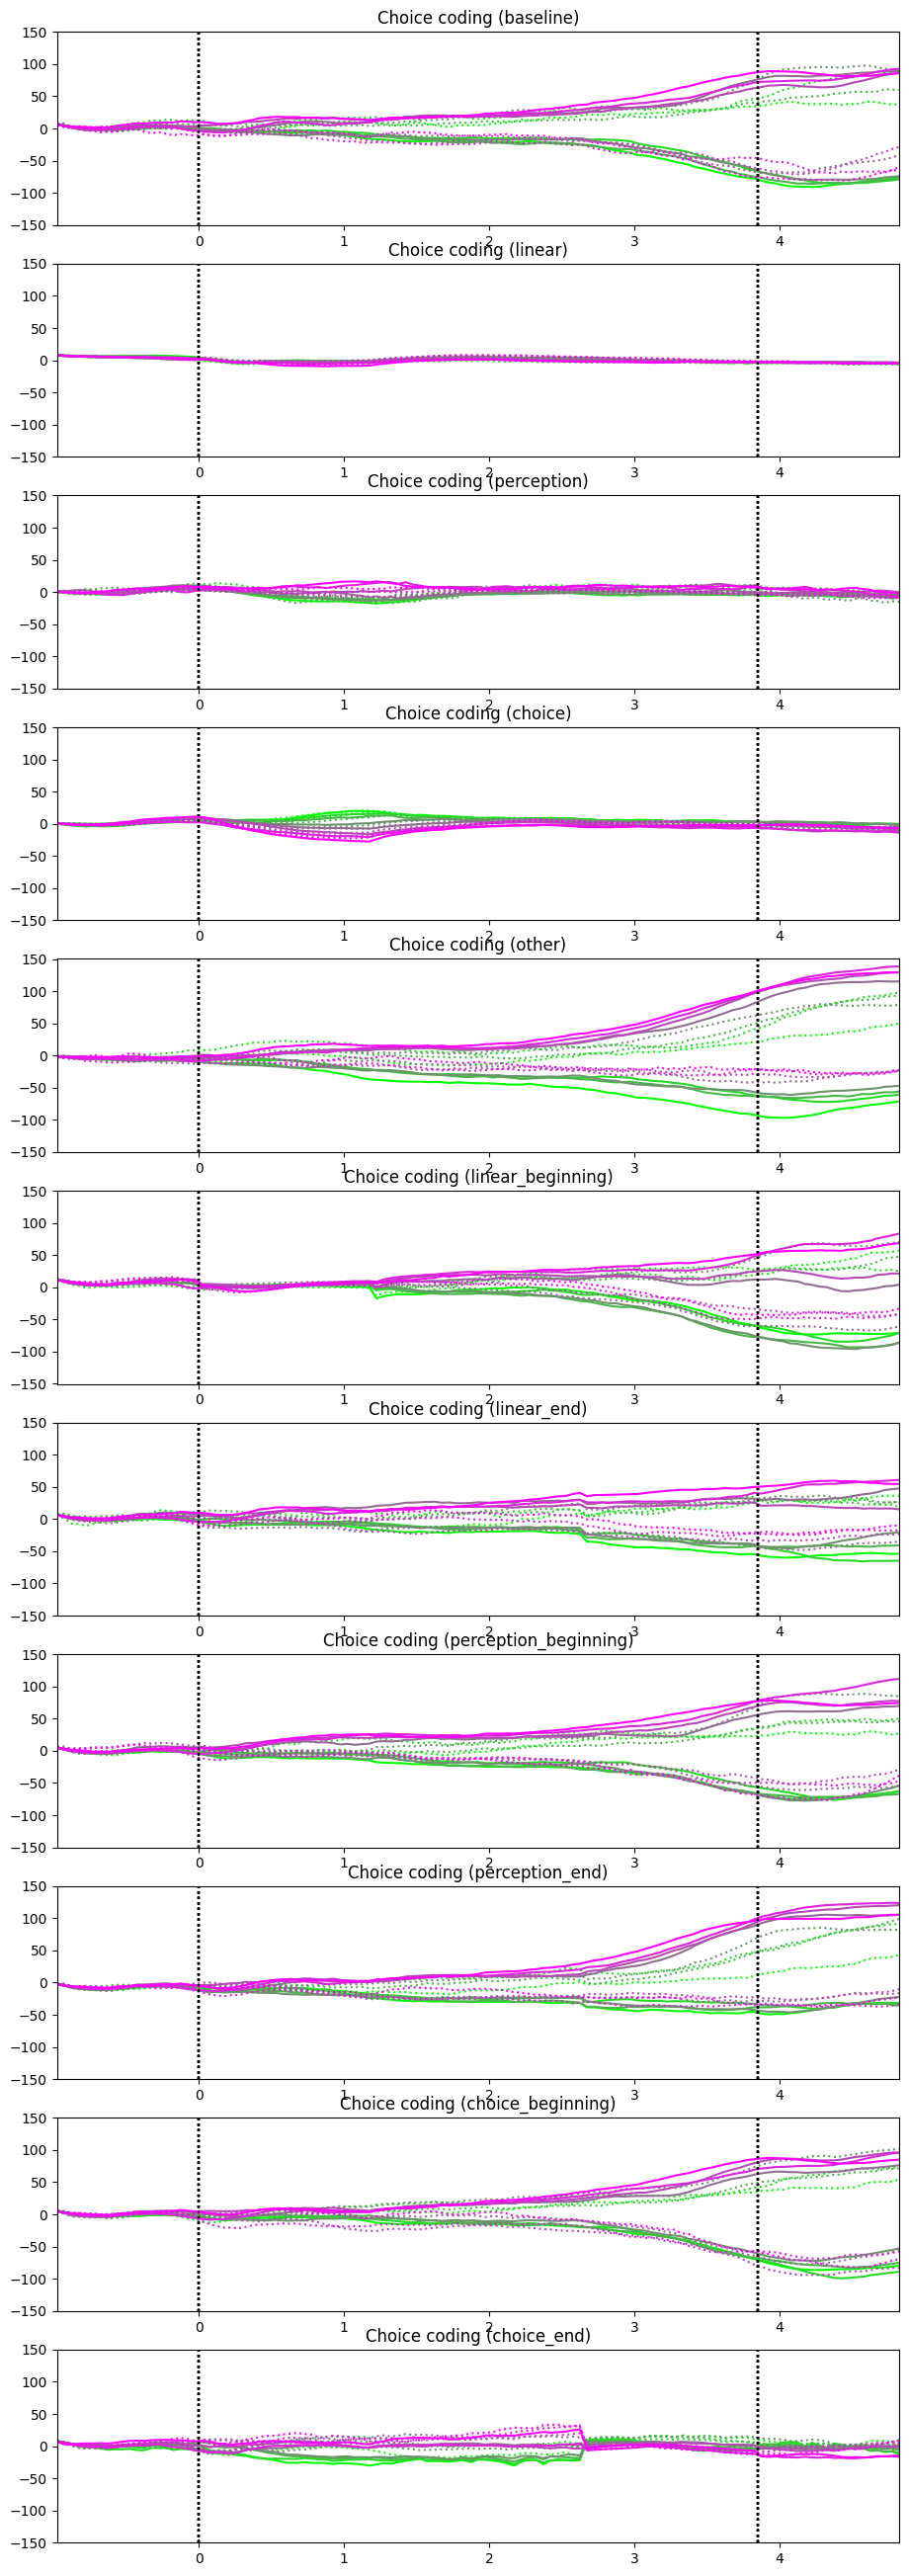

In [98]:
fig, axes = plt.subplots(len(conditions), 1, figsize=(11, 3 * len(conditions)));
y_limits = []
mean_choice_projections_beg_vs_end = {}
for i_condition, condition in enumerate(conditions):
    temp = []
    for i_stim, stim in enumerate(unique_stims):
        for i_choice, choice in enumerate([0, 1]):
            style = '-' if (((stim < 50) and (choice == 0)) or ((stim > 50) and (choice == 1))) else ':'
            v = dPCA_results['baseline']['dpca'].D['dt'][:, 0]
            X_tensor = dPCA_results[condition]['X_pseudo_psth']
            X_tilde = X_tensor.reshape([X_tensor.shape[0], -1])
            X_tilde -= X_tilde.mean(axis=1).reshape([-1, 1])
            X_tensor = X_tilde.reshape(X_tensor.shape)
            X = X_tensor[:, i_stim, i_choice, :]   
            y = [(v * X[:, k]).sum() for k in range(len(t))]
            temp.append(np.mean(np.abs(y)))
            axes[i_condition].plot(t, y, color=colors[i_stim, :], linestyle=style);
            axes[i_condition].axvline(0, color='k', linestyle=':');
            axes[i_condition].axvline(t_D, color='k', linestyle=':');
            axes[i_condition].set_title('Choice coding ({})'.format(condition));
    y_limits.append(axes[i_condition].get_ylim())
    mean_choice_projections_beg_vs_end[condition] = temp
global_limit = np.max([np.max(np.abs(lims)) for lims in y_limits])
for ax in axes:
    ax.set_xlim([t[0], t[-1]]);
    ax.set_ylim([-global_limit, global_limit]);
    
# Figure 7 - Supplement 2 B
# plt.savefig('plots/review/model/dPCA_beg_vs_end_choice_coding.pdf');

In [99]:
'''
2-way within-subjects ANOVA on stimulus component projections
factor 1: coding type (3 levels)
factor 2: beginning vs end (2 levels)

There is only 1 control group b/c factor 2 does not apply when ablating nothing
Remove it as a level of factor 1 to avoid an empty cell in the 2-way ANOVA
To compare groups to control, separately use Dunnett's test on all 6 groups

This is pseudo-population data, so the subjects are no longer individual models
Instead, they are the 16 trial types
'''

n_subjects = 16
coding_type = ['linear', 'perception', 'choice']
window = ['beginning', 'end']
col_subject = list(range(n_subjects)) * (len(coding_type) * len(window))
col_coding_type, col_window, col_measurement = [], [], []

for coding_type_i in coding_type:
    for window_i in window:
        col_coding_type += [coding_type_i] * n_subjects
        col_window += [window_i] * n_subjects
        col_measurement += list(mean_stim_projections_beg_vs_end[coding_type_i + '_' + window_i])

df = pd.DataFrame({
    'id': col_subject,
    'iv1': col_coding_type,
    'iv2': col_window,
    'dv': col_measurement
})

# Perform repeated measures ANOVA
res_anova = rmAnova2Way(df)

# post-hoc tests

all_groups = [
    ('linear', 'beginning'),
    ('linear', 'end'),
    ('perception', 'beginning'),
    ('perception', 'end'),
    ('choice', 'beginning'),
    ('choice', 'end')
]
n_groups = len(all_groups)
correction = scipy.special.comb(n_groups, 2) # bonferroni correction for number of paired tests

p_mat = np.full([n_groups, n_groups], np.nan)
print('\nPost-hoc tests (Bonferroni-adjusted p-values):\n')
for i in range(n_groups - 1):
    for j in range(i + 1, n_groups):
        coding_type_i, window_i = all_groups[i]
        x_i = np.array([_ for _ in df[(df['iv1'] == coding_type_i) & (df['iv2'] == window_i)]['dv']])
        label_i = coding_type_i + '_' + window_i
        coding_type_j, window_j = all_groups[j]
        x_j = np.array([_ for _ in df[(df['iv1'] == coding_type_j) & (df['iv2'] == window_j)]['dv']])
        label_j = coding_type_j + '_' + window_j
        p_adj = correction * scipy.stats.ttest_rel(x_i, x_j)[1]
        print('    {} vs. {}: p = {:.4e}'.format(label_i, label_j, p_adj))
        p_mat[i, j] = (p_adj < 0.01).astype(float)
        
print('')
print(p_mat)

SSE_1b = 999.2497, SSE_1w = 359.5127, F_1 = 41.6918, p_1 = 0.0000
SSE_2b = 1098.4438, SSE_2w = 226.8312, F_2 = 72.6384, p_2 = 0.0000
SSE_12b = 985.4844, SSE_12w = 284.5479, F_12 = 51.9500, p_12 = 0.0000

Post-hoc tests (Bonferroni-adjusted p-values):

    linear_beginning vs. linear_end: p = 1.0786e-05
    linear_beginning vs. perception_beginning: p = 2.2178e-03
    linear_beginning vs. perception_end: p = 1.2210e-05
    linear_beginning vs. choice_beginning: p = 6.6633e-06
    linear_beginning vs. choice_end: p = 1.6098e-05
    linear_end vs. perception_beginning: p = 4.4680e-05
    linear_end vs. perception_end: p = 8.9784e+00
    linear_end vs. choice_beginning: p = 4.5003e-01
    linear_end vs. choice_end: p = 1.3314e+01
    perception_beginning vs. perception_end: p = 7.6644e-06
    perception_beginning vs. choice_beginning: p = 3.4605e-06
    perception_beginning vs. choice_end: p = 9.7220e-06
    perception_end vs. choice_beginning: p = 4.7487e-01
    perception_end vs. choice_

In [100]:
## dunnett test

data = [
    (mean_stim_projections_beg_vs_end[key], key)
    for key in [
        'linear_beginning', 'linear_end', 'perception_beginning', 'perception_end', 'choice_beginning', 'choice_end'
    ]
]
samples = [np.array(data_[0]) for data_ in data]
labels = [data_[1] for data_ in data]
control = np.array(mean_stim_projections_beg_vs_end['baseline'])
res = scipy.stats.dunnett(*samples, control=control)
print('Dunnett test:\n')
for i in range(len(data)):
    print('Control vs {}: p = {:.4e}'.format(labels[i], res.pvalue[i]))

Dunnett test:

Control vs linear_beginning: p = 5.2869e-05
Control vs linear_end: p = 9.8972e-01
Control vs perception_beginning: p = 1.5858e-02
Control vs perception_end: p = 9.9870e-01
Control vs choice_beginning: p = 1.0000e+00
Control vs choice_end: p = 9.9373e-01


In [101]:
'''
2-way within-subjects ANOVA on choice component projections
factor 1: coding type (3 levels)
factor 2: beginning vs end (2 levels)

There is only 1 control group b/c factor 2 does not apply when ablating nothing
Remove it as a level of factor 1 to avoid an empty cell in the 2-way ANOVA
To compare groups to control, separately use Dunnett's test on all 6 groups

This is pseudo-population data, so the subjects are no longer individual models
Instead, they are the 16 trial types
'''

n_subjects = 16
coding_type = ['linear', 'perception', 'choice']
window = ['beginning', 'end']
col_subject = list(range(n_subjects)) * (len(coding_type) * len(window))
col_coding_type, col_window, col_measurement = [], [], []

for coding_type_i in coding_type:
    for window_i in window:
        col_coding_type += [coding_type_i] * n_subjects
        col_window += [window_i] * n_subjects
        col_measurement += list(mean_choice_projections_beg_vs_end[coding_type_i + '_' + window_i])

df = pd.DataFrame({
    'id': col_subject,
    'iv1': col_coding_type,
    'iv2': col_window,
    'dv': col_measurement
})

# Perform repeated measures ANOVA
res_anova = rmAnova2Way(df)

# post-hoc tests

all_groups = [
    ('linear', 'beginning'),
    ('linear', 'end'),
    ('perception', 'beginning'),
    ('perception', 'end'),
    ('choice', 'beginning'),
    ('choice', 'end')
]
n_groups = len(all_groups)
correction = scipy.special.comb(n_groups, 2) # bonferroni correction for number of paired tests

p_mat = np.full([n_groups, n_groups], np.nan)
print('\nPost-hoc tests (Bonferroni-adjusted p-values):\n')
for i in range(n_groups - 1):
    for j in range(i + 1, n_groups):
        coding_type_i, window_i = all_groups[i]
        x_i = np.array([_ for _ in df[(df['iv1'] == coding_type_i) & (df['iv2'] == window_i)]['dv']])
        label_i = coding_type_i + '_' + window_i
        coding_type_j, window_j = all_groups[j]
        x_j = np.array([_ for _ in df[(df['iv1'] == coding_type_j) & (df['iv2'] == window_j)]['dv']])
        label_j = coding_type_j + '_' + window_j
        p_adj = correction * scipy.stats.ttest_rel(x_i, x_j)[1]
        print('    {} vs. {}: p = {:.4e}'.format(label_i, label_j, p_adj))
        p_mat[i, j] = (p_adj < 0.01).astype(float)
        
print('')
print(p_mat)

SSE_1b = 1024.7607, SSE_1w = 830.6741, F_1 = 18.5047, p_1 = 0.0000
SSE_2b = 1045.2750, SSE_2w = 190.8498, F_2 = 82.1543, p_2 = 0.0000
SSE_12b = 1656.0045, SSE_12w = 470.6857, F_12 = 52.7742, p_12 = 0.0000

Post-hoc tests (Bonferroni-adjusted p-values):

    linear_beginning vs. linear_end: p = 5.0343e+00
    linear_beginning vs. perception_beginning: p = 8.0129e-02
    linear_beginning vs. perception_end: p = 3.5396e-01
    linear_beginning vs. choice_beginning: p = 2.6598e-02
    linear_beginning vs. choice_end: p = 3.8202e-06
    linear_end vs. perception_beginning: p = 4.2936e-03
    linear_end vs. perception_end: p = 5.5628e-03
    linear_end vs. choice_beginning: p = 5.4048e-04
    linear_end vs. choice_end: p = 6.8938e-05
    perception_beginning vs. perception_end: p = 1.4649e+01
    perception_beginning vs. choice_beginning: p = 3.9499e+00
    perception_beginning vs. choice_end: p = 1.4098e-06
    perception_end vs. choice_beginning: p = 4.6414e+00
    perception_end vs. choic

In [102]:
## dunnett test

data = [
    (mean_choice_projections_beg_vs_end[key], key)
    for key in [
        'linear_beginning', 'linear_end', 'perception_beginning', 'perception_end', 'choice_beginning', 'choice_end'
    ]
]
samples = [np.array(data_[0]) for data_ in data]
labels = [data_[1] for data_ in data]
control = np.array(mean_choice_projections_beg_vs_end['baseline'])
res = scipy.stats.dunnett(*samples, control=control)
print('Dunnett test:\n')
for i in range(len(data)):
    print('Control vs {}: p = {:.4e}'.format(labels[i], res.pvalue[i]))

Dunnett test:

Control vs linear_beginning: p = 5.3149e-04
Control vs linear_end: p = 3.0575e-05
Control vs perception_beginning: p = 5.0834e-01
Control vs perception_end: p = 5.1848e-01
Control vs choice_beginning: p = 9.6941e-01
Control vs choice_end: p = 0.0000e+00


### Additional examples of RNN units and target experimental PSTHs

In [103]:
smooth_type = 'gaussian'
smooth_width = 11
window_width = 4
window_step = 4

fit_options = [
    {
        'shape' : 'linear',
        'y_min' : 0,
        'y_max' : np.inf,
        'min_y_range' : 0
    },
    {
        'shape' : 'step',
        'midpoints' : [40, 50, 60],
        'min_y_range' : 0
    }
]

n_windows = 1 + (len(t) - window_width) // window_step
inds_L = [i * window_step for i in range(n_windows)]
inds_R = [ind + window_width for ind in inds_L]
t_downsample = [np.mean(t[ind_L:ind_R]) for ind_L, ind_R in zip(inds_L, inds_R)]
exp_labels_over_time = []
for ind_L, ind_R in zip(inds_L, inds_R):   
    labels = []  
    for sess in included_sessions:
        X, y_conc, y_choice, y_outcome, t = all_data[sess]
        # smooth individual trials
        X_smooth = X.copy()
        for i in range(X_smooth.shape[0]):
            for j in range(X_smooth.shape[1]):
                X_smooth[i, j, :] = smooth(X_smooth[i, j, :], smooth_type, smooth_width)
        for i_neuron in range(X_smooth.shape[1]):
            # form response profiles
            response_profile_correct = np.full(len(unique_stims), np.nan)
            response_profile_error = np.full(len(unique_stims), np.nan)
            for i_stim, stim in enumerate(unique_stims):
                trial_mask_correct = (y_conc == stim) & (y_outcome == 1)
                if trial_mask_correct.sum() > 0:
                    r = X_smooth[trial_mask_correct, i_neuron, :].mean(axis=0)[ind_L:ind_R].mean()
                    response_profile_correct[i_stim] = r
                trial_mask_error = (y_conc == stim) & (y_outcome == 0)
                if trial_mask_error.sum() > 0:
                    r = X_smooth[trial_mask_error, i_neuron, :].mean(axis=0)[ind_L:ind_R].mean()
                    response_profile_error[i_stim] = r
            # fit shape templates
            fits = fit_shape_templates(unique_stims, response_profile_correct, fit_options)
            # classify
            classification = classify_fits(fits)
            # parse label
            label = parse_label(classification, response_profile_correct, response_profile_error)
            labels.append(label)
    exp_labels_over_time.append(labels)

In [104]:
exp_data = {}
pseudo_idx_neuron = -1
for sess in included_sessions:
    exp_data[sess] = {}
    X, y_conc, _, y_outcome, _ = all_data[sess]
    # smooth individual trials
    X_smooth = X.copy()
    for i in range(X_smooth.shape[0]):
        for j in range(X_smooth.shape[1]):
            X_smooth[i, j, :] = smooth(X_smooth[i, j, :], smooth_type, smooth_width)
    for i_neuron in range(X_smooth.shape[1]):
        pseudo_idx_neuron += 1
        psth_correct = np.full([len(unique_stims), len(t)], np.nan)
        psth_error = np.full([len(unique_stims), len(t)], np.nan)
        for i_stim, stim in enumerate(unique_stims):
            trial_mask_correct = (y_conc == stim) & (y_outcome == 1)
            if trial_mask_correct.sum() > 0:
                psth_correct[i_stim, :] = X_smooth[trial_mask_correct, i_neuron, :].mean(axis=0)
            trial_mask_error = (y_conc == stim) & (y_outcome == 0)
            if trial_mask_error.sum() > 0:
                psth_error[i_stim, :] = X_smooth[trial_mask_error, i_neuron, :].mean(axis=0)
        label_seq = [exp_labels_over_time[i_t][pseudo_idx_neuron] for i_t in range(len(t_downsample))]
        is_linear = 'Linear' in label_seq
        t_linear = None
        if is_linear:
            inds = [int(_) for _ in np.where([label == 'Linear' for label in label_seq])[0]]
            t_linear = [t_downsample[ind] for ind in inds]
        is_perception = 'Step (Perception)' in label_seq
        t_perception = None
        if is_perception:
            inds = [int(_) for _ in np.where(['Step' in label for label in label_seq])[0]]
            t_perception = [t_downsample[ind] for ind in inds]
        is_choice = 'Step (Choice)' in label_seq
        t_choice = None
        if is_choice:
            inds = [int(_) for _ in np.where(['Step' in label for label in label_seq])[0]]
            t_choice = [t_downsample[ind] for ind in inds]
        is_other = (not is_linear) and (not is_perception) and (not is_choice)
        exp_data[sess][i_neuron] = {
            'psth_correct': psth_correct.copy(),
            'psth_error': psth_error.copy(),
            'is_linear': is_linear,
            'is_perception': is_perception,
            'is_choice': is_choice,
            'is_other': is_other,
            't_linear': t_linear.copy() if t_linear is not None else None,
            't_perception': t_perception.copy() if t_perception is not None else None,
            't_choice': t_choice.copy() if t_choice is not None else None
        }

In [105]:
mdl_data = {}
for i_model, sess in enumerate(included_sessions):
    mdl_data[sess] = {}
    net = all_models[sess]
    net_no_noise = net.clone()
    net_no_noise.noise_std = 0
    output = net_no_noise(inputs).detach().numpy()
    n_total = len(output_noise['all_labels'][i_model][0])
    n_con = int(round(n_total / 5.88))
    if int(round(5.88 * n_con)) != n_total: raise ValueError('backwards rounding failed')
    for i_neuron in range(n_con):
        label_seq = [
            output_noise['all_labels'][i_model][i_t][i_neuron] 
            for i_t in range(len(t_downsample))
        ]
        is_linear = 'Linear' in label_seq
        t_linear = None
        if is_linear:
            inds = [int(_) for _ in np.where([label == 'Linear' for label in label_seq])[0]]
            t_linear = [t_downsample[ind] for ind in inds]
        is_perception = 'Step (Perception)' in label_seq
        t_perception = None
        if is_perception:
            inds = [int(_) for _ in np.where(['Step' in label for label in label_seq])[0]]
            t_perception = [t_downsample[ind] for ind in inds]
        is_choice = 'Step (Choice)' in label_seq
        t_choice = None
        if is_choice:
            inds = [int(_) for _ in np.where(['Step' in label for label in label_seq])[0]]
            t_choice = [t_downsample[ind] for ind in inds]
        is_other = (not is_linear) and (not is_perception) and (not is_choice)
        psth_correct = output_noise['all_psths_correct'][i_model][i_neuron]
        psth_error = output_noise['all_psths_error'][i_model][i_neuron]
        psth_noiseless = output[:, :, i_neuron]
        mdl_data[sess][i_neuron] = {
            'psth_correct': psth_correct.copy(),
            'psth_error': psth_error.copy(),
            'psth_noiseless': psth_noiseless.copy(),
            'is_linear': is_linear,
            'is_perception': is_perception,
            'is_choice': is_choice,
            'is_other': is_other,
            't_linear': t_linear.copy() if t_linear is not None else None,
            't_perception': t_perception.copy() if t_perception is not None else None,
            't_choice': t_choice.copy() if t_choice is not None else None
        }

In [106]:
candidate_linear, candidate_perception, candidate_choice = [], [], []
for sess in exp_data:
    for i_neuron in exp_data[sess]:
        if exp_data[sess][i_neuron]['is_linear'] and mdl_data[sess][i_neuron]['is_linear']:
            candidate_linear.append((sess, i_neuron))
        if exp_data[sess][i_neuron]['is_perception'] and mdl_data[sess][i_neuron]['is_perception']:
            candidate_perception.append((sess, i_neuron))
        if exp_data[sess][i_neuron]['is_choice'] and mdl_data[sess][i_neuron]['is_choice']:
            candidate_choice.append((sess, i_neuron))
print('{} candidate linear units'.format(len(candidate_linear)))
print('{} candidate perception units'.format(len(candidate_perception)))
print('{} candidate choice units'.format(len(candidate_choice)))

86 candidate linear units
49 candidate perception units
34 candidate choice units


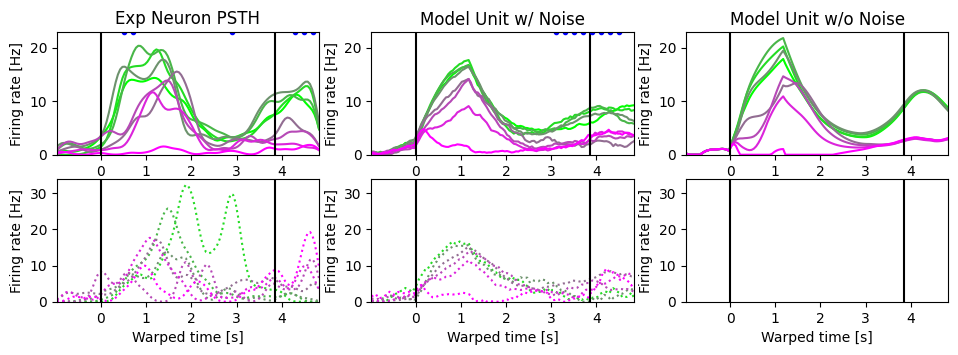

In [107]:
## example constrained neuron 

# (i_session, i_neuron) = candidate_linear[1], 'linear'
# (i_session, i_neuron), sub = candidate_perception[6], 'perception'
(i_session, i_neuron), sub = candidate_choice[5], 'choice'

fig, axes = plt.subplots(2, 3, figsize=(11.5, 3.5));
for i_stim, stim in enumerate(unique_stims):
    y = exp_data[i_session][i_neuron]['psth_correct'][i_stim, :]
    axes[0, 0].plot(t, y, color=colors[i_stim, :]);
    y = exp_data[i_session][i_neuron]['psth_error'][i_stim, :]
    axes[1, 0].plot(t, y, ':', color=colors[i_stim, :]);
    y = mdl_data[i_session][i_neuron]['psth_correct'][i_stim, :]
    axes[0, 1].plot(t, y, color=colors[i_stim, :]);
    y = mdl_data[i_session][i_neuron]['psth_error'][i_stim, :]
    axes[1, 1].plot(t, y, ':', color=colors[i_stim, :]);
    y = mdl_data[i_session][i_neuron]['psth_noiseless'][i_stim, :]
    axes[0, 2].plot(t, y, color=colors[i_stim, :]);
for i_row, ax_row in enumerate(axes):
    for i_col, ax in enumerate(ax_row):
        ax.set_xlim([t[0], t[-1]]);
        ax.set_xlabel('Warped time [s]');
        y_max = max([ax_.get_ylim()[1] for ax_ in ax_row])
        ax.set_ylim([0, y_max]);
        ax.set_ylabel('Firing rate [Hz]');
        ax.axvline(0, color='k');
        ax.axvline(t_D, color='k'); 
        if (i_row == 0) and (i_col == 0):
            ax.title.set_text('Exp Neuron PSTH');
        elif (i_row == 0) and (i_col == 1):
            ax.title.set_text('Model Unit w/ Noise');
        elif (i_row == 0) and (i_col == 2):
            ax.title.set_text('Model Unit w/o Noise');
for point in exp_data[i_session][i_neuron]['t_{}'.format(sub)]:
    axes[0, 0].plot(point, axes[0, 0].get_ylim()[1], '.b');
for point in mdl_data[i_session][i_neuron]['t_{}'.format(sub)]:
    axes[0, 1].plot(point, axes[0, 1].get_ylim()[1], '.b');

# Figure 5 - Supplement 1 A
# plt.savefig('plots/review/model/ex_unit_{}.pdf'.format(sub))

C:\Users\Liam\AppData\Local\Temp\ipykernel_14236\1078851937.py:31: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(1, 2, figsize=(11.5, X_smooth.shape[1] / 626 * 6));


Range of max firing rates: 10.930645400053809 - 92.07536772556419


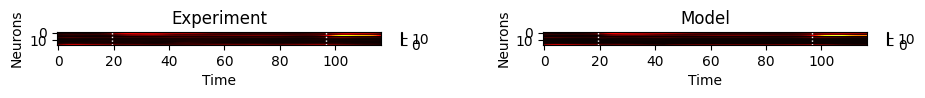

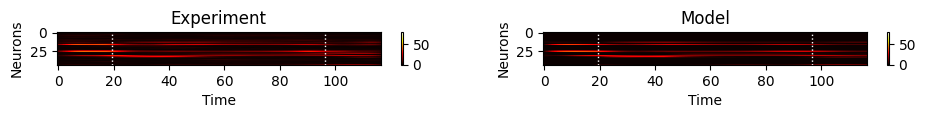

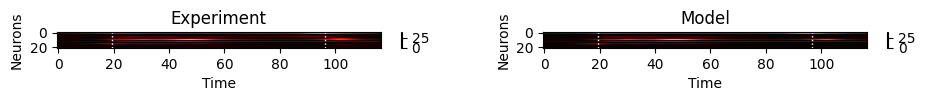

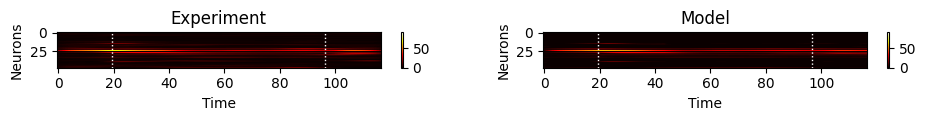

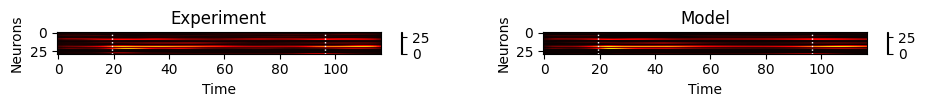

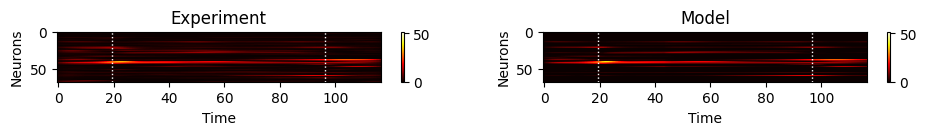

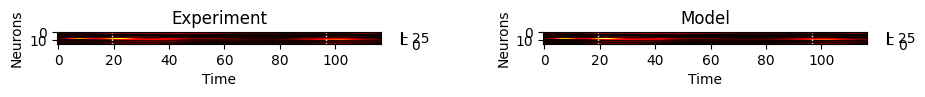

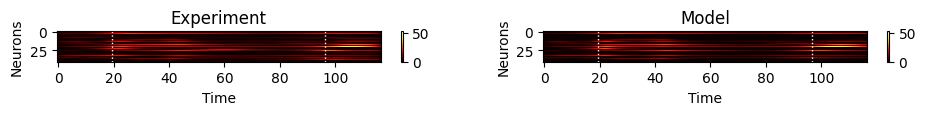

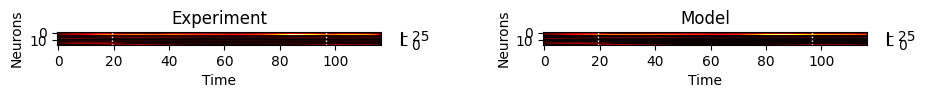

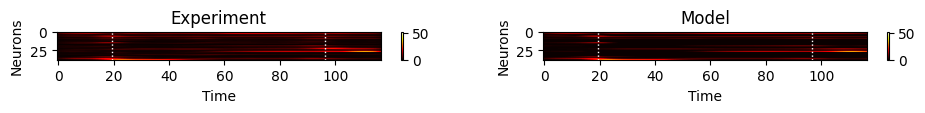

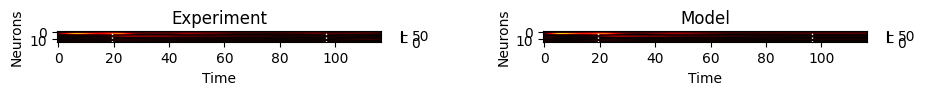

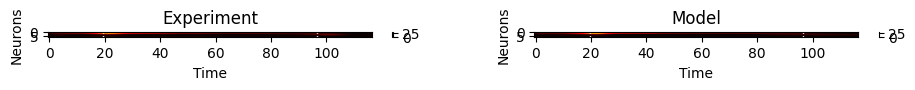

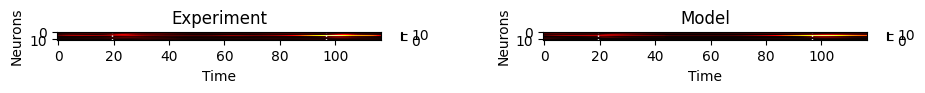

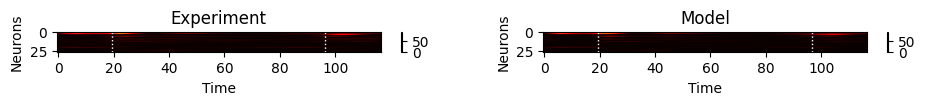

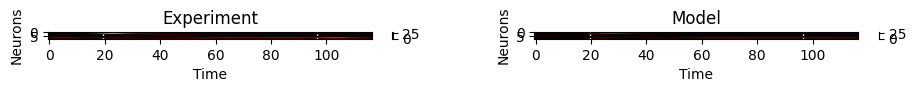

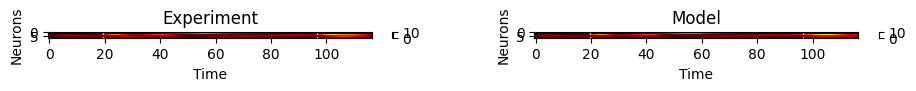

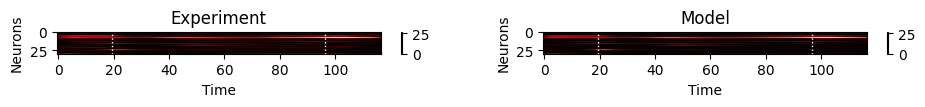

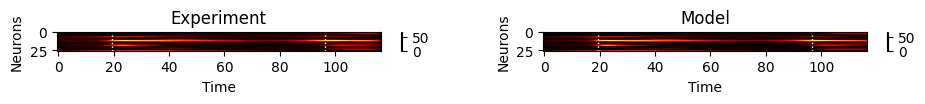

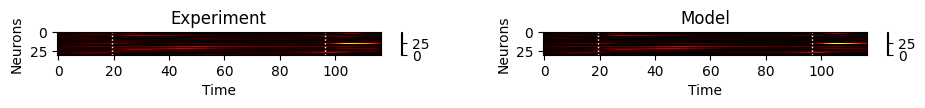

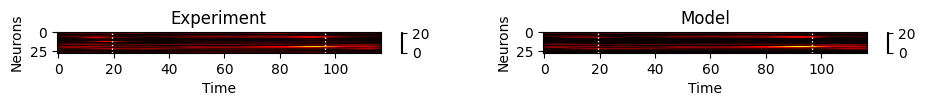

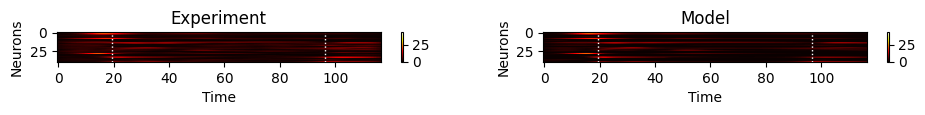

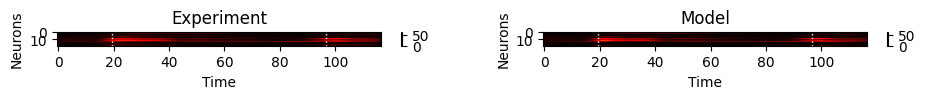

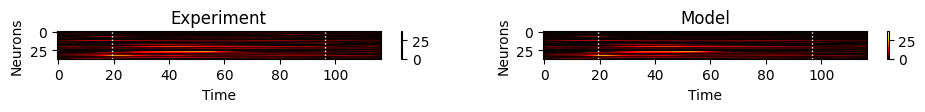

In [108]:
frs = []

for sess in included_sessions:

    ## get experimental data 
    X, y_conc, _, y_outcome, _ = all_data[sess]
    heatmap_exp = np.full((X.shape[1], X.shape[2]), np.nan)
    X_smooth = X.copy() # smooth individual trials
    for i in range(X_smooth.shape[0]):
        for j in range(X_smooth.shape[1]):
            X_smooth[i, j, :] = smooth(X_smooth[i, j, :], smooth_type, smooth_width)
    for i_neuron in range(X_smooth.shape[1]):
        psth = np.full([len(unique_stims), len(t)], np.nan)
        for i_stim, stim in enumerate(unique_stims):
            trial_mask = (y_conc == stim) & (y_outcome == 1)
            if trial_mask.sum() > 0:
                psth[i_stim, :] = X_smooth[trial_mask, i_neuron, :].mean(axis=0).copy()
        heatmap_exp[i_neuron, :] = np.nanmean(psth, axis=0).copy()
    
    ## get model data
    net = all_models[sess]
    net_no_noise = net.clone()
    net_no_noise.noise_std = 0
    output = net_no_noise(inputs).detach().numpy()[:, :, :net_no_noise.observed_size]
    heatmap_mdl = np.swapaxes(output, 1, 2).mean(axis=0)
    
    global_min = 0 # np.min([np.min(heatmap_exp.flatten()), np.min(heatmap_mdl.flatten())])
    global_max = np.max([np.max(heatmap_exp.flatten()), np.max(heatmap_mdl.flatten())])
    shared_norm = matplotlib.colors.Normalize(vmin=global_min, vmax=global_max)
    
    fig, axes = plt.subplots(1, 2, figsize=(11.5, X_smooth.shape[1] / 626 * 6));

    im = axes[0].imshow(heatmap_exp, norm=shared_norm, cmap='hot', aspect='auto');
    axes[0].set_title('Experiment');
    plt.colorbar(im, ax=axes[0]);
        
    im = axes[1].imshow(heatmap_mdl, norm=shared_norm, cmap='hot', aspect='auto');
    axes[1].set_title('Model');
    plt.colorbar(im, ax=axes[1]);
    
    for ax in axes:
        ax.axvline(19.5, color='w', linestyle=':', linewidth=1);
        ax.axvline(len(t) - 20.5, color='w', linestyle=':', linewidth=1);
        ax.set_xlabel('Time');
        ax.set_ylabel('Neurons');
        
    frs.append(global_max)
    
    # Figure 5 - Supplement 1 B
    # plt.savefig('plots/review/model/all_session_fr_session_{}.pdf'.format(sess));    
    
print('Range of max firing rates: {} - {}'.format(np.min(frs), np.max(frs)))